[INFO] 학습 문장 수: 6,641, 라벨 수: 6


c:\Users\KDT-57-\anaconda3\envs\gpu5070_cu128_cv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== 분류 리포트 ===
              precision    recall  f1-score   support

          기쁨       0.86      0.95      0.90       243
          당황       0.71      0.62      0.66       210
          분노       0.68      0.74      0.70       251
          불안       0.66      0.74      0.69       223
          상처       0.61      0.55      0.58       201
          슬픔       0.68      0.58      0.63       201

    accuracy                           0.71      1329
   macro avg       0.70      0.70      0.70      1329
weighted avg       0.70      0.71      0.70      1329



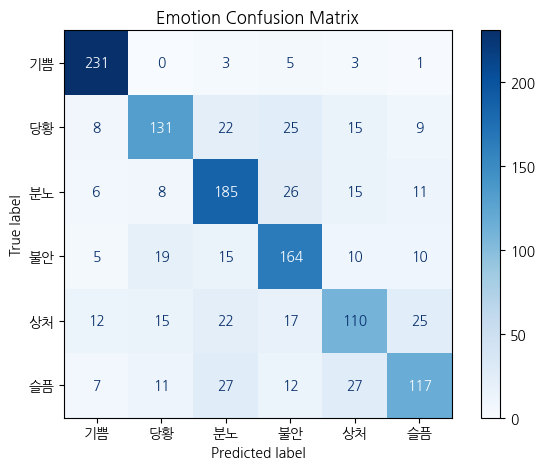

[INFO] 예측 샘플


,timestamp,speaker,text,pred_emotion,pred_conf
0,2025-10-01,[오전 00,27:00] 나: 오늘은 바람이 선선하네요. 출근길이 덜 힘들었어요.,기쁨,0.257585
1,2025-10-01,[오전 09,25:00] 상대: 맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.,기쁨,0.430082
2,2025-10-01,[오전 09,49:00] 나: 요즘 날씨가 딱 산책하기 좋은 것 같아요.,기쁨,0.261804
3,2025-10-01,[오전 10,32:00] 상대: 퇴근 후에 잠깐 걷는 거 진짜 힐링이에요.,기쁨,0.313317
4,2025-10-01,[오전 10,33:00] 나: 그럼 오늘 저녁엔 걸으면서 통화라도 할까요?,기쁨,0.220727
5,2025-10-01,[오후 16,32:00] 상대: 괜찮네요 ㅎ 오늘은 집 일찍 갈게요.,기쁨,0.304000
6,2025-10-02,[오전 10,18:00] 나: 오늘은 커피 대신 차 마셨어요. 카페인이 너무 많아서요.,분노,0.242555
7,2025-10-02,[오전 10,37:00] 상대: 저도 어제 밤에 잠이 안 와서 오늘은 디카페인 마셨어요.,기쁨,0.211759
8,2025-10-02,[오후 15,05:00] 나: 요즘 잠이 잘 안 오는 게 문제예요.,분노,0.241484
9,2025-10-02,[오후 17,32:00] 상대: 그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕,기쁨,0.221618


[INFO] 데이터 없음: 나
[INFO] 데이터 없음: 상대


In [14]:
# =========================================================
# Emotion Baseline: TF-IDF(char 2~5) + LogisticRegression
#   - 학습: ./emotionscore.xlsx (emotion 라벨, 대화 시퀀스 입력)
#   - 적용: ./some.txt (문장별 감정 예측)
#   - 시각화: 분류리포트 + 혼동행렬
# =========================================================
import os, re, sys, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --------------------- 경로 ---------------------
XLSX_PATH = "./emotionscore.xlsx"   # ← 사용자가 지정한 경로
SOME_PATH = "./some.txt"
assert os.path.exists(XLSX_PATH), f"엑셀 없음: {XLSX_PATH}"
assert os.path.exists(SOME_PATH),  f"대화 파일 없음: {SOME_PATH}"

# --------------------- openpyxl 확보 ---------------------
def ensure_openpyxl():
    try:
        import openpyxl  # noqa
        return True
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])
            import openpyxl  # noqa
            return True
        except Exception as e:
            print("[WARN] openpyxl 설치 실패:", e)
            return False

# --------------------- some.txt 로더 ---------------------
DATE_PAT = re.compile(r"^\s*(\d{4})년\s*(\d{2})월\s*(\d{2})일")
LINE_PAT = re.compile(r"(?:\[(\d{1,2}:\d{2})\]\s*)?([^:：]+)\s*[:：]\s*(.*)")

def normalize_text(t:str)->str:
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    return re.sub(r"\s+", " ", t).strip()

def parse_hour(time_str:str)->int:
    if not time_str: return 0
    m = re.search(r"(\d{1,2}):(\d{2})", time_str)
    if not m: return 0
    return max(0, min(23, int(m.group(1))))

def load_dialog_txt(path=SOME_PATH)->pd.DataFrame:
    rows=[]; cur_date=None
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line=line.strip()
            if not line: continue
            dm = DATE_PAT.match(line)
            if dm:
                y,m,d = dm.groups()
                cur_date = f"{y}-{m}-{d}"; continue
            m = LINE_PAT.match(line)
            if not m or not cur_date: continue
            time = (m.group(1) or "")
            spk  = (m.group(2) or "")
            text = normalize_text((m.group(3) or ""))
            hour = parse_hour(time)
            ts   = pd.to_datetime(f"{cur_date} {hour:02d}:00:00")
            rows.append({"turn":i,"timestamp":ts,"date":cur_date,"hour":hour,"speaker":spk,"text":text})
    return pd.DataFrame(rows)

# --------------------- 학습셋 로드 ---------------------
def load_training_from_xlsx(path=XLSX_PATH)->pd.DataFrame:
    ensure_openpyxl()
    df = pd.read_excel(path, sheet_name=0, engine="openpyxl")
    # 필요한 컬럼 체크
    need_cols = ["emotion","person1","system1","person2","system2","person3","system3"]
    missing = [c for c in need_cols if c not in df.columns]
    if missing:
        raise ValueError(f"엑셀에 필요한 컬럼이 없습니다: {missing}\n컬럼 목록: {list(df.columns)}")

    # 대화 시퀀스 결합
    dialog_cols = ["person1","system1","person2","system2","person3","system3"]
    df[dialog_cols] = df[dialog_cols].fillna("")
    df["dialog"] = df[dialog_cols].agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()
    # 라벨
    df["emotion"] = df["emotion"].astype(str).str.strip()
    df = df[df["dialog"].astype(bool) & df["emotion"].astype(bool)].copy()
    return df[["dialog","emotion"]]

train_df = load_training_from_xlsx(XLSX_PATH)
print(f"[INFO] 학습 문장 수: {len(train_df):,}, 라벨 수: {train_df['emotion'].nunique()}")

# --------------------- 벡터라이즈 & 학습 ---------------------
X = train_df["dialog"].values
y = train_df["emotion"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# char n-gram이 대화 감정 분류에 강함(철자변형/어절경계 견고)
vec = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=80000, min_df=1)
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)

clf = LogisticRegression(max_iter=2000, multi_class="multinomial", solver="saga")
clf.fit(Xtr, y_train)

y_pred = clf.predict(Xte)
print("=== 분류 리포트 ===")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
ConfusionMatrixDisplay(cm, display_labels=np.unique(y)).plot(cmap="Blues", values_format="d")
plt.title("Emotion Confusion Matrix")
plt.tight_layout(); plt.show()





# --------------------- some.txt 적용 ---------------------
df_some = load_dialog_txt(SOME_PATH)
X_some = vec.transform(df_some["text"])
proba  = clf.predict_proba(X_some)
pred   = clf.classes_[np.argmax(proba, axis=1)]
conf   = np.max(proba, axis=1)

df_some["pred_emotion"] = pred
df_some["pred_conf"]    = conf

print("[INFO] 예측 샘플")
display(df_some.head(10)[["timestamp","speaker","text","pred_emotion","pred_conf"]])

# --------------------- 간단 시각화(일자/화자 평균 감정 확률) ---------------------
# 감정별 확률 컬럼로 펼치기
proba_df = pd.DataFrame(proba, columns=[f"emo_{c}" for c in clf.classes_])
df_some2 = pd.concat([df_some.reset_index(drop=True), proba_df], axis=1)
df_some2["date_dt"] = pd.to_datetime(df_some2["date"])

daily = (df_some2.groupby(["date_dt","speaker"])[[c for c in proba_df.columns]]
         .mean().reset_index().sort_values("date_dt"))

def plot_daily_emotion_stack(daily_df, speaker):
    sub = daily_df[daily_df["speaker"]==speaker]
    if sub.empty:
        print(f"[INFO] 데이터 없음: {speaker}"); return
    sub = sub.set_index("date_dt").sort_index()
    Y = sub[[c for c in proba_df.columns]]
    labels = [c.replace("emo_","") for c in Y.columns]
    plt.figure(figsize=(12,5))
    plt.stackplot(sub.index, Y.values.T, labels=labels, alpha=0.85)
    plt.title(f"📅 일자별 감정 분포 — {speaker}")
    plt.xlabel("날짜"); plt.ylabel("확률")
    plt.legend(loc="upper left", ncol=3, bbox_to_anchor=(0,1.15))
    plt.xticks(rotation=45); plt.ylim(0,1)
    plt.tight_layout(); plt.show()

plot_daily_emotion_stack(daily, "나")
plot_daily_emotion_stack(daily, "상대")


Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).


[INFO] KOTE 사용 행: 23267
                                              dialog emotion
0               내가 톰행크스를 좋아하긴 했나보다.. 초기 영화 빼고는 다 봤네.      혐오
2  새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...      슬픔
3                 미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㅋ      놀람
[INFO] 결합 학습셋 크기: 29908  / 라벨: 9


c:\Users\KDT-57-\anaconda3\envs\gpu5070_cu128_cv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== [KOTE+엑셀] 분류 리포트 ===
              precision    recall  f1-score   support

          기쁨       0.82      0.44      0.57       476
          놀람       0.27      0.49      0.35      1261
          당황       0.72      0.51      0.60       210
          분노       0.45      0.25      0.32       888
          불안       0.32      0.28      0.30      1132
          상처       0.56      0.51      0.54       201
          슬픔       0.54      0.18      0.27       606
          중립       0.50      0.01      0.02        89
          혐오       0.24      0.31      0.27      1119

    accuracy                           0.34      5982
   macro avg       0.49      0.33      0.36      5982
weighted avg       0.40      0.34      0.34      5982



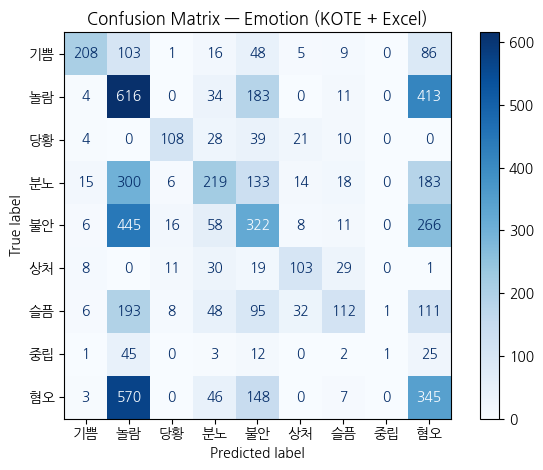

NameError: name 'LEX_PATH' is not defined

In [15]:
# =========================================================
# ✅ KOTE(한국어 감정 데이터) 추가 학습
#   - 기존 emotionscore.xlsx 로 만든 train_df(dialog, emotion)에
#     KOTE의 (text, labels) 를 매핑해서 합침
#   - 최종: TF-IDF(char 2~5) + LogisticRegression 재학습
# =========================================================
import pandas as pd
import numpy as np
import re, sys, subprocess

# 0) datasets 설치(없으면)
try:
    from datasets import load_dataset
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

# ---------------------------------------------------------
# 1) KOTE 로드
#    - split: train/validation/test → 모두 사용해서 학습용으로 묶거나,
#             원하면 validation/test는 검증용으로 분리해도 됨
# ---------------------------------------------------------
kote = load_dataset("searle-j/kote")
# pandas 변환
df_kote_tr = kote["train"].to_pandas()
df_kote_va = kote["validation"].to_pandas()
df_kote_te = kote["test"].to_pandas()
df_kote_all = pd.concat([df_kote_tr, df_kote_va, df_kote_te], ignore_index=True)

# KOTE 컬럼 기본: ['ID','text','labels']
# labels 형은 단일 정수(or 멀티핫 리스트)일 수 있어 처리 분기
def _labels_to_single(lbl):
    # 단일 정수: 그대로 반환
    if isinstance(lbl, (int, np.integer)): 
        return int(lbl)
    # 리스트/벡터: 가장 큰 값(또는 True) 인덱스 사용 (멀티라벨일 때 단일화)
    if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl)>0:
        arr = np.asarray(lbl, dtype=float)
        return int(arr.argmax())
    # 그 외: 결측 처리
    return None

df_kote_all["label_id"] = df_kote_all["labels"].apply(_labels_to_single)

# ---------------------------------------------------------
# 2) KOTE 라벨 → 우리의 감정 이름으로 매핑
#    - KOTE의 실제 라벨 이름은 데이터 버전에 따라 다를 수 있어요.
#    - 아래 매핑은 예시입니다. (필요 시 print(df_kote_all["label_id"].value_counts())로 분포 확인 후 수정)
# ---------------------------------------------------------
# 예시: KOTE의 0~6을 'neutral/joy/sadness/angry/fear/disgust/surprise' 로 가정
KOTE_ID2NAME = {
    0: "중립",     # neutral
    1: "기쁨",     # joy
    2: "슬픔",     # sadness
    3: "분노",     # angry
    4: "불안",     # fear
    5: "혐오",     # disgust
    6: "놀람",     # surprise
}
df_kote_all["emotion_name"] = df_kote_all["label_id"].map(KOTE_ID2NAME)

# ---------------------------------------------------------
# 3) 우리의 라벨 체계로 매핑 (엑셀의 emotion 라벨과 합치기)
#    - emotionscore.xlsx 의 라벨명(예: 기쁨/슬픔/분노/불안/혐오/놀람/중립 등)에 맞게 매핑
#    - 필요시 여기서 통합 라벨명을 바꿔주세요.
# ---------------------------------------------------------
MAP_KOTE_TO_EMO = {
    "중립":"중립",
    "기쁨":"기쁨",
    "슬픔":"슬픔",
    "분노":"분노",
    "불안":"불안",
    "혐오":"혐오",
    "놀람":"놀람",
}
df_kote_all["emotion_mapped"] = df_kote_all["emotion_name"].map(MAP_KOTE_TO_EMO)

# 텍스트 정리
def normalize_text(t:str)->str:
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    return re.sub(r"\s+", " ", t).strip()

df_kote_all["dialog"] = df_kote_all["text"].astype(str).map(normalize_text)

# 매핑 성공 케이스만 사용
kote_train_df = df_kote_all.dropna(subset=["dialog","emotion_mapped"]).copy()
kote_train_df = kote_train_df.rename(columns={"emotion_mapped":"emotion"})[["dialog","emotion"]]

print("[INFO] KOTE 사용 행:", len(kote_train_df))
print(kote_train_df.head(3))

# ---------------------------------------------------------
# 4) (핵심) 기존 emotionscore.xlsx 기반 학습 데이터(train_df)와 결합
#    - 앞서 만든 train_df(dialog, emotion)가 메모리에 있다고 가정
# ---------------------------------------------------------
assert "train_df" in globals(), "먼저 emotionscore.xlsx에서 train_df(dialog, emotion)를 만들어 주세요."
combo_df = pd.concat([train_df[["dialog","emotion"]], kote_train_df], ignore_index=True)
combo_df = combo_df.dropna().query("dialog.str.len()>0 and emotion.str.len()>0")
print("[INFO] 결합 학습셋 크기:", len(combo_df), " / 라벨:", combo_df["emotion"].nunique())

# 라벨 정규화(좌우공백 제거)
combo_df["emotion"] = combo_df["emotion"].astype(str).str.strip()

# ---------------------------------------------------------
# 5) 재학습: TF-IDF(char 2~5) + LogisticRegression
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

X = combo_df["dialog"].values
y = combo_df["emotion"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vec = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

clf = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga")
clf.fit(Xtr, y_train)

y_pred = clf.predict(Xva)
print("=== [KOTE+엑셀] 분류 리포트 ===")
print(classification_report(y_val, y_pred))
cm = confusion_matrix(y_val, y_pred, labels=np.unique(y))
ConfusionMatrixDisplay(cm, display_labels=np.unique(y)).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Emotion (KOTE + Excel)"); plt.tight_layout(); plt.show()

# =========================================================
# 2) SentiWord_Dict 로드 → (pos,neg,obj) 확률 사전
# =========================================================
def load_int_lex(path: str)->Dict[str, float]:
    lex={}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line or line.startswith("#"): 
                continue
            parts=re.split(r"\t+|\s{2,}", line)
            if len(parts)>=2:
                key, val = parts[0].strip(), parts[1].strip()
                try: lex[key] = float(val)
                except: pass
    return lex

def scalar_to_probs(s:float)->Tuple[float,float,float]:
    # s∈[-2,2] → (pos,neg,obj) 합=1
    if s>0: pos,neg,obj = s/2, 0.0, 1 - s/2
    elif s<0: pos,neg,obj = 0.0, abs(s)/2, 1 - abs(s)/2
    else: pos,neg,obj = 0.0, 0.0, 1.0
    Z = pos+neg+obj
    return (pos/Z, neg/Z, obj/Z) if Z>0 else (0.0,0.0,1.0)

LEX_SCALAR = load_int_lex(LEX_PATH)
PROB_LEX = {w: scalar_to_probs(s) for w,s in LEX_SCALAR.items()}

# 대화체 보정(중립화/긍정 이모티콘)
CUSTOM_UPDATES = {
    "해요":0, "합니다":0, "그렇게":0, "그럼":0,
    "ㅋㅋ":1, "ㅎㅎ":1, "좋아요":2, "❤️":2, "💕":2, "🥰":2, "☺️":1
}
for k,v in CUSTOM_UPDATES.items():
    LEX_SCALAR[k] = v
    PROB_LEX[k]   = scalar_to_probs(v)

print(f"[INFO] 감정 사전 단어수: {len(PROB_LEX):,}")

# =========================================================
# 3) 형태소 분석기 (Mecab → Okt fallback)
# =========================================================
try:
    from konlpy.tag import Mecab
    try:
        mecab = Mecab()
    except Exception:
        mecab = Mecab(dicpath=r"C:\mecab\mecab-ko-dic")
    tokenizer = mecab.morphs
    pos_tagger = mecab.pos
    print("[TOKEN] Mecab 사용")
except Exception:
    from konlpy.tag import Okt
    _okt = Okt()
    tokenizer = _okt.morphs
    pos_tagger = _okt.pos
    print("[TOKEN] Okt 사용")

# =========================================================
# 4) 조절어 & n-gram 유틸
# =========================================================
NEGATORS = {
    "안":1.0,"못":1.0,"별로":1.0,"전혀":1.0,"아니":1.0,"않":1.0,"아닌":1.0,"싫":1.0,"별루":1.0,
    "그닥":1.0,"그다지":1.0,"결코":1.0,"절대":1.0,"도저히":1.0,"하나도":1.0,"통":1.0,
    "엉망":1.0,"형편없":1.0,"쓸모없":1.0,"최악":1.0,"끔찍":1.0,"역겹":1.0,"극혐":1.0,
    "실망":1.0,"지루":1.0,"귀찮":1.0,"짜증":1.0,"어이없":1.0,"불만":1.0,"부담":1.0,"걱정":1.0,"후회":1.0,
}
INTENSIFIERS = {
    "정말":0.25,"매우":0.20,"아주":0.20,"완전":0.35,"너무":0.25,"진짜":0.25,"엄청":0.30,"굉장히":0.25,"대단히":0.25,
    "되게":0.20,"무지":0.20,"참":0.15,"심히":0.20,"엄청나게":0.30,"정말로":0.25,"완전히":0.30,
    "대박":0.40,"최고":0.30,"짱":0.25,"역대급":0.40,"끝내줘":0.35,"쩐다":0.35,"최강":0.35,"극강":0.40,
    "좋아":0.35,"좋아요":0.45,"최애":0.30,"설렌다":0.25,"설레":0.20,
}
HEDGES = {
    "조금":0.20,"약간":0.20,"살짝":0.20,"그냥":0.25,"왠지":0.15,"좀":0.15,"그럭저럭":0.25,"대충":0.25,
    "아마":0.15,"아마도":0.15,"그럴지도":0.15,"그런가":0.10,"같은데":0.10,"느낌":0.05,
    "괜찮":0.10,"무난":0.10,"나쁘지":0.10,"보통":0.10,"평범":0.10,"그저그래":0.15,
}

def make_ngrams(tokens:List[str], max_n:int=3)->List[str]:
    out=set(tokens)
    n=len(tokens)
    for L in range(2, max_n+1):
        for i in range(n-L+1):
            seg=tokens[i:i+L]
            out.add(" ".join(seg))
            out.add("".join(seg))
    return list(out)

# =========================================================
# 5) 문맥 보정(이모지/웃음/감탄사)
# =========================================================
POS_EMOJI = r"[❤️💕💖💗💓💘🥰😊☺️😄😆😁✨]"
LAUGH     = r"(ㅋㅋ+|ㅎㅎ+|kkk+|lol+)"
EXCLAIM   = r"(와|우와|헐|대박|굿|좋아요|고마워|감사|멋지다|예쁘다)"

def contextual_boost(text:str, pos_raw:float, neg_raw:float)->Tuple[float,float]:
    boost = 0.0
    if re.search(POS_EMOJI, text): boost += 1.0
    if re.search(LAUGH, text):     boost += 0.6
    if re.search(EXCLAIM, text):   boost += 0.6
    if "🥲" in text or "ㅠ" in text or "ㅜ" in text:
        boost -= 0.4
    pos_raw *= (1.0 + max(0.0, boost))
    neg_raw *= (1.0 - max(0.0, boost) * 0.5)
    return pos_raw, max(0.0, neg_raw)

# =========================================================
# 6) 한 문장 호감도 스코어(Pos/Neg/Obj)
# =========================================================
def score_sentence_valence(text:str, max_ng:int=3)->Dict[str,float]:
    toks = tokenizer(text)
    units = make_ngrams(toks, max_ng)

    pos_raw=neg_raw=obj_raw=0.0
    for u in units:
        if u in PROB_LEX:
            p,n,o = PROB_LEX[u]
            pos_raw += p; neg_raw += n; obj_raw += o

    obj_raw = max(obj_raw, 1.0)  # 최소 중립

    # 조절어 가중치
    amp  = sum(INTENSIFIERS.get(t,0.0) for t in toks)
    damp = sum(HEDGES.get(t,0.0) for t in toks)
    if amp>0:
        pos_raw *= (1.0 + amp); neg_raw *= (1.0 + amp)
    if damp>0:
        scale = max(0.5, 1.0 - damp)
        pos_raw *= scale; neg_raw *= scale

    # 부정어 — polarity swap (완전반전 대신 0.75)
    if any(t in NEGATORS for t in toks):
        pos_raw, neg_raw = neg_raw*0.75, pos_raw*0.75

    # 문맥 보정
    pos_raw, neg_raw = contextual_boost(text, pos_raw, neg_raw)

    Z = pos_raw + neg_raw + obj_raw
    if Z <= 0: 
        return {"pos":0.0,"neg":0.0,"obj":1.0,"val_label":"중립","val_conf":1.0}
    pos,neg,obj = pos_raw/Z, neg_raw/Z, obj_raw/Z
    if pos - neg > 0.1:   label="긍정"
    elif neg - pos > 0.1: label="부정"
    else:                  label="중립"
    return {"pos":pos,"neg":neg,"obj":obj,"val_label":label,"val_conf":max(pos,neg,obj)}


# ---------------------------------------------------------
# 6) some.txt에 재적용 (이전 파이프라인과 동일)
#    - df_some 또는 df (이미 some.txt 로드된 DataFrame) 에 예측 붙이기
# ---------------------------------------------------------
if "df_some" in globals():
    target_df = df_some
elif "df" in globals():
    target_df = df
else:
    from pathlib import Path
    assert Path("./some.txt").exists(), "some.txt가 필요합니다."
    # 기존에 사용하던 load_dialog_txt 함수를 쓰세요.
    target_df = load_dialog_txt("./some.txt")

X_target = vec.transform(target_df["text"])
proba    = clf.predict_proba(X_target)
pred     = clf.classes_[np.argmax(proba, axis=1)]
conf     = np.max(proba, axis=1)

target_df["pred_emotion_kote"] = pred
target_df["pred_conf_kote"]    = conf

print("[INFO] some.txt 적용 샘플")
display(target_df.head(10)[["timestamp","speaker","text","pred_emotion_kote","pred_conf_kote"]])


In [ ]:
# =========================================================
# ALL-IN-ONE: 긍/부/중 학습 + 감정(7클래스) 학습 + 적용/스코어
#  - 학습 데이터(필수): ./emotionscore.xlsx
#  - 외부 데이터(선택): 🤗 Datasets 'searle-j/kote' (자동 설치/로딩)
#  - 입력 적용: 전역 df/df_some 또는 ./some.txt
#  - 출력: pos/neg/neu, valence_pred/conf, emotion_pred/prob, affection(0~100)
# =========================================================

import os, re, sys, json, subprocess, warnings
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd

# ---------------------------------------------
# 0) 옵션/경로
# ---------------------------------------------
EMO_XLSX = "./emotionscore.xlsx"      # 엑셀(필수) — person*/system*와 emotion 포함
USE_KOTE = True                       # KOTE 결합 사용 여부
OUT_DIR  = "./emo_all_out"
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------
# 1) 필요 패키지 준비
# ---------------------------------------------
def ensure(pkgs: List[str]):
    for p in pkgs:
        try:
            __import__(p)
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

ensure(["scikit-learn", "matplotlib"])
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# KOTE 로딩용
if USE_KOTE:
    try:
        from datasets import load_dataset
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
        from datasets import load_dataset

# ---------------------------------------------
# 2) 공통 전처리/정규화
# ---------------------------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

# 감정→Valence 매핑 (7감정 → 긍/부/중)
EMO2VAL = {
    "기쁨":"긍정", "슬픔":"부정", "분노":"부정", "불안":"부정", "혐오":"부정", "놀람":"중립",
    "중립":"중립", "긍정":"긍정", "부정":"부정"
}
EMO_ALLOWED = {"중립","기쁨","슬픔","분노","불안","혐오","놀람"}  # 세부 감정 7클래스

# ---------------------------------------------
# 3) emotionscore.xlsx → (dialog, emotion) & (dialog, valence)
# ---------------------------------------------
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]

EMO_COL  = "emotion"
UTT_COLS = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert EMO_COL in raw.columns and UTT_COLS, f"컬럼 확인 필요: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = str(r[EMO_COL]).strip()
    for uc in UTT_COLS:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": utt, "emotion_raw": emo})
base_df = pd.DataFrame(rows).dropna()
base_df["dialog"] = base_df["dialog"].map(normalize_text)
base_df["emotion_raw"] = base_df["emotion_raw"].astype(str).str.strip()

# (A) 세부 감정 7클래스용 데이터
emo_df = base_df.copy()
emo_df = emo_df[emo_df["emotion_raw"].isin(EMO_ALLOWED)].rename(columns={"emotion_raw":"emotion"})
emo_df = emo_df[["dialog","emotion"]].reset_index(drop=True)

# (B) 긍/부/중 Valence용 데이터 (모든 라벨 매핑 후 사용)
val_df = base_df.copy()
val_df["valence"] = val_df["emotion_raw"].map(EMO2VAL)
val_df = val_df.dropna(subset=["valence"])
val_df = val_df[["dialog","valence"]].reset_index(drop=True)

print(f"[INFO] Excel → emotion(7cls): {len(emo_df)}, valence(3cls): {len(val_df)}")

# ---------------------------------------------
# 4) KOTE 결합(선택, 세부 감정 7클래스에만 추가)
# ---------------------------------------------
if USE_KOTE:
    print("[INFO] KOTE 로딩 중...(처음이면 다운로드)")
    ds = load_dataset("searle-j/kote")
    dtr = ds["train"].to_pandas(); dva = ds["validation"].to_pandas(); dte = ds["test"].to_pandas()
    kote_all = pd.concat([dtr, dva, dte], ignore_index=True)

    def _labels_to_single(lbl):
        if isinstance(lbl, (int, np.integer)): return int(lbl)
        if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl) > 0:
            arr = np.asarray(lbl, dtype=float)
            return int(arr.argmax())
        return None

    kote_all["label_id"] = kote_all["labels"].apply(_labels_to_single)
    # KOTE: 0~6 → neutral/joy/sadness/anger/fear/disgust/surprise
    KOTE_ID2NAME = {0:"중립",1:"기쁨",2:"슬픔",3:"분노",4:"불안",5:"혐오",6:"놀람"}
    kote_all["emotion_name"] = kote_all["label_id"].map(KOTE_ID2NAME)
    kote_all["dialog"] = kote_all["text"].astype(str).map(normalize_text)
    kote_emo = kote_all.dropna(subset=["dialog","emotion_name"])
    kote_emo = kote_emo.rename(columns={"emotion_name":"emotion"})[["dialog","emotion"]]
    print(f"[INFO] KOTE 사용 행: {len(kote_emo)}")

    emo_df = pd.concat([emo_df, kote_emo], ignore_index=True)
    print(f"[INFO] 결합 이후 emotion(7cls) 크기: {len(emo_df)}")

# ---------------------------------------------
# 5) 데이터 분할 & 파이프라인(Valence / Emotion 각각)
#    - 공통: TF-IDF(char 2~5), LogisticRegression(saga, multinomial)
# ---------------------------------------------
from sklearn.utils.class_weight import compute_class_weight

def train_text_clf(df_text: pd.DataFrame, text_col: str, y_col: str, name: str):
    X = df_text[text_col].values
    y = df_text[y_col].values

    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )

    vec = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=200_000, min_df=2)
    Xtr = vec.fit_transform(X_tr); Xva = vec.transform(X_va)

    # 클래스 불균형 가중치
    classes = np.unique(y_tr)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    class_weight = {c: w for c, w in zip(classes, cw)}

    clf = LogisticRegression(
        max_iter=3000, multi_class="multinomial", solver="saga", n_jobs=-1,
        class_weight=class_weight
    )
    clf.fit(Xtr, y_tr)
    y_hat = clf.predict(Xva)

    print(f"\n=== [{name}] 분류 리포트 ===")
    print(classification_report(y_va, y_hat, digits=4))

    # 저장
    try:
        import joblib
        joblib.dump(vec, os.path.join(OUT_DIR, f"{name}_tfidf.joblib"))
        joblib.dump(clf, os.path.join(OUT_DIR, f"{name}_logreg.joblib"))
        print(f"[SAVE] {name} 모델 저장: {OUT_DIR}")
    except Exception as e:
        warnings.warn(f"{name} 저장 생략: {e}")

    return vec, clf

# 학습
vec_val, clf_val = train_text_clf(val_df, "dialog", "valence", "valence3")
vec_emo, clf_emo = train_text_clf(emo_df, "dialog", "emotion", "emotion7")

# ---------------------------------------------
# 6) 적용 유틸: 파일/df 로드 → 예측
# ---------------------------------------------
def boost_from_text(t: str) -> float:
    t = str(t)
    boost = 0.0
    if any(x in t for x in ["ㅎㅎ","ㅋㅋ","하하"]): boost += 2.0
    if "좋아요" in t or "좋은" in t: boost += 2.0
    if "☕" in t or "커피" in t: boost += 1.0
    if re.search(r"[❤️💕💖💗💓💘🥰😊☺️✨]", t): boost += 2.0
    return boost

def affection_score(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0 * (pos - neg)
    base += boost_from_text(text)
    # 감정 레이블 작은 보정(원치 않으면 주석)
    if emo_label in {"기쁨"}: base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 3.0
    return float(np.clip(base, 0.0, 100.0))

def predict_block(texts: List[str], vec, clf):
    Xt = vec.transform([normalize_text(t) for t in texts])
    proba = clf.predict_proba(Xt)
    pred  = clf.classes_[np.argmax(proba, axis=1)]
    conf  = np.max(proba, axis=1)
    return pred, proba, conf, clf.classes_

def read_dialog_any():
    # 우선순위: 전역 df_some > df > some.txt
    if "df_some" in globals() and isinstance(df_some, pd.DataFrame):
        df = df_some.copy()
    elif "df" in globals() and isinstance(df, pd.DataFrame):
        df = df.copy()
    elif os.path.exists("./some.txt"):
        # ultra-simple loader: 한 줄 = text
        with open("./some.txt", encoding="utf-8") as f:
            lines = [l.strip() for l in f if l.strip()]
        df = pd.DataFrame({"timestamp":"","speaker":"","text":lines})
    else:
        raise FileNotFoundError("df/df_some 전역이 없고, some.txt도 없습니다.")

    # 기본 컬럼 보정
    if "text" not in df.columns:
        last = df.columns[-1]; df.rename(columns={last:"text"}, inplace=True)
    if "timestamp" not in df.columns: df["timestamp"] = ""
    if "speaker" not in df.columns:   df["speaker"]  = ""
    df["text"] = df["text"].astype(str).map(normalize_text)
    return df[["timestamp","speaker","text"]]

# ---------------------------------------------
# 7) 적용 실행
# ---------------------------------------------
try:
    import joblib
except Exception:
    joblib = None

def apply_and_save():
    tgt = read_dialog_any()

    # (1) Valence 3cls
    v_pred, v_proba, v_conf, v_classes = predict_block(tgt["text"].tolist(), vec_val, clf_val)
    # v_classes e.g. ['긍정','부정','중립'] → index 매핑
    cls2idx = {c:i for i,c in enumerate(v_classes)}
    pos = []; neg = []; neu = []
    for i in range(len(tgt)):
        p = v_proba[i]
        # 없는 클래스가 있을 수 있으니 방어
        pos.append(float(p[cls2idx["긍정"]]) if "긍정" in cls2idx else 0.0)
        neg.append(float(p[cls2idx["부정"]]) if "부정" in cls2idx else 0.0)
        neu.append(float(p[cls2idx["중립"]]) if "중립" in cls2idx else 0.0)

    tgt["pos"] = pos; tgt["neg"] = neg; tgt["neu"] = neu
    tgt["valence_pred"] = v_pred
    tgt["valence_conf"] = v_conf

    # (2) Emotion 7cls
    e_pred, e_proba, e_conf, e_classes = predict_block(tgt["text"].tolist(), vec_emo, clf_emo)
    tgt["emotion_pred"] = e_pred
    tgt["emotion_prob"] = e_conf

    # (3) 최종 호감도
    tgt["affection"] = [
        round(affection_score(float(tgt.loc[i,"pos"]), float(tgt.loc[i,"neg"]),
                              str(tgt.loc[i,"emotion_pred"]), str(tgt.loc[i,"text"])), 2)
        for i in range(len(tgt))
    ]

    # 저장
    save_path = os.path.join(OUT_DIR, "applied_scores.csv")
    tgt.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"\n[SAVE] 적용 결과 저장: {save_path}")
    # 미리보기
    cols = ["timestamp","speaker","text","pos","neg","neu",
            "valence_pred","valence_conf","emotion_pred","emotion_prob","affection"]
    print(tgt[cols].head(10))

apply_and_save()


[INFO] Excel → emotion(7cls): 27516, valence(3cls): 27516
[INFO] KOTE 로딩 중...(처음이면 다운로드)


Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).


[INFO] KOTE 사용 행: 23267
[INFO] 결합 이후 emotion(7cls) 크기: 50783

=== [valence3] 분류 리포트 ===
              precision    recall  f1-score   support

          긍정     0.6437    0.8276    0.7242      1456
          부정     0.9309    0.8352    0.8805      4048

    accuracy                         0.8332      5504
   macro avg     0.7873    0.8314    0.8023      5504
weighted avg     0.8549    0.8332    0.8391      5504

[SAVE] valence3 모델 저장: ./emo_all_out

=== [emotion7] 분류 리포트 ===
              precision    recall  f1-score   support

          기쁨     0.5889    0.7312    0.6524      1689
          놀람     0.3007    0.3164    0.3083      1261
          분노     0.5908    0.3883    0.4686      2145
          불안     0.5575    0.3002    0.3903      2245
          슬픔     0.5409    0.3822    0.4479      1609
          중립     0.0348    0.3483    0.0633        89
          혐오     0.2378    0.4433    0.3095      1119

    accuracy                         0.4217     10157
   macro avg     0.4073    0.4157

In [ ]:
# =========================================================
# ALL-IN-ONE 감정/호감도 분석 파이프라인 (속도 최적화 + 버전 호환)
#  1) Valence(긍/부/중): TF-IDF(char 2~5) + LogisticRegression
#  2) Emotion(7): TF-IDF + LinearSVC + Sigmoid Calibration  ✅빠름
#     - KOTE 결합: 유사도 필터링 + 중립 다운샘플링
#  3) some.txt/df 적용: pos/neg/neu 확률, emotion 확률, 최종 호감도(0~100)
#  + CalibratedClassifierCV 버전 호환(estimator / base_estimator)
# =========================================================

import os, re, sys, warnings, subprocess
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd

# -------------------------
# 사용자 옵션
# -------------------------
EMO_XLSX = "./emotionscore.xlsx"      # 엑셀(필수)
OUT_DIR  = "./emo_all_out"
USE_KOTE = True                       # KOTE 결합 여부
RUN_KOBERT = False                    # KoBERT 파인튜닝 (기본 OFF)
GRIDSEARCH_LOGREG = False             # valence용 간단 그리드
RANDOM_SEED = 42

os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 안전 시드 (CUDA 환경에서 Torch 시드 생략해 충돌 회피)
# =========================================================
def ensure_seed_packages():
    try:
        import numpy  # noqa
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy"])

def safe_set_seed(seed: int):
    import random
    random.seed(seed)
    try:
        import numpy as np
        np.random.seed(seed)
    except Exception:
        pass
    try:
        import torch
        if getattr(torch, "cuda", None) is not None and torch.cuda.is_available():
            print("[WARN] CUDA active → torch.manual_seed 생략(안전 모드). CPU/Numpy만 시드 고정.")
        else:
            torch.manual_seed(seed)  # CPU 시드만
    except Exception as e:
        print(f"[WARN] Torch seeding skipped: {e}")

ensure_seed_packages()
safe_set_seed(RANDOM_SEED)

# =========================================================
# 필수 패키지 보장
# =========================================================
def ensure(pkgs):
    for p in pkgs:
        try:
            __import__(p)
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

ensure(["scikit-learn", "matplotlib", "joblib", "scipy"])
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight
from scipy import sparse
import matplotlib.pyplot as plt
import joblib

# datasets / transformers (옵션)
if USE_KOTE or RUN_KOBERT:
    try:
        from datasets import load_dataset, Dataset
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
        from datasets import load_dataset, Dataset

if RUN_KOBERT:
    ensure(["torch", "transformers", "accelerate"])
    import torch
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer, DataCollatorWithPadding)

# =========================================================
# 공통 전처리 / 라벨 맵
# =========================================================
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

EMO_ALLOWED = {"중립","기쁨","슬픔","분노","불안","혐오","놀람"}
EMO2VAL = {
    "기쁨":"긍정","슬픔":"부정","분노":"부정","불안":"부정","혐오":"부정","놀람":"중립","중립":"중립",
    "긍정":"긍정","부정":"부정"
}

# =========================================================
# 데이터 적재 (Excel → emo_df / val_df)
# =========================================================
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]

EMO_COL  = "emotion"
UTT_COLS = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert EMO_COL in raw.columns and UTT_COLS, f"컬럼 확인 필요: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = str(r[EMO_COL]).strip()
    for uc in UTT_COLS:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion_raw": emo})

base_df = pd.DataFrame(rows)

emo_df = base_df[base_df["emotion_raw"].isin(EMO_ALLOWED)].copy()
emo_df = emo_df.rename(columns={"emotion_raw":"emotion"})[["dialog","emotion"]]

val_df = base_df.copy()
val_df["valence"] = val_df["emotion_raw"].map(EMO2VAL)
val_df = val_df.dropna(subset=["valence"])[["dialog","valence"]]

print(f"[INFO] Excel → emotion7: {len(emo_df)}, valence3: {len(val_df)}")

# =========================================================
# KOTE 결합(필터/다운샘플) + 벡터 유사도 기반 도메인 선택
# =========================================================
KOTE_KEEP_TOP_PCT   = 0.25   # 유사도 상위 p만 유지
KOTE_MIN_LEN        = 6
KOTE_REQUIRE_CHATY  = True
DOWNSAMPLE_NEUTRAL  = 0.5
EXCEL_WEIGHT        = 1.5
KOTE_WEIGHT         = 0.8

def build_emotion7_trainset_with_kote(emo_df: pd.DataFrame) -> Tuple[pd.DataFrame, TfidfVectorizer]:
    if not USE_KOTE:
        return emo_df.copy(), None

    print("[INFO] KOTE 로딩 및 도메인 필터링…")
    ds = load_dataset("searle-j/kote")
    dtr = ds["train"].to_pandas(); dva = ds["validation"].to_pandas(); dte = ds["test"].to_pandas()
    kote_all = pd.concat([dtr, dva, dte], ignore_index=True)

    def _labels_to_single(lbl):
        if isinstance(lbl, (int, np.integer)): return int(lbl)
        if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl) > 0:
            arr = np.asarray(lbl, dtype=float); return int(arr.argmax())
        return None

    KOTE_ID2EMO = {0:"중립",1:"기쁨",2:"슬픔",3:"분노",4:"불안",5:"혐오",6:"놀람"}
    kote_all["label_id"] = kote_all["labels"].apply(_labels_to_single)
    kote_all["emotion"]  = kote_all["label_id"].map(KOTE_ID2EMO)
    kote_all["dialog"]   = kote_all["text"].astype(str).map(normalize_text)
    kote_all = kote_all.dropna(subset=["dialog","emotion"])

    if KOTE_REQUIRE_CHATY:
        chaty_pat = re.compile(r"(ㅎㅎ|ㅋㅋ|lol|!|~|❤️|💕|🥰|☺️|👍|^음|^응|^아|^어|^헐|^와)")
        kote_all = kote_all[kote_all["dialog"].str.len()>=KOTE_MIN_LEN]
        kote_all = kote_all[kote_all["dialog"].str.contains(chaty_pat)]
    else:
        kote_all = kote_all[kote_all["dialog"].str.len()>=KOTE_MIN_LEN]

    # Excel 기반 벡터라이저로 유사도(코사인) 계산 → 상위만 유지
    probe_vec = TfidfVectorizer(analyzer="char", ngram_range=(2,6),
                                max_features=300_000, min_df=1, sublinear_tf=True)
    X_excel = probe_vec.fit_transform(emo_df["dialog"].values)         # CSR
    centroid = X_excel.mean(axis=0)                                     # (1, F) np.matrix
    X_kote   = probe_vec.transform(kote_all["dialog"].values)           # CSR

    centroid_csr = sparse.csr_matrix(centroid)                          # np.matrix → CSR
    sims = cosine_similarity(X_kote, centroid_csr, dense_output=True).ravel()

    kote_all["sim_excel"] = sims
    keep_thresh = np.quantile(sims, 1.0 - KOTE_KEEP_TOP_PCT)
    kote_keep = kote_all[kote_all["sim_excel"] >= keep_thresh].copy()

    if DOWNSAMPLE_NEUTRAL < 1.0:
        mask_neu = (kote_keep["emotion"] == "중립")
        neu_df   = kote_keep[mask_neu]
        not_neu  = kote_keep[~mask_neu]
        take_n   = int(len(neu_df) * DOWNSAMPLE_NEUTRAL)
        neu_df   = neu_df.sample(n=take_n, random_state=RANDOM_SEED) if take_n>0 else neu_df.iloc[0:0]
        kote_keep = pd.concat([not_neu, neu_df], ignore_index=True)

    print(f"[INFO] KOTE 원본: {len(kote_all):,} → 필터 후: {len(kote_keep):,}")
    emo_combo = pd.concat([emo_df, kote_keep[["dialog","emotion"]]], ignore_index=True)
    return emo_combo, probe_vec

# =========================================================
# Valence(3) 학습: TF-IDF + LogisticRegression
# =========================================================
def train_valence3(val_df: pd.DataFrame, do_grid=False):
    X = val_df["dialog"].values; y = val_df["valence"].values
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

    vec = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=200_000, min_df=2)
    Xtr = vec.fit_transform(X_tr); Xva = vec.transform(X_va)

    classes = np.unique(y_tr)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    class_weight = {c: w for c, w in zip(classes, cw)}

    clf = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             n_jobs=-1, class_weight=class_weight, C=1.0, penalty="l2")
    if do_grid:
        grid = GridSearchCV(
            clf, {"C":[0.5,1,2], "penalty":["l1","l2"]},
            scoring="f1_macro",
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            n_jobs=-1, verbose=1
        )
        grid.fit(Xtr, y_tr)
        clf = grid.best_estimator_
        print("[valence3] Grid best:", grid.best_params_)
    else:
        clf.fit(Xtr, y_tr)

    y_hat = clf.predict(Xva)
    rep = classification_report(y_va, y_hat, digits=4)
    print("\n=== [valence3_logreg] ===\n", rep)

    cm = confusion_matrix(y_va, y_hat, labels=np.unique(y))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y)).plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix — valence3"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,"valence3_cm.png"), dpi=150); plt.close()

    joblib.dump(vec, os.path.join(OUT_DIR,"valence3_tfidf.joblib"))
    joblib.dump(clf, os.path.join(OUT_DIR,"valence3_logreg.joblib"))
    with open(os.path.join(OUT_DIR,"valence3_report.txt"), "w", encoding="utf-8") as f: f.write(rep)
    return vec, clf

# =========================================================
# Emotion(7) 학습: TF-IDF + LinearSVC + Sigmoid Calibration  ✅빠름
#   - CalibratedClassifierCV 버전 호환(estimator/base_estimator)
#   - sample_weight 전달 실패 가능성 → try/except 분기
# =========================================================
from sklearn.svm import LinearSVC
from sklearn import __version__ as skl_version

def _mk_calibrator(base_model):
    # sklearn 버전별 생성자 인자 호환
    try:
        return CalibratedClassifierCV(estimator=base_model, method="sigmoid", cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base_model, method="sigmoid", cv=3)

def train_emotion7_filtered(emo_df: pd.DataFrame):
    emo_combo, _ = build_emotion7_trainset_with_kote(emo_df)
    X = emo_combo["dialog"].values; y = emo_combo["emotion"].values

    vec = TfidfVectorizer(
        analyzer="char", ngram_range=(2,5),
        max_features=200_000, min_df=3, sublinear_tf=True
    )

    X_tr_text, X_va_text, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    Xtr = vec.fit_transform(X_tr_text)
    Xva = vec.transform(X_va_text)

    base = LinearSVC(C=1.0, class_weight="balanced", max_iter=4000)
    clf = _mk_calibrator(base)

    # 샘플가중치(완화)
    excel_set = set(emo_df["dialog"].values.tolist())
    sw = np.array([EXCEL_WEIGHT if (t in excel_set) else KOTE_WEIGHT for t in X_tr_text], dtype=np.float32)

    # 버전에 따라 CalibratedClassifierCV가 sample_weight 전달을 지원하지 않을 수 있어 분기
    try:
        clf.fit(Xtr, y_tr, sample_weight=sw)
    except TypeError:
        warnings.warn("[INFO] CalibratedClassifierCV.fit sample_weight 미지원 버전 → 가중치 없이 학습")
        clf.fit(Xtr, y_tr)

    y_hat = clf.predict(Xva)
    rep = classification_report(y_va, y_hat, digits=4)
    print("\n=== [emotion7 LinearSVC + sigmoid calibration] ===\n", rep)
    print("[INFO] sklearn version:", skl_version)

    cm = confusion_matrix(y_va, y_hat, labels=sorted(np.unique(y)))
    ConfusionMatrixDisplay(cm, display_labels=sorted(np.unique(y))).plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix — emotion7 (LinearSVC+Calib)")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"emotion7_cm.png"), dpi=150); plt.close()

    joblib.dump(vec, os.path.join(OUT_DIR,"emotion7_tfidf.joblib"))
    joblib.dump(clf, os.path.join(OUT_DIR,"emotion7_svc_calib.joblib"))
    with open(os.path.join(OUT_DIR,"emotion7_report.txt"), "w", encoding="utf-8") as f: f.write(rep)
    return vec, clf

# =========================================================
# (옵션) KoBERT 파인튜닝 — 기본 OFF
# =========================================================
def train_kobert_emo7(emo_df: pd.DataFrame):
    MODEL_NAME = "skt/kobert-base-v1"
    EMO_LIST = sorted(emo_df["emotion"].unique().tolist())
    EMO2ID = {e:i for i,e in enumerate(EMO_LIST)}
    ID2EMO = {i:e for e,i in EMO2ID.items()}

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        if tokenizer.sep_token is not None:
            tokenizer.add_special_tokens({"pad_token": tokenizer.sep_token})
        else:
            tokenizer.add_special_tokens({"pad_token": tokenizer.unk_token})

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(EMO_LIST))
    if model.get_input_embeddings().num_embeddings != len(tokenizer):
        model.resize_token_embeddings(len(tokenizer))
    model.config.label2id = EMO2ID; model.config.id2label = ID2EMO
    model.config.problem_type = "single_label_classification"

    ds_train, ds_val = train_test_split(emo_df, test_size=0.2, random_state=RANDOM_SEED, stratify=emo_df["emotion"])
    ds_tr = Dataset.from_pandas(ds_train.assign(labels=ds_train["emotion"].map(EMO2ID))[["dialog","labels"]])
    ds_va = Dataset.from_pandas(ds_val.assign(labels=ds_val["emotion"].map(EMO2ID))[["dialog","labels"]])

    MAX_LEN = 256
    def tok_func(batch):
        enc = tokenizer([normalize_text(t) or "[PAD]" for t in batch["dialog"]],
                        truncation=True, max_length=MAX_LEN,
                        padding=False, return_token_type_ids=False)
        return enc

    ds_tr_tok = ds_tr.map(tok_func, batched=True)
    ds_va_tok = ds_va.map(tok_func, batched=True)
    def _cols(ds):
        cols = ["input_ids","attention_mask","labels"]
        if "token_type_ids" in ds.features: cols.insert(2,"token_type_ids")
        return cols
    ds_tr_tok.set_format(type="torch", columns=_cols(ds_tr_tok))
    ds_va_tok.set_format(type="torch", columns=_cols(ds_va_tok))

    class SafeCollator(DataCollatorWithPadding):
        def __call__(self, features):
            import torch
            batch = super().__call__(features)
            if "token_type_ids" in batch:
                tti = torch.clamp(batch["token_type_ids"], 0, getattr(model.config, "type_vocab_size", 2) - 1)
                batch["token_type_ids"] = tti
            return batch
    collator = SafeCollator(tokenizer=tokenizer)

    import torch
    device = "cuda" if (hasattr(torch,"cuda") and torch.cuda.is_available()) else "cpu"
    try:
        if device == "cuda":
            _ = torch.tensor([1.0], device="cuda")
    except Exception as e:
        print(f"[WARN] CUDA warmup failed: {e}; falling back to CPU.")
        device = "cpu"
    model.to(device)

    args = TrainingArguments(
        output_dir=os.path.join(OUT_DIR,"kobert_emo"),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=[],
        fp16=False,
        seed=RANDOM_SEED
    )

    from sklearn.metrics import accuracy_score, f1_score
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
            "f1_weighted": float(f1_score(labels, preds, average="weighted")),
        }

    trainer = Trainer(
        model=model, args=args,
        train_dataset=ds_tr_tok, eval_dataset=ds_va_tok,
        tokenizer=tokenizer, data_collator=collator,
        compute_metrics=compute_metrics,
    )

    try:
        trainer.train()
        metrics = trainer.evaluate()
        print("[KOBERT-VAL]", metrics)
        trainer.save_model(os.path.join(OUT_DIR, "kobert_emo_best"))
        tokenizer.save_pretrained(os.path.join(OUT_DIR, "kobert_emo_best"))
    except Exception as e:
        print(f"[WARN] KoBERT training skipped due to error: {e}")
        return None

    return (tokenizer, model, EMO_LIST)

# =========================================================
# 학습 실행
# =========================================================
vec_val, clf_val = train_valence3(val_df, do_grid=GRIDSEARCH_LOGREG)
vec_emo, clf_emo = train_emotion7_filtered(emo_df)

kobert_pack = None
if RUN_KOBERT:
    kobert_pack = train_kobert_emo7(emo_df)

# =========================================================
# 스코어링/호감도
# =========================================================
def boost_from_text(t: str) -> float:
    t = str(t); b = 0.0
    if any(x in t for x in ["ㅎㅎ","ㅋㅋ","하하"]): b += 2.0
    if "좋아요" in t or "좋은" in t: b += 2.0
    if "☕" in t or "커피" in t: b += 1.0
    if re.search(r"[❤️💕💖💗💓💘🥰😊☺️✨]", t): b += 2.0
    return b

def affection_score(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0 * (pos - neg)      # valence 기반
    base += boost_from_text(text)          # 맥락 보정
    if emo_label in {"기쁨"}: base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 3.0
    return float(np.clip(base, 0.0, 100.0))

def predict_block_tfidf(texts: List[str], vec, clf):
    Xt = vec.transform([normalize_text(t) for t in texts])
    proba = clf.predict_proba(Xt)
    pred  = clf.classes_[np.argmax(proba, axis=1)]
    conf  = np.max(proba, axis=1)
    return pred, proba, conf, clf.classes_

def predict_kobert(texts: List[str], pack):
    if pack is None: return None
    tokenizer, model, EMO_LIST = pack
    import torch
    model.eval()
    device = next(model.parameters()).device
    all_probs = []
    for i in range(0, len(texts), 64):
        batch = [normalize_text(t) for t in texts[i:i+64]]
        enc = tokenizer(batch, truncation=True, padding=True, return_tensors="pt", max_length=256).to(device)
        with torch.no_grad():
            out = model(**enc)
            probs = out.logits.softmax(dim=-1).detach().cpu().numpy()
        all_probs.append(probs)
    probs = np.concatenate(all_probs, axis=0)
    preds = probs.argmax(axis=1)
    pred_labels = [EMO_LIST[i] for i in preds]
    confs = probs.max(axis=1)
    return pred_labels, probs, confs, EMO_LIST

def read_dialog_any():
    if "df_some" in globals() and isinstance(df_some, pd.DataFrame):
        df = df_some.copy()
    elif "df" in globals() and isinstance(df, pd.DataFrame):
        df = df.copy()
    elif os.path.exists("./some.txt"):
        with open("./some.txt", encoding="utf-8") as f:
            lines = [l.strip() for l in f if l.strip()]
        df = pd.DataFrame({"timestamp":"", "speaker":"", "text":lines})
    else:
        raise FileNotFoundError("df/df_some 전역이 없고, some.txt도 없습니다.")
    if "text" not in df.columns:
        last = df.columns[-1]; df.rename(columns={last:"text"}, inplace=True)
    if "timestamp" not in df.columns: df["timestamp"] = ""
    if "speaker" not in df.columns:   df["speaker"]   = ""
    df["text"] = df["text"].astype(str).map(normalize_text)
    return df[["timestamp","speaker","text"]]

def apply_and_save_all():
    tgt = read_dialog_any()

    # Valence(3)
    v_pred, v_proba, v_conf, v_classes = predict_block_tfidf(tgt["text"].tolist(), vec_val, clf_val)
    idx = {c:i for i,c in enumerate(v_classes)}
    tgt["pos"] = [float(v_proba[i][idx.get("긍정",-1)]) if "긍정" in idx else 0.0 for i in range(len(tgt))]
    tgt["neg"] = [float(v_proba[i][idx.get("부정",-1)]) if "부정" in idx else 0.0 for i in range(len(tgt))]
    tgt["neu"] = [float(v_proba[i][idx.get("중립",-1)]) if "중립" in idx else 0.0 for i in range(len(tgt))]
    tgt["valence_pred"] = v_pred
    tgt["valence_conf"] = v_conf

    # Emotion(7) — LinearSVC+Calib
    e_pred_lr, e_proba_lr, e_conf_lr, e_classes_lr = predict_block_tfidf(tgt["text"].tolist(), vec_emo, clf_emo)
    tgt["emotion_pred"] = e_pred_lr
    tgt["emotion_conf"] = e_conf_lr

    # (옵션) KoBERT
    if kobert_pack is not None:
        k_out = predict_kobert(tgt["text"].tolist(), kobert_pack)
        if k_out is not None:
            e_pred_bt, e_proba_bt, e_conf_bt, e_classes_bt = k_out
            tgt["emotion_pred_kobert"] = e_pred_bt
            tgt["emotion_conf_kobert"] = e_conf_bt

    # 최종 호감도
    emo_for_score = tgt["emotion_pred"]
    tgt["affection"] = [
        round(affection_score(float(tgt.loc[i,"pos"]), float(tgt.loc[i,"neg"]),
                              str(emo_for_score.iloc[i]), str(tgt.loc[i,"text"])), 2)
        for i in range(len(tgt))
    ]

    # 타임라인 저장(선택)
    try:
        vals = tgt["affection"].astype(float).values
        if len(vals) > 1:
            window = min(5, max(2, len(vals)//5))
            ser = pd.Series(vals).rolling(window=window, min_periods=1).mean()
            plt.figure(figsize=(10,4))
            plt.plot(range(len(vals)), vals, marker="o", label="affection")
            plt.plot(range(len(vals)), ser.values, label=f"moving avg({window})")
            plt.title("Affection Timeline"); plt.xlabel("utterance index"); plt.ylabel("score (0~100)")
            plt.legend(); plt.tight_layout()
            tl_path = os.path.join(OUT_DIR,"timeline_affection.png")
            plt.savefig(tl_path, dpi=150); plt.close()
            print(f"[SAVE] 타임라인 그래프: {tl_path}")
    except Exception as e:
        warnings.warn(f"타임라인 그래프 실패: {e}")

    save_path = os.path.join(OUT_DIR,"applied_scores_all.csv")
    tgt.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"[SAVE] 적용 결과 저장: {save_path}")

    cols = ["timestamp","speaker","text","pos","neg","neu","valence_pred","valence_conf",
            "emotion_pred","emotion_conf","affection"]
    if "emotion_pred_kobert" in tgt.columns:
        cols += ["emotion_pred_kobert","emotion_conf_kobert"]
    print(tgt[cols].head(10))

# === 실행 ===
vec_val, clf_val  # noqa - 이미 학습 완료 로그 출력됨
vec_emo, clf_emo  # noqa

apply_and_save_all()


[WARN] CUDA active → torch.manual_seed 생략(안전 모드). CPU/Numpy만 시드 고정.
[INFO] Excel → emotion7: 27516, valence3: 27516


c:\Users\KDT-57-\anaconda3\envs\gpu5070_cu128_cv\lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



=== [valence3_logreg] ===
               precision    recall  f1-score   support

          긍정     0.6437    0.8276    0.7242      1456
          부정     0.9309    0.8352    0.8805      4048

    accuracy                         0.8332      5504
   macro avg     0.7873    0.8314    0.8023      5504
weighted avg     0.8549    0.8332    0.8391      5504

[INFO] KOTE 로딩 및 도메인 필터링…


Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).
C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_7248\4105473338.py:173: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kote_all = kote_all[kote_all["dialog"].str.contains(chaty_pat)]


[INFO] KOTE 원본: 5,326 → 필터 후: 1,329

=== [emotion7 LinearSVC + sigmoid calibration] ===
               precision    recall  f1-score   support

          기쁨     0.7367    0.7211    0.7288      1463
          놀람     0.3134    0.2625    0.2857        80
          분노     0.5135    0.6755    0.5835      1544
          불안     0.6156    0.5353    0.5726      1388
          슬픔     0.5768    0.4718    0.5191      1225
          혐오     0.3000    0.1304    0.1818        69

    accuracy                         0.5979      5769
   macro avg     0.5094    0.4661    0.4786      5769
weighted avg     0.6028    0.5979    0.5951      5769

[INFO] sklearn version: 1.7.2
[SAVE] 타임라인 그래프: ./emo_all_out\timeline_affection.png
[SAVE] 적용 결과 저장: ./emo_all_out\applied_scores_all.csv
   timestamp speaker                                        text       pos  \
0 2025-10-01  [오전 00      27:00] 나: 오늘은 바람이 선선하네요. 출근길이 덜 힘들었어요.  0.415899   
1 2025-10-01  [오전 09      25:00] 상대: 맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.  0.635880

In [16]:
# -*- coding: utf-8 -*-
# =========================================================
# 대화 호감도 분석 (전체 파이프라인)
#  - 학습1: 3분류(긍정/중립/부정)  → TF-IDF + LinearSVC(Calibrated)
#  - 학습2: 7감정(기쁨/슬픔/분노/불안/혐오/놀람/중립) → TF-IDF + LogisticRegression
#  - 외부코퍼스: KOTE (있으면 자동 합침, 없으면 엑셀만으로 진행)
#  - 문장별: 긍/중/부 확률 + 감정 확률 + 최종 감정 + 호감도 점수
#  - 후처리: 일상/썸 맥락 보정 v2 (분노/불안 과잉 억제 + 정합성 강화)
# =========================================================

import os, re, sys, json, math, warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------
# 0) 유틸
# ---------------------------------------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)   # 과도반복 축약
    t = re.sub(r"\s+", " ", t)
    return t.strip()

def ensure_df(df: pd.DataFrame) -> pd.DataFrame:
    assert {"text"}.issubset(df.columns), "df에 'text' 컬럼이 필요합니다."
    if "timestamp" not in df.columns:
        df["timestamp"] = pd.NaT
    if "speaker" not in df.columns:
        df["speaker"] = ""
    return df

# ---------------------------------------------------------
# 1) 학습 데이터 준비 (엑셀 → 감정7 / 엑셀 → 밸런스3)
#    emotionscore.xlsx의 person*/system* 열을 펼쳐 dialog로
# ---------------------------------------------------------
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), f"학습 엑셀 없음: {EMO_XLSX}"

raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]

UTT_COLS = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert "emotion" in raw.columns and len(UTT_COLS) > 0, "엑셀 컬럼을 확인하세요."

samples = []
for _, r in raw.iterrows():
    emo = str(r["emotion"]).strip()
    for uc in UTT_COLS:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            samples.append({"dialog": utt, "emotion": emo})

emo_df = pd.DataFrame(samples).dropna()
emo_df["dialog"] = emo_df["dialog"].map(normalize_text)
emo_df["emotion"] = emo_df["emotion"].astype(str).str.strip()

# 밸런스(긍/중/부) 라벨 추출: 엑셀에 있지 않다면 간단 매핑(선택)
# - 기쁨/놀람 → 긍정, 슬픔/분노/불안/혐오 → 부정, 중립 → 중립
BAL_MAP = {
    "기쁨":"긍정","놀람":"긍정",
    "슬픔":"부정","분노":"부정","불안":"부정","혐오":"부정",
    "중립":"중립"
}
val_df = emo_df.copy()
val_df["valence"] = val_df["emotion"].map(BAL_MAP).fillna("중립")

# ---------------------------------------------------------
# 2) (선택) KOTE 가져와서 7감정 학습셋에 합치기
#    - 없으면 엑셀만으로 진행
#    - 엑셀 중심 텍스트와의 유사도 상위 20%만 사용하여 도메인 미스매치 완화
# ---------------------------------------------------------
def build_emotion7_trainset_with_kote(emo_df: pd.DataFrame, keep_top_pct=0.20):
    try:
        try:
            from datasets import load_dataset
        except Exception:
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
            from datasets import load_dataset

        kote = load_dataset("searle-j/kote")
        df_k_tr = kote["train"].to_pandas()
        df_k_va = kote["validation"].to_pandas()
        df_k_te = kote["test"].to_pandas()
        df_k_all = pd.concat([df_k_tr, df_k_va, df_k_te], ignore_index=True)

        # KOTE: labels → 0..6 가정 → 한국어 라벨명 매핑
        KOTE_ID2NAME = {
            0:"중립", 1:"기쁨", 2:"슬픔", 3:"분노", 4:"불안", 5:"혐오", 6:"놀람"
        }
        def _labels_to_single(lbl):
            if isinstance(lbl, (int, np.integer)):
                return int(lbl)
            if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl)>0:
                arr = np.asarray(lbl, dtype=float)
                return int(arr.argmax())
            return None

        df_k_all["label_id"] = df_k_all["labels"].apply(_labels_to_single)
        df_k_all["emotion"]  = df_k_all["label_id"].map(KOTE_ID2NAME)
        df_k_all["dialog"]   = df_k_all["text"].astype(str).map(normalize_text)
        df_k_all = df_k_all.dropna(subset=["dialog","emotion"])

        # 엑셀 중심 도메인 필터링: word 1~2 TF-IDF로 코사인 유사도 상위만
        probe_vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=2, max_features=100_000)
        X_excel = probe_vec.fit_transform(emo_df["dialog"].values)
        centroid = np.asarray(X_excel.mean(axis=0)).ravel().reshape(1, -1)
        X_kote   = probe_vec.transform(df_k_all["dialog"].values)
        sims     = cosine_similarity(X_kote, centroid).ravel()

        thr = np.quantile(sims, 1.0 - keep_top_pct)
        df_k_all["sim"] = sims
        df_k_keep = df_k_all[df_k_all["sim"] >= thr][["dialog","emotion"]].copy()

        emo_combo = pd.concat([emo_df[["dialog","emotion"]], df_k_keep], ignore_index=True)
        return emo_combo, df_k_keep

    except Exception as e:
        print(f"[WARN] KOTE 미사용: {e}")
        return emo_df[["dialog","emotion"]].copy(), None

# ---------------------------------------------------------
# 3) 학습: 3분류(긍/중/부) — TF-IDF(문자2~5 + 단어1~2) + LinearSVC -> Calibrated(sigmoid)
# ---------------------------------------------------------
def train_valence3(val_df: pd.DataFrame):
    df = val_df.copy()
    X = df["dialog"].map(normalize_text).values
    y = df["valence"].values

    # 특징 결합: char 2~5 + word 1~2
    vec_char = TfidfVectorizer(analyzer="char", ngram_range=(2,5), min_df=2, max_features=120_000)
    vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=2, max_features=120_000)
    vec = FeatureUnion([("char", vec_char), ("word", vec_word)])

    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    Xtr_v = vec.fit_transform(Xtr)
    Xva_v = vec.transform(Xva)

    base = LinearSVC(C=1.0, class_weight="balanced", max_iter=4000)
    clf  = CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
    clf.fit(Xtr_v, ytr)

    pred = clf.predict(Xva_v)
    print("\n=== [VALENCE-3] Report ===")
    print(classification_report(yva, pred))

    return vec, clf

# ---------------------------------------------------------
# 4) 학습: 7감정 — TF-IDF(문자2~5 + 단어1~2) + LogisticRegression(multinomial)
# ---------------------------------------------------------
def train_emotion7(emo_df: pd.DataFrame):
    emo_combo, _ = build_emotion7_trainset_with_kote(emo_df, keep_top_pct=0.20)

    X = emo_combo["dialog"].map(normalize_text).values
    y = emo_combo["emotion"].values

    vec_char = TfidfVectorizer(analyzer="char", ngram_range=(2,5), min_df=2, max_features=150_000)
    vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=2, max_features=120_000)
    vec = FeatureUnion([("char", vec_char), ("word", vec_word)])

    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    Xtr_v = vec.fit_transform(Xtr)
    Xva_v = vec.transform(Xva)

    clf = LogisticRegression(
        max_iter=4000, multi_class="multinomial", solver="saga",
        class_weight="balanced", C=2.0, n_jobs=-1
    )
    clf.fit(Xtr_v, ytr)

    pred = clf.predict(Xva_v)
    print("\n=== [EMOTION-7] Report ===")
    print(classification_report(yva, pred))

    return vec, clf

# ---------------------------------------------------------
# 5) 문장별 점수 산출 (긍/중/부 확률 + 감정 확률 + 최종 감정 + 호감도)
# ---------------------------------------------------------
def _boost_from_text(t: str) -> float:
    b = 0.0
    if re.search(r"(ㅎㅎ|ㅋㅋ|하하|굿|좋아요)", t): b += 2.0
    if "☕" in t or "커피" in t: b += 1.0
    if re.search(r"[❤️💕💖💗💓💘🥰😊☺️✨]", t): b += 2.0
    if re.search(r"(ㅠ|ㅜ|🥲)", t): b -= 1.0
    return b

def _affection_from_posneg_text(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0 * (pos - neg)
    base += _boost_from_text(text)
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 3.0
    return float(np.clip(base, 0.0, 100.0))

def enrich_with_scores(df_in: pd.DataFrame, vec_val, clf_val, vec_emo, clf_emo) -> pd.DataFrame:
    df = ensure_df(df_in).copy()
    texts = df["text"].astype(str).map(normalize_text).tolist()

    # (1) 밸런스(3) 확률
    Xv = vec_val.transform(texts)
    pv = clf_val.predict_proba(Xv)
    val_classes = list(clf_val.classes_)
    idx = {c:i for i,c in enumerate(val_classes)}
    getp = lambda arr, lab: float(arr[idx[lab]]) if lab in idx else 0.0

    df["pos_prob"] = [getp(pv[i], "긍정") for i in range(len(df))]
    df["neu_prob"] = [getp(pv[i], "중립") for i in range(len(df))]
    df["neg_prob"] = [getp(pv[i], "부정") for i in range(len(df))]
    df["valence_pred"] = [val_classes[int(np.argmax(pv[i]))] for i in range(len(df))]
    df["valence_conf"] = [float(np.max(pv[i])) for i in range(len(df))]

    # (2) 감정(7) 확률
    Xe = vec_emo.transform(texts)
    pe = clf_emo.predict_proba(Xe)
    emo_classes = list(clf_emo.classes_)
    emo_ids = np.argmax(pe, axis=1)
    df["emo_label"] = [emo_classes[i] for i in emo_ids]
    df["emo_conf"]  = [float(pe[j, emo_ids[j]]) for j in range(len(df))]

    # (3) 호감도(0~100)
    df["affection"] = [
        round(_affection_from_posneg_text(df.loc[i,"pos_prob"],
                                          df.loc[i,"neg_prob"],
                                          df.loc[i,"emo_label"],
                                          str(df.loc[i,"text"])), 2)
        for i in range(len(df))
    ]
    return df

# ---------------------------------------------------------
# 6) 연애(썸) 맥락 보정 v2 — 과도한 '분노/불안' 억제 + 정합성
# ---------------------------------------------------------
POS_CUES = r"(좋[아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복)"
INVITE_CUES = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까)"
SMALLTALK_CUES = r"(날씨|바람|선선|산책|카페|커피|차|퇴근|저녁|점심|주말|평일|아침)"
LAUGH_EMOJI = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
HEART_EMOJI = r"[❤️💕💖💗💓💘🥰]"

ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭혀|미치겠|어이없|최악|진짜\s*싫)"

NEU_SOFTEN = 0.56
EMO_SOFTEN = 0.58
HARD_DIFF  = 0.12

def _has(pat, text): return re.search(pat, str(text)) is not None
def _clip01(x): return float(np.minimum(1.0, np.maximum(0.0, x)))

def apply_relationship_fix_v2(df_in: pd.DataFrame) -> pd.DataFrame:
    need = {"text","pos_prob","neg_prob","valence_pred","valence_conf","emo_label","emo_conf","affection"}
    missing = [c for c in need if c not in df_in.columns]
    if missing:
        raise ValueError(f"필수 컬럼 누락: {missing}")

    df = df_in.copy()
    texts = df["text"].astype(str).tolist()

    pos = df["pos_prob"].astype(float).values.copy()
    neg = df["neg_prob"].astype(float).values.copy()
    neu = np.maximum(0.0, 1.0 - (pos + neg))

    vlab = df["valence_pred"].astype(str).values.copy()
    vcon = df["valence_conf"].astype(float).values.copy()
    elab = df["emo_label"].astype(str).values.copy()
    econ = df["emo_conf"].astype(float).values.copy()
    aff  = df["affection"].astype(float).values.copy()

    reason = [""]*len(df)

    for i, t in enumerate(texts):
        p, n = pos[i], neg[i]
        vd, vc  = vlab[i], vcon[i]
        ed, ec  = elab[i], econ[i]

        has_pos     = _has(POS_CUES, t) or _has(LAUGH_EMOJI, t) or _has(HEART_EMOJI, t)
        has_invite  = _has(INVITE_CUES, t)
        has_small   = _has(SMALLTALK_CUES, t)
        has_anx     = _has(ANXIETY_TRIG, t)
        has_sad     = _has(SAD_TRIG, t)
        has_ang     = _has(ANGER_TRIG, t)

        # (A) small talk/제안/배려 → 기본 중립~기쁨
        if (has_small or has_invite or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason[i] += "[분노→완화] "
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason[i] += "[불안→완화] "
            if has_pos or has_invite:
                if ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                    ed = "기쁨"; ec = max(ec, 0.75); reason[i] += "[기쁨↑] "
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason[i] += "[밸런스중립] "

        # (B) 분노/불안 방어막
        if ed == "분노" and not has_ang:
            ed = "슬픔" if (n - p) > 0.15 else "중립"; ec = max(ec, 0.60); reason[i] += "[분노방어] "
        if ed == "불안" and not has_anx:
            ed = "슬픔" if (n - p) > 0.10 else "중립"; ec = max(ec, 0.60); reason[i] += "[불안방어] "

        # (C) 강한 긍/부정 정합성
        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason[i] += "[긍정정합] "
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "불안" if has_anx else "슬픔"; ec = max(ec, 0.70); reason[i] += "[부정정합] "
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56:
                vd = "중립"; reason[i] += "[밸런스약→중립] "
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason[i] += "[감정약→중립] "

        # (D) 호감도 재계산 (연애 맥락 점수)
        base = 50.0 + 50.0 * (p - n)
        if _has(HEART_EMOJI, t) or _has(LAUGH_EMOJI, t): base += 2.0
        if _has(POS_CUES, t): base += 2.0
        if "☕" in t or "커피" in t: base += 1.0
        if re.search(r"(ㅠ|ㅜ|🥲)", t): base -= 1.0
        if ed == "기쁨": base += 3.0
        elif ed in {"분노","혐오","불안","슬픔"}: base -= 2.5
        base = float(np.clip(base, 0.0, 100.0))

        elab[i], econ[i] = ed, _clip01(ec)
        vlab[i], vcon[i] = vd, _clip01(vc)
        aff[i] = base

    out = df.copy()
    out["valence_pred_rel"] = vlab
    out["valence_conf_rel"] = vcon
    out["emo_label_rel"]    = elab
    out["emo_conf_rel"]     = econ
    out["affection_rel"]    = aff
    out["reason"]           = reason

    cols = ["timestamp","speaker","text",
            "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf","emo_label","emo_conf","affection",
            "valence_pred_rel","valence_conf_rel","emo_label_rel","emo_conf_rel","affection_rel","reason"]
    cols = [c for c in cols if c in out.columns]
    return out[cols]

# ---------------------------------------------------------
# 7) 학습 실행 (엑셀 기반)
# ---------------------------------------------------------
vec_val, clf_val = train_valence3(val_df)
vec_emo, clf_emo = train_emotion7(emo_df)

# ---------------------------------------------------------
# 8) 적용: df에 점수 붙이고 → 연애 맥락 보정 v2
#    df가 이미 메모리에 있다고 가정 (timestamp, speaker, text)
# ---------------------------------------------------------
# 예시) df가 없다면 아래처럼 준비:
# df = pd.DataFrame({
#     "timestamp":["2025-10-01 09:25:00","2025-10-01 10:32:00"],
#     "speaker":["상대","상대]()



=== [VALENCE-3] Report ===
              precision    recall  f1-score   support

          긍정       0.82      0.58      0.68      1456
          부정       0.64      0.86      0.74      4048
          중립       0.65      0.41      0.51      2466

    accuracy                           0.67      7970
   macro avg       0.71      0.62      0.64      7970
weighted avg       0.68      0.67      0.65      7970



Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).



=== [EMOTION-7] Report ===
              precision    recall  f1-score   support

          기쁨       0.53      0.73      0.61      1498
          놀람       0.24      0.52      0.33       253
          당황       0.47      0.38      0.42      1257
          분노       0.53      0.42      0.47      1637
          불안       0.50      0.40      0.45      1515
          상처       0.45      0.38      0.41      1208
          슬픔       0.42      0.43      0.43      1286
          중립       0.00      0.00      0.00        14
          혐오       0.22      0.38      0.28       232

    accuracy                           0.46      8900
   macro avg       0.37      0.40      0.38      8900
weighted avg       0.47      0.46      0.46      8900



In [20]:
# -*- coding: utf-8 -*-
# =========================================================
# 통합 파이프라인 (CPU only)
#  1) 데이터 로드: emotionscore.xlsx (+ KOTE 가능시 병합)
#  2) 전처리/라벨 매핑
#  3) 학습: (a) 밸런스(긍/중/부), (b) 7감정
#  4) 추론: 대화 df에 확률/라벨/호감도 부여
#  5) 썸 맥락 보정(v2.1) + 불일치 플래그
#  6) 리포트(일별/시간별 최고 호감, 요약, 이벤트, 감정TOP)
#  7) (선택) 시각화, 엑셀 저장
# =========================================================
import os, re, math, sys, subprocess, numpy as np, pandas as pd
from typing import Dict, List, Tuple, Optional

# ---------------------------
# (0) 세팅
# ---------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 필수 입력 엑셀
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"

# ---------------------------
# (1) 공통 유틸
# ---------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 감정 표준화 맵
EMO_NORM = {
    "당황":"놀람", "무표정":"중립", "곤란":"불안", "걱정":"불안",
    "짜증":"분노", "서운":"슬픔", "우울":"슬픔",
}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

# 7감정→밸런스 매핑
def emotion_to_valence(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# 호감도 기본 계산(확률 기반)
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

def _clip01(x: float) -> float:
    return float(np.minimum(1, np.maximum(0, x)))

def _has(pat: str, text: str) -> bool:
    return re.search(pat, str(text)) is not None

# ---------------------------
# (2) 학습 데이터 만들기
#   - emotionscore.xlsx 의 "emotion"과 여러 발화(person*, system*)
#   - (선택) KOTE 병합 (오프라인/네트워크 불가 시 자동 건너뜀)
# ---------------------------
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
emo_col = "emotion"
utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert emo_col in raw.columns and len(utt_cols) > 0, f"열 확인: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = str(r[emo_col]).strip()
    for uc in utt_cols:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": EMO_NORM.get(emo, emo)})

emo_df = pd.DataFrame(rows).dropna()
emo_df = emo_df[(emo_df["dialog"].str.len()>0) & (emo_df["emotion"].str.len()>0)].reset_index(drop=True)

# (선택) KOTE 병합 시도
def try_load_kote() -> Optional[pd.DataFrame]:
    try:
        try:
            from datasets import load_dataset
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
            from datasets import load_dataset
        kote = load_dataset("searle-j/kote")
        df_kote = pd.concat([
            kote["train"].to_pandas(),
            kote["validation"].to_pandas(),
            kote["test"].to_pandas()
        ], ignore_index=True)
        # label 처리 (단일화)
        def _labels_to_single(lbl):
            if isinstance(lbl, (int, np.integer)): return int(lbl)
            if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl)>0:
                arr = np.asarray(lbl, dtype=float); return int(arr.argmax())
            return None
        df_kote["label_id"] = df_kote["labels"].apply(_labels_to_single)

        KOTE_ID2NAME = {
            0:"중립", 1:"기쁨", 2:"슬픔", 3:"분노", 4:"불안", 5:"혐오", 6:"놀람"
        }
        df_kote["emotion"] = df_kote["label_id"].map(KOTE_ID2NAME)
        df_kote["dialog"]  = df_kote["text"].astype(str).map(normalize_text)
        df_kote = df_kote.dropna(subset=["dialog","emotion"])
        return df_kote[["dialog","emotion"]].copy()
    except Exception as e:
        print(f"[WARN] KOTE 병합 생략: {e}")
        return None

kote_df = try_load_kote()
if kote_df is not None and len(kote_df)>0:
    combo_df = pd.concat([emo_df, kote_df], ignore_index=True)
else:
    combo_df = emo_df.copy()

# 감정 표준화 & 7클래스 정렬
combo_df["emotion"] = combo_df["emotion"].map(lambda x: EMO_NORM.get(x, x))
combo_df = combo_df[combo_df["emotion"].isin(EMO7_CANON)].reset_index(drop=True)

# 밸런스 라벨 생성
combo_df["valence"] = combo_df["emotion"].map(emotion_to_valence)

# ---------------------------
# (3) 학습: TF-IDF(char) + Logistic
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# (a) 밸런스(긍/중/부)
Xv = combo_df["dialog"].values
yv = combo_df["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=RANDOM_SEED, stratify=yv)
vec_v = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=100_000, min_df=2)
Xvtr = vec_v.fit_transform(Xv_tr); Xvva = vec_v.transform(Xv_va)
clf_v = LogisticRegression(max_iter=2000, multi_class="multinomial", solver="saga",
                           class_weight="balanced", n_jobs=-1, C=2.0)
clf_v.fit(Xvtr, yv_tr)
print("\n[VALENCE] 밸런스 분류기 검증")
print(classification_report(yv_va, clf_v.predict(Xvva)))

# (b) 감정(7클래스)
Xe = combo_df["dialog"].values
ye = combo_df["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.2, random_state=RANDOM_SEED, stratify=ye)
vec_e = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xetr = vec_e.fit_transform(Xe_tr); Xeva = vec_e.transform(Xe_va)
clf_e = LogisticRegression(max_iter=2500, multi_class="multinomial", solver="saga",
                           class_weight="balanced", n_jobs=-1, C=2.0)
clf_e.fit(Xetr, ye_tr)
print("\n[EMOTION] 7감정 분류기 검증")
print(classification_report(ye_va, clf_e.predict(Xeva)))

# ---------------------------
# (4) 대화 df에 추론 붙이기
#  - df_in: timestamp/speaker/text 최소
#  - 확률/라벨/호감도 산출
# ---------------------------
def infer_dialog(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    if "timestamp" in out.columns:
        out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
        out["date_dt"]   = out["timestamp"].dt.date
    else:
        out["timestamp"] = pd.NaT
        out["date_dt"]   = pd.NaT

    out["text"] = out["text"].astype(str).map(normalize_text)

    # 밸런스
    Pv = clf_v.predict_proba(vec_v.transform(out["text"]))
    cls_v = clf_v.classes_
    # pos/neu/neg 순서를 맞추기 위해 매핑
    # (긍정/중립/부정 라벨이 classes_에 어떤 순서로 들어갔는지 파악)
    prob_map = {}
    for j, lab in enumerate(cls_v):
        prob_map[lab] = Pv[:, j]

    out["pos_prob"] = prob_map.get("긍정", np.zeros(len(out)))
    out["neu_prob"] = prob_map.get("중립", np.zeros(len(out)))
    out["neg_prob"] = prob_map.get("부정", np.zeros(len(out)))

    out["valence_pred"] = cls_v[np.argmax(Pv, axis=1)]
    out["valence_conf"] = np.max(Pv, axis=1)

    # 7감정
    Pe = clf_e.predict_proba(vec_e.transform(out["text"]))
    cls_e = clf_e.classes_
    out["emo_label"] = cls_e[np.argmax(Pe, axis=1)]
    out["emo_conf"]  = np.max(Pe, axis=1)

    # 호감도(기본)
    out["affinity_score"] = [
        compute_affinity(out.loc[i,"pos_prob"], out.loc[i,"neg_prob"],
                         out.loc[i,"emo_label"], out.loc[i,"text"])
        for i in range(len(out))
    ]
    return out

# ---------------------------
# (5) 썸 맥락 보정(v2.1) + 불일치 플래그
# ---------------------------
NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12
SMALLTALK  = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭|어이없|최악|진짜\s*싫)"

def apply_relationship_fix(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "timestamp" in out.columns:
        out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
        if "date_dt" not in out.columns:
            out["date_dt"] = out["timestamp"].dt.date
        if "hour_dt" not in out.columns:
            out["hour_dt"] = out["timestamp"].dt.floor("H")

    out["emo_label_norm"] = out["emo_label"].astype(str).map(lambda x: EMO_NORM.get(x, x))

    out["val_pred_raw"] = out["valence_pred"].astype(str)
    out["val_conf_raw"] = out["valence_conf"].astype(float)
    out["emo_label_raw"] = out["emo_label_norm"].astype(str)
    out["emo_conf_raw"] = out["emo_conf"].astype(float)
    out["affinity_raw"] = out["affinity_score"].astype(float)

    reasons, val_fix, val_fix_c, emo_fix, emo_fix_c, aff_fix = [], [], [], [], [], []

    for i, r in out.iterrows():
        t = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = str(r["val_pred_raw"]), float(r["val_conf_raw"])
        ed, ec = str(r["emo_label_raw"]), float(r["emo_conf_raw"])
        base_aff = float(r["affinity_raw"])
        reason = []

        has_pos   = _has(POS_CUES, t) or _has(LAUGH_EMOJI, t) or _has(HEART_EMOJI, t)
        has_inv   = _has(INVITE_CUES, t)
        has_small = _has(SMALLTALK, t)
        has_anx   = _has(ANXIETY_TRIG, t)
        has_sad   = _has(SAD_TRIG, t)
        has_ang   = _has(ANGER_TRIG, t)

        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if has_pos or has_inv:
                if ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                    ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        if ed == "분노" and not has_ang:
            ed = "슬픔" if (n - p) > 0.15 else "중립"; ec = max(ec, 0.60); reason.append("분노방어")
        if ed == "불안" and not has_anx:
            ed = "슬픔" if (n - p) > 0.10 else "중립"; ec = max(ec, 0.60); reason.append("불안방어")

        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "불안" if has_anx else "슬픔"; ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        # 재계산 호감
        aff = compute_affinity(p, n, ed, t)

        val_fix.append(vd); val_fix_c.append(_clip01(vc))
        emo_fix.append(ed); emo_fix_c.append(_clip01(ec))
        aff_fix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = val_fix
    out["valence_conf_rel"] = val_fix_c
    out["pred_emotion_rel"] = emo_fix
    out["emo_conf_rel"]     = emo_fix_c
    out["affinity_rel"]     = aff_fix
    out["rel_reason"]       = reasons

    # 불일치 플래그
    mismatch = []
    for i, r in out.iterrows():
        v = r["pred_valence_rel"]; e = r["pred_emotion_rel"]
        flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        mismatch.append(flag)
    out["mismatch_flag"] = mismatch
    return out

# ---------------------------
# (6) 리포트
# ---------------------------
def build_reports(df_rel: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    df = df_rel.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        if "date_dt" not in df.columns: df["date_dt"] = df["timestamp"].dt.date
        if "hour_dt" not in df.columns: df["hour_dt"] = df["timestamp"].dt.floor("H")

    vcol, ecol, acol = "pred_valence_rel", "pred_emotion_rel", "affinity_rel"

    idx_day = df.groupby("date_dt")[acol].idxmax()
    top_by_day = (df.loc[idx_day]
                    .sort_values("date_dt")
                    [["date_dt","timestamp","speaker","text",acol,ecol]]
                  .rename(columns={acol:"affinity_score", ecol:"pred_emotion"}))

    idx_hs = df.groupby(["date_dt","hour_dt","speaker"])[acol].idxmax()
    top_by_hour_speaker = (df.loc[idx_hs]
                             .sort_values(["date_dt","hour_dt","speaker"])
                             [["date_dt","hour_dt","speaker","text",acol,"pred_valence_rel",ecol]]
                           .rename(columns={acol:"affinity_score",
                                            "pred_valence_rel":"pred_valence",
                                            ecol:"pred_emotion"}))

    dom_emo = df[ecol].mode().iat[0] if not df[ecol].mode().empty else "-"
    summary = pd.DataFrame({
        "평균_호감지수":[df[acol].mean()],
        "긍정_비율":[(df[vcol]=="긍정").mean()],
        "중립_비율":[(df[vcol]=="중립").mean()],
        "부정_비율":[(df[vcol]=="부정").mean()],
        "지배적_감정":[dom_emo]
    })

    mismatch_tbl = df[df["mismatch_flag"]!=""][
        ["timestamp","speaker","text",vcol,ecol,"mismatch_flag","rel_reason"]
    ].rename(columns={vcol:"pred_valence", ecol:"pred_emotion"})

    # 이벤트(롤링 Z)
    tmp = df[["timestamp",acol]].copy().sort_values("timestamp")
    tmp["roll_mean"] = tmp[acol].rolling(window=5, min_periods=3, center=True).mean()
    tmp["roll_std"]  = tmp[acol].rolling(window=5, min_periods=3, center=True).std().fillna(0.0)
    tmp["z"] = (tmp[acol] - tmp["roll_mean"]) / (tmp["roll_std"].replace(0, np.nan))
    events = tmp.copy()
    events["event"] = np.where(events["z"]>=1.0, "피크(호감↑)",
                        np.where(events["z"]<=-1.0, "저점(호감↓)", ""))
    events = events[events["event"]!=""].merge(
        df[["timestamp","speaker","text",vcol,ecol]],
        on="timestamp", how="left"
    ).rename(columns={vcol:"pred_valence", ecol:"pred_emotion"})

    key = "emo_conf_rel" if "emo_conf_rel" in df.columns else "emo_conf"
    top_per_emotion = (df.sort_values(key, ascending=False)
                         .groupby(ecol).head(3)
                         [["timestamp","speaker","text",ecol,key,acol]]
                       .rename(columns={ecol:"emotion", key:"emo_conf", acol:"affinity_score"}))

    return {
        "top_by_day": top_by_day,
        "top_by_hour_speaker": top_by_hour_speaker,
        "summary": summary,
        "mismatch": mismatch_tbl,
        "events": events,
        "top_per_emotion": top_per_emotion
    }

# (선택) 시각화/엑셀 저장
def plot_quick(df_rel: pd.DataFrame):
    import matplotlib.pyplot as plt
    import seaborn as sns
    df = df_rel.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["date_dt"] = df["timestamp"].dt.date
    agg = (df.groupby(["date_dt","speaker"])[["pos_prob","neg_prob"]]
             .mean().reset_index())
    plt.figure(figsize=(10,5))
    sns.lineplot(data=agg, x="date_dt", y="pos_prob", hue="speaker", marker="o")
    plt.title("일자별 평균 긍정 확률(화자별)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    agg2 = (df.groupby(["date_dt","speaker"])[["affinity_rel"]]
              .mean().reset_index())
    plt.figure(figsize=(10,5))
    sns.lineplot(data=agg2, x="date_dt", y="affinity_rel", hue="speaker", marker="o")
    plt.title("일자별 평균 호감지수(보정 후)"); plt.ylim(0, 100)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def export_reports_to_excel(reports: Dict[str, pd.DataFrame], path: str = "affinity_report.xlsx"):
    with pd.ExcelWriter(path, engine="xlsxwriter") as xw:
        for k, v in reports.items():
            v.to_excel(xw, sheet_name=k[:31], index=False)
    print(f"[SAVE] {path} 저장 완료")

# ---------------------------
# (7) 파이프라인 실행 함수
# ---------------------------
def run_full_pipeline(df_dialog: pd.DataFrame,
                      do_plot: bool=False,
                      save_excel: Optional[str]=None) -> Dict[str, pd.DataFrame]:
    """
    입력 df_dialog: 최소 컬럼 ['timestamp','speaker','text']
    1) 추론 부여
    2) 썸 맥락 보정
    3) 리포트 생성
    """
    need_cols = ["speaker","text"]
    for c in need_cols:
        if c not in df_dialog.columns:
            raise ValueError(f"필수 컬럼 누락: {c}")

    df_pred = infer_dialog(df_dialog)
    df_rel  = apply_relationship_fix(df_pred)
    reports = build_reports(df_rel)

    if do_plot:
        plot_quick(df_rel)
    if save_excel:
        export_reports_to_excel(reports, save_excel)

    return {"df_pred": df_pred, "df_rel": df_rel, "reports": reports}

# ---------------------------
# (8) 사용 예시
# ---------------------------
if __name__ == "__main__":
    # 예: 이미 some.txt 로드해서 만든 df가 있다고 가정 (timestamp/speaker/text)
    try:
        df_input = df  # 노트북 상 변수
    except NameError:
        # 데모 행 몇 개
        demo = [
            {"timestamp":"2025-10-01 09:25","speaker":"상대",
             "text":"맞아요. 바람이 살짝 차가워져서 기분이 좋았어요."},
            {"timestamp":"2025-10-01 09:49","speaker":"나",
             "text":"요즘 날씨가 딱 산책하기 좋은 것 같아요."},
            {"timestamp":"2025-10-02 17:32","speaker":"상대",
             "text":"그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕"},
            {"timestamp":"2025-10-06 11:52","speaker":"나",
             "text":"이제는 솔직히 말해도 되죠?"},
        ]
        df_input = pd.DataFrame(demo)

    out = run_full_pipeline(df_input, do_plot=False, save_excel=None)
    df_pred, df_rel, reports = out["df_pred"], out["df_rel"], out["reports"]

    # 미리보기
    print("\n[샘플] 예측 결과(head)")
    print(df_rel.head(8)[["timestamp","speaker","text",
                          "pos_prob","neu_prob","neg_prob",
                          "pred_valence_rel","valence_conf_rel",
                          "pred_emotion_rel","emo_conf_rel",
                          "affinity_rel","rel_reason"]].to_string(index=False))

    print("\n📝 날짜별 최고 호감 순간")
    print(reports["top_by_day"].to_string(index=False))

    print("\n✅ 최종 요약")
    print(reports["summary"].to_string(index=False))


Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).



[VALENCE] 밸런스 분류기 검증
              precision    recall  f1-score   support

          긍정       0.37      1.00      0.54      4208
          부정       0.64      0.00      0.00      7118
          중립       0.20      0.01      0.02        89

    accuracy                           0.37     11415
   macro avg       0.40      0.34      0.19     11415
weighted avg       0.53      0.37      0.20     11415


[EMOTION] 7감정 분류기 검증
              precision    recall  f1-score   support

          기쁨       0.51      0.73      0.60      1689
          놀람       0.41      0.27      0.33      2519
          분노       0.51      0.35      0.41      2145
          불안       0.43      0.33      0.38      2245
          슬픔       0.44      0.39      0.41      1609
          중립       0.21      0.10      0.14        89
          혐오       0.23      0.56      0.33      1119

    accuracy                           0.41     11415
   macro avg       0.39      0.39      0.37     11415
weighted avg       0.43      0.41

ValueError: 필수 컬럼 누락: speaker

In [21]:
# -*- coding: utf-8 -*-
# =========================================================
# 통합 감정·밸런스(긍/중/부) 학습 + 추론 + 썸 맥락 보정 + 리포트
#  - 필수: emotionscore.xlsx (컬럼: emotion, person*, system*)
#  - 선택: KOTE 자동 병합(가능할 때만)
#  - 출력: 문장별 확률·라벨, 호감도, 보정결과, 요약/하이라이트 표
# =========================================================
import os, re, sys, math, subprocess, numpy as np, pandas as pd
from typing import Dict, List, Tuple, Optional

# ---------------------------
# (0) 전역 설정
# ---------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"

# ---------------------------
# (1) 공통 유틸
# ---------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 감정 표준화 맵 & 7클래스
EMO_NORM = {"당황":"놀람", "무표정":"중립", "곤란":"불안", "걱정":"불안", "짜증":"분노", "서운":"슬픔", "우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

def emotion_to_valence(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# 호감도 가중 규칙
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

def _clip01(x: float) -> float:
    return float(np.minimum(1, np.maximum(0, x)))

def _has(pat: str, text: str) -> bool:
    return re.search(pat, str(text)) is not None

# ---------------------------
# (2) 학습 데이터 구성: emotionscore + (옵션)KOTE
# ---------------------------
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
assert "emotion" in raw.columns, "emotionscore.xlsx에 'emotion' 컬럼 필요"
utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, f"발화 컬럼(person*/system*) 필요. 현재: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = str(r["emotion"]).strip()
    for uc in utt_cols:
        utt = str(r.get(uc,"")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": EMO_NORM.get(emo, emo)})

emo_df = pd.DataFrame(rows).dropna()
emo_df = emo_df[(emo_df["dialog"].str.len() > 0) & (emo_df["emotion"].str.len() > 0)].reset_index(drop=True)

# (선택) KOTE 자동 병합
def try_load_kote() -> Optional[pd.DataFrame]:
    try:
        try:
            from datasets import load_dataset
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
            from datasets import load_dataset
        kote = load_dataset("searle-j/kote")
        df_kote = pd.concat([kote["train"].to_pandas(),
                             kote["validation"].to_pandas(),
                             kote["test"].to_pandas()], ignore_index=True)
        def _labels_to_single(lbl):
            if isinstance(lbl, (int, np.integer)): return int(lbl)
            if isinstance(lbl, (list, tuple, np.ndarray)) and len(lbl)>0:
                arr = np.asarray(lbl, dtype=float); return int(arr.argmax())
            return None
        df_kote["label_id"] = df_kote["labels"].apply(_labels_to_single)
        KOTE_ID2NAME = {0:"중립",1:"기쁨",2:"슬픔",3:"분노",4:"불안",5:"혐오",6:"놀람"}
        df_kote["emotion"] = df_kote["label_id"].map(KOTE_ID2NAME)
        df_kote["dialog"]  = df_kote["text"].astype(str).map(normalize_text)
        df_kote = df_kote.dropna(subset=["dialog","emotion"])
        return df_kote[["dialog","emotion"]].copy()
    except Exception as e:
        print(f"[WARN] KOTE 병합 생략: {e}")
        return None

kote_df = try_load_kote()
if kote_df is not None and len(kote_df) > 0:
    combo_df = pd.concat([emo_df, kote_df], ignore_index=True)
else:
    combo_df = emo_df.copy()

combo_df["emotion"] = combo_df["emotion"].map(lambda x: EMO_NORM.get(x, x))
combo_df = combo_df[combo_df["emotion"].isin(EMO7_CANON)].reset_index(drop=True)
combo_df["valence"] = combo_df["emotion"].map(emotion_to_valence)

# ---------------------------
# (3) 학습: TF-IDF(char) + LogisticRegression
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 밸런스(긍/중/부)
Xv = combo_df["dialog"].values
yv = combo_df["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=RANDOM_SEED, stratify=yv)
vec_v = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=100_000, min_df=2)
Xvtr = vec_v.fit_transform(Xv_tr); Xvva = vec_v.transform(Xv_va)
clf_v = LogisticRegression(max_iter=2000, multi_class="multinomial", solver="saga",
                           class_weight="balanced", n_jobs=-1, C=2.0)
clf_v.fit(Xvtr, yv_tr)
print("\n[VALENCE] 밸런스 검증 리포트")
print(classification_report(yv_va, clf_v.predict(Xvva)))

# 7감정
Xe = combo_df["dialog"].values
ye = combo_df["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.2, random_state=RANDOM_SEED, stratify=ye)
vec_e = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xetr = vec_e.fit_transform(Xe_tr); Xeva = vec_e.transform(Xe_va)
clf_e = LogisticRegression(max_iter=2500, multi_class="multinomial", solver="saga",
                           class_weight="balanced", n_jobs=-1, C=2.0)
clf_e.fit(Xetr, ye_tr)
print("\n[EMOTION] 7감정 검증 리포트")
print(classification_report(ye_va, clf_e.predict(Xeva)))

# ---------------------------
# (4) 추론: df_dialog → 확률·라벨·호감도
# ---------------------------
def infer_dialog(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    if "timestamp" in out.columns:
        out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
        out["date_dt"]   = out["timestamp"].dt.date
    else:
        out["timestamp"] = pd.NaT; out["date_dt"] = pd.NaT

    out["text"] = out["text"].astype(str).map(normalize_text)

    # 밸런스
    Pv = clf_v.predict_proba(vec_v.transform(out["text"]))
    cls_v = clf_v.classes_
    # 맵으로 pos/neu/neg 채우기
    prob_map = {lab: Pv[:, j] for j, lab in enumerate(cls_v)}
    out["pos_prob"] = prob_map.get("긍정", np.zeros(len(out)))
    out["neu_prob"] = prob_map.get("중립", np.zeros(len(out)))
    out["neg_prob"] = prob_map.get("부정", np.zeros(len(out)))
    out["valence_pred"] = cls_v[np.argmax(Pv, axis=1)]
    out["valence_conf"] = np.max(Pv, axis=1)

    # 7감정
    Pe = clf_e.predict_proba(vec_e.transform(out["text"]))
    cls_e = clf_e.classes_
    out["emo_label"] = cls_e[np.argmax(Pe, axis=1)]
    out["emo_conf"]  = np.max(Pe, axis=1)

    # 호감도(기본)
    out["affinity_score"] = [
        compute_affinity(out.loc[i,"pos_prob"], out.loc[i,"neg_prob"],
                         out.loc[i,"emo_label"], out.loc[i,"text"])
        for i in range(len(out))
    ]
    return out

# ---------------------------
# (5) 썸 맥락 보정(v2.1) + 불일치 플래그
# ---------------------------
NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12
SMALLTALK  = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭|어이없|최악|진짜\s*싫)"

def apply_relationship_fix(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "timestamp" in out.columns:
        out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
        if "date_dt" not in out.columns: out["date_dt"] = out["timestamp"].dt.date
        if "hour_dt" not in out.columns: out["hour_dt"] = out["timestamp"].dt.floor("H")

    out["emo_label_norm"] = out["emo_label"].astype(str).map(lambda x: EMO_NORM.get(x, x))

    out["val_pred_raw"]  = out["valence_pred"].astype(str)
    out["val_conf_raw"]  = out["valence_conf"].astype(float)
    out["emo_label_raw"] = out["emo_label_norm"].astype(str)
    out["emo_conf_raw"]  = out["emo_conf"].astype(float)
    out["affinity_raw"]  = out["affinity_score"].astype(float)

    reasons, val_fix, val_fix_c, emo_fix, emo_fix_c, aff_fix = [], [], [], [], [], []

    for i, r in out.iterrows():
        t = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = str(r["val_pred_raw"]), float(r["val_conf_raw"])
        ed, ec = str(r["emo_label_raw"]), float(r["emo_conf_raw"])
        base_aff = float(r["affinity_raw"])
        reason = []

        has_pos   = _has(POS_CUES, t) or _has(LAUGH_EMOJI, t) or _has(HEART_EMOJI, t)
        has_inv   = _has(INVITE_CUES, t)
        has_small = _has(SMALLTALK, t)
        has_anx   = _has(ANXIETY_TRIG, t)
        has_sad   = _has(SAD_TRIG, t)
        has_ang   = _has(ANGER_TRIG, t)

        # 데이트 톤 보호
        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if has_pos or has_inv:
                if ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                    ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        # 방어 로직 (자연스러움 유지)
        if ed == "분노" and not has_ang:
            ed = "슬픔" if (n - p) > 0.15 else "중립"; ec = max(ec, 0.60); reason.append("분노방어")
        if ed == "불안" and not has_anx:
            ed = "슬픔" if (n - p) > 0.10 else "중립"; ec = max(ec, 0.60); reason.append("불안방어")

        # 밸런스-감정 정합
        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "불안" if has_anx else "슬픔"; ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        val_fix.append(vd); val_fix_c.append(_clip01(vc))
        emo_fix.append(ed); emo_fix_c.append(_clip01(ec))
        aff_fix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = val_fix
    out["valence_conf_rel"] = val_fix_c
    out["pred_emotion_rel"] = emo_fix
    out["emo_conf_rel"]     = emo_fix_c
    out["affinity_rel"]     = aff_fix
    out["rel_reason"]       = reasons

    # 불일치 플래그
    mismatch = []
    for i, r in out.iterrows():
        v = r["pred_valence_rel"]; e = r["pred_emotion_rel"]; flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        mismatch.append(flag)
    out["mismatch_flag"] = mismatch
    return out

# ---------------------------
# (6) 리포트(하이라이트/요약/이벤트/감정TOP)
# ---------------------------
def build_reports(df_rel: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    df = df_rel.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        if "date_dt" not in df.columns: df["date_dt"] = df["timestamp"].dt.date
        if "hour_dt" not in df.columns: df["hour_dt"] = df["timestamp"].dt.floor("H")

    vcol, ecol, acol = "pred_valence_rel", "pred_emotion_rel", "affinity_rel"

    idx_day = df.groupby("date_dt")[acol].idxmax()
    top_by_day = (df.loc[idx_day]
                    .sort_values("date_dt")
                    [["date_dt","timestamp","speaker","text",acol,ecol]]
                  .rename(columns={acol:"affinity_score", ecol:"pred_emotion"}))

    idx_hs = df.groupby(["date_dt","hour_dt","speaker"])[acol].idxmax()
    top_by_hour_speaker = (df.loc[idx_hs]
                             .sort_values(["date_dt","hour_dt","speaker"])
                             [["date_dt","hour_dt","speaker","text",acol,"pred_valence_rel",ecol]]
                           .rename(columns={acol:"affinity_score",
                                            "pred_valence_rel":"pred_valence",
                                            ecol:"pred_emotion"}))

    dom_emo = df[ecol].mode().iat[0] if not df[ecol].mode().empty else "-"
    summary = pd.DataFrame({
        "평균_호감지수":[df[acol].mean()],
        "긍정_비율":[(df[vcol]=="긍정").mean()],
        "중립_비율":[(df[vcol]=="중립").mean()],
        "부정_비율":[(df[vcol]=="부정").mean()],
        "지배적_감정":[dom_emo]
    })

    mismatch_tbl = df[df["mismatch_flag"]!=""][
        ["timestamp","speaker","text",vcol,ecol,"mismatch_flag","rel_reason"]
    ].rename(columns={vcol:"pred_valence", ecol:"pred_emotion"})

    # 이벤트(롤링 Z)
    tmp = df[["timestamp",acol]].copy().sort_values("timestamp")
    tmp["roll_mean"] = tmp[acol].rolling(window=5, min_periods=3, center=True).mean()
    tmp["roll_std"]  = tmp[acol].rolling(window=5, min_periods=3, center=True).std().fillna(0.0)
    tmp["z"] = (tmp[acol] - tmp["roll_mean"]) / (tmp["roll_std"].replace(0, np.nan))
    events = tmp.copy()
    events["event"] = np.where(events["z"]>=1.0, "피크(호감↑)",
                        np.where(events["z"]<=-1.0, "저점(호감↓)", ""))
    events = events[events["event"]!=""].merge(
        df[["timestamp","speaker","text",vcol,ecol]],
        on="timestamp", how="left"
    ).rename(columns={vcol:"pred_valence", ecol:"pred_emotion"})

    key = "emo_conf_rel" if "emo_conf_rel" in df.columns else "emo_conf"
    top_per_emotion = (df.sort_values(key, ascending=False)
                         .groupby(ecol).head(3)
                         [["timestamp","speaker","text",ecol,key,acol]]
                       .rename(columns={ecol:"emotion", key:"emo_conf", acol:"affinity_score"}))

    return {
        "top_by_day": top_by_day,
        "top_by_hour_speaker": top_by_hour_speaker,
        "summary": summary,
        "mismatch": mismatch_tbl,
        "events": events,
        "top_per_emotion": top_per_emotion
    }

# ---------------------------
# (7) (선택) 간단 시각화 & 엑셀 저장
# ---------------------------
def plot_quick(df_rel: pd.DataFrame):
    import matplotlib.pyplot as plt
    try:
        import seaborn as sns
        use_sns = True
    except Exception:
        use_sns = False

    df = df_rel.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["date_dt"] = df["timestamp"].dt.date

    agg = (df.groupby(["date_dt","speaker"])[["pos_prob","neg_prob"]]
             .mean().reset_index())

    plt.figure(figsize=(10,5))
    if use_sns:
        sns.lineplot(data=agg, x="date_dt", y="pos_prob", hue="speaker", marker="o")
    else:
        for spk, sub in agg.groupby("speaker"):
            plt.plot(sub["date_dt"], sub["pos_prob"], marker="o", label=spk)
        plt.legend()
    plt.title("일자별 평균 긍정 확률(화자별)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    agg2 = (df.groupby(["date_dt","speaker"])[["affinity_rel"]]
              .mean().reset_index())
    plt.figure(figsize=(10,5))
    if use_sns:
        sns.lineplot(data=agg2, x="date_dt", y="affinity_rel", hue="speaker", marker="o")
    else:
        for spk, sub in agg2.groupby("speaker"):
            plt.plot(sub["date_dt"], sub["affinity_rel"], marker="o", label=spk)
        plt.legend()
    plt.title("일자별 평균 호감지수(보정 후)"); plt.ylim(0, 100)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def export_reports_to_excel(reports: Dict[str, pd.DataFrame], path: str = "affinity_report.xlsx"):
    with pd.ExcelWriter(path, engine="xlsxwriter") as xw:
        for k, v in reports.items():
            v.to_excel(xw, sheet_name=k[:31], index=False)
    print(f"[SAVE] {path} 저장 완료")

# ---------------------------
# (8) 파이프라인 실행 함수
# ---------------------------
def run_full_pipeline(df_dialog: pd.DataFrame,
                      do_plot: bool=False,
                      save_excel: Optional[str]=None) -> Dict[str, pd.DataFrame]:
    """
    입력 df_dialog: 최소 ['speaker','text'] (있으면 ['timestamp'] 권장)
    1) 추론(확률/라벨/호감도)
    2) 썸 맥락 보정
    3) 리포트 생성
    """
    need_cols = ["speaker","text"]
    for c in need_cols:
        if c not in df_dialog.columns:
            raise ValueError(f"필수 컬럼 누락: {c}")

    df_pred = infer_dialog(df_dialog)
    df_rel  = apply_relationship_fix(df_pred)
    reports = build_reports(df_rel)

    if do_plot:
        plot_quick(df_rel)
    if save_excel:
        export_reports_to_excel(reports, save_excel)

    return {"df_pred": df_pred, "df_rel": df_rel, "reports": reports}

# ---------------------------
# (9) 예시 실행 (df가 이미 있으면 그걸 사용)
# ---------------------------
if __name__ == "__main__":
    try:
        df_input = df  # 노트북 상에 기존 대화 DataFrame이 있다면 사용
    except NameError:
        demo = [
            {"timestamp":"2025-10-01 09:25","speaker":"상대",
             "text":"맞아요. 바람이 살짝 차가워져서 기분이 좋았어요."},
            {"timestamp":"2025-10-01 09:49","speaker":"나",
             "text":"요즘 날씨가 딱 산책하기 좋은 것 같아요."},
            {"timestamp":"2025-10-02 17:32","speaker":"상대",
             "text":"그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕"},
            {"timestamp":"2025-10-06 11:52","speaker":"나",
             "text":"이제는 솔직히 말해도 되죠?"},
        ]
        df_input = pd.DataFrame(demo)

    out = run_full_pipeline(df_input, do_plot=False, save_excel=None)
    df_pred, df_rel, reports = out["df_pred"], out["df_rel"], out["reports"]

    # 결과 미리보기
    show_cols = ["timestamp","speaker","text",
                 "pos_prob","neu_prob","neg_prob",
                 "valence_pred","valence_conf",
                 "emo_label","emo_conf",
                 "affinity_score",
                 "pred_valence_rel","valence_conf_rel",
                 "pred_emotion_rel","emo_conf_rel",
                 "affinity_rel","mismatch_flag","rel_reason"]
    print("\n[샘플] 문장별 결과")
    print(df_rel[show_cols].head(12).to_string(index=False))

    print("\n📝 날짜별 최고 호감 순간")
    print(reports["top_by_day"].to_string(index=False))

    print("\n✅ 최종 요약")
    print(reports["summary"].to_string(index=False))


Using the latest cached version of the dataset since searle-j/kote couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KDT-57-\.cache\huggingface\datasets\searle-j___kote\default\0.0.0\81bf41393f7f1a2b62cf77eefd2f30b876c3b2bc (last modified on Tue Oct 14 19:01:44 2025).



[VALENCE] 밸런스 검증 리포트
              precision    recall  f1-score   support

          긍정       0.37      1.00      0.54      4208
          부정       0.64      0.00      0.00      7118
          중립       0.20      0.01      0.02        89

    accuracy                           0.37     11415
   macro avg       0.40      0.34      0.19     11415
weighted avg       0.53      0.37      0.20     11415


[EMOTION] 7감정 검증 리포트
              precision    recall  f1-score   support

          기쁨       0.51      0.73      0.60      1689
          놀람       0.41      0.27      0.33      2519
          분노       0.51      0.35      0.41      2145
          불안       0.43      0.33      0.38      2245
          슬픔       0.44      0.39      0.41      1609
          중립       0.21      0.10      0.14        89
          혐오       0.23      0.56      0.33      1119

    accuracy                           0.41     11415
   macro avg       0.39      0.39      0.37     11415
weighted avg       0.43      0.41

ValueError: 필수 컬럼 누락: speaker

In [ ]:
# -*- coding: utf-8 -*-
# =========================================================
# 감정 호감도 분석 (GPU 가속 + 통합)
#  - 학습 1: 7감정 (KLUE/roberta-base, HF Trainer, GPU)
#  - 학습 2: 호감도(긍/중/부) (TF-IDF char ngram + LogisticRegression, CPU)
#  - 추론: 문장별 긍/중/부 확률 + 감정/확률 + 최종 호감지수
#  - 보정: 썸 맥락(날씨/초대/하트/ㅎㅎ)에서 불안/분노 과잉 억제
#  - 리포트: 날짜별 최고 호감, 요약, 불일치 플래그
# =========================================================
import os, re, sys, math, random, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)

# ---------------------------
# 0) 환경/시드/디바이스
# ---------------------------
def safe_set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)   # CPU
        if torch.cuda.is_available():
            # 드문 환경에서 device-side assert가 뜰 수 있어 try로 감쌈
            try:
                torch.cuda.manual_seed_all(seed)  # GPU
            except Exception as e:
                print(f"[WARN] CUDA seeding skipped: {e}")
    except Exception as e:
        print(f"[WARN] set_seed skipped: {e}")

safe_set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEVICE] {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True

# ---------------------------
# 1) 텍스트 유틸/정규화
# ---------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

EMO_NORM = {"당황":"놀람", "무표정":"중립", "곤란":"불안", "걱정":"불안", "짜증":"분노", "서운":"슬픔", "우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

def map_to_emo7(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    return e if e in EMO7_CANON else "중립"

def emotion_to_valence(e: str) -> str:
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# ---------------------------
# 2) 데이터 로딩 (엑셀 필수)
# ---------------------------
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"

raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
assert "emotion" in raw.columns

utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, f"발화 컬럼(person*/system*) 필요. 현재: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = map_to_emo7(r["emotion"])
    for uc in utt_cols:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": emo})

data = pd.DataFrame(rows).dropna()
data = data[(data["dialog"].str.len()>0) & (data["emotion"].str.len()>0)].reset_index(drop=True)
data["valence"] = data["emotion"].map(emotion_to_valence)

print(f"[DATA] total={len(data)} / emos={data['emotion'].nunique()} / valence={data['valence'].value_counts().to_dict()}")

# =========================================================
# 3) 학습 1 — 호감도(긍/중/부): TF-IDF + LogisticRegression
#     (확률 안정적 / 빠름 / GPU 의존 X)
# =========================================================
Xv = data["dialog"].values
yv = data["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

vec_val = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xvtr = vec_val.fit_transform(Xv_tr)
Xvva = vec_val.transform(Xv_va)

clf_val = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             class_weight="balanced", n_jobs=-1, C=2.0)
clf_val.fit(Xvtr, yv_tr)

print("\n[VALENCE] 검증 리포트")
print(classification_report(yv_va, clf_val.predict(Xvva)))

# =========================================================
# 4) 학습 2 — 7감정: KLUE/roberta-base (GPU, HF Trainer)
# =========================================================
Xe = data["dialog"].values
ye = data["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.15, random_state=42, stratify=ye)

emo_list = sorted(np.unique(ye_tr).tolist())
EMO2ID = {e:i for i,e in enumerate(emo_list)}
ID2EMO = {i:e for e,i in EMO2ID.items()}

train_df = pd.DataFrame({"text": Xe_tr, "label_id": [EMO2ID[e] for e in ye_tr]})
valid_df = pd.DataFrame({"text": Xe_va, "label_id": [EMO2ID[e] for e in ye_va]})

MODEL_NAME = "klue/roberta-base"   # KoBERT보다 일반감정(일상도메인)엔 더 안정적
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
kobert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(emo_list),
    hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2
).to(device)

class_weights = compute_class_weight("balanced", classes=np.unique(train_df["label_id"]), y=train_df["label_id"])
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

ds_tr = Dataset.from_pandas(train_df.reset_index(drop=True))
ds_va = Dataset.from_pandas(valid_df.reset_index(drop=True))

def tok_func(batch):
    tok = tokenizer(batch["text"], truncation=True, max_length=128, padding=False)
    tok["labels"] = batch["label_id"]
    return tok

ds_tr_tok = ds_tr.map(tok_func, batched=True, remove_columns=["text", "label_id"])
ds_va_tok = ds_va.map(tok_func, batched=True, remove_columns=["text", "label_id"])

collator = DataCollatorWithPadding(tokenizer=tokenizer)

args = TrainingArguments(
    output_dir="./emotion-model-gpu",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=32 if torch.cuda.is_available() else 16,
    per_device_eval_batch_size=64 if torch.cuda.is_available() else 32,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    weight_decay=0.01,
    max_grad_norm=1.0,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4 if torch.cuda.is_available() else 2,
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=42,
    report_to=[],
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # 라벨 dtype/범위 보장
        if labels.dtype != torch.long:
            labels = labels.long()
        assert labels.min().item() >= 0 and labels.max().item() < logits.size(-1), "Label index out-of-range"
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedLossTrainer(
    model=kobert_model,
    args=args,
    train_dataset=ds_tr_tok,
    eval_dataset=ds_va_tok,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n[EMOTION] BERT 학습 시작")
trainer.train()
eval_metrics = trainer.evaluate()
print("[EMOTION] 검증:", eval_metrics)

# =========================================================
# 5) 예측 함수 (BERT 7감정 + Valence 3클래스)
# =========================================================
@torch.no_grad()
def bert_emotion_predict(texts, batch_size=64, use_tta=True):
    kobert_model.eval()
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = [normalize_text(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = kobert_model(**enc)
        p = out.logits.softmax(dim=-1).detach().cpu().numpy()
        if use_tta:
            # 약한 TTA: 동일 정규화 재토크나이즈(여기서는 효과 미소이지만 일관성 유지)
            out2 = kobert_model(**enc)
            p2 = out2.logits.softmax(dim=-1).detach().cpu().numpy()
            p = (p + p2) / 2
        probs_all.append(p)
    probs = np.concatenate(probs_all, axis=0) if probs_all else np.zeros((0, len(emo_list)))
    pred_ids = probs.argmax(axis=1)
    return {
        "probs": probs,
        "pred_ids": pred_ids,
        "pred_labels": [ID2EMO[i] for i in pred_ids],
        "confidence": probs.max(axis=1),
        "classes": emo_list,
    }

def valence_predict(texts):
    Xt = vec_val.transform([normalize_text(t) for t in texts])
    proba = clf_val.predict_proba(Xt)
    labels = clf_val.classes_
    pred = labels[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)
    # 확률 맵핑
    colmap = {lab: proba[:, j] for j, lab in enumerate(labels)}
    # 누락된 클래스는 0으로
    pos = colmap.get("긍정", np.zeros(len(texts)))
    neu = colmap.get("중립", np.zeros(len(texts)))
    neg = colmap.get("부정", np.zeros(len(texts)))
    return {"pos_prob": pos, "neu_prob": neu, "neg_prob": neg, "pred": pred, "conf": conf}

# =========================================================
# 6) 호감지수 & 썸 맥락 보정
# =========================================================
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
SMALLTALK    = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭|어이없|최악|진짜\s*싫)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12

def relationship_fix(df):
    out = df.copy()
    reasons = []
    vfix, vcfix, efix, ecfix, afffix = [], [], [], [], []
    for i, r in out.iterrows():
        t  = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = r["valence_pred"], float(r["valence_conf"])
        ed, ec = r["emo_label"], float(r["emo_conf"])
        base_aff = float(r["affinity_score"])
        reason = []

        has_pos   = re.search(POS_CUES, t) or re.search(LAUGH_EMOJI, t) or re.search(HEART_EMOJI, t)
        has_inv   = re.search(INVITE_CUES, t)
        has_small = re.search(SMALLTALK, t)
        has_anx   = re.search(ANXIETY_TRIG, t)
        has_sad   = re.search(SAD_TRIG, t)
        has_ang   = re.search(ANGER_TRIG, t)

        # 데이트톤 보호: 날씨/초대/좋은 표현이 있으면 불안/분노 완화
        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if (has_pos or has_inv) and ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        # 밸런스-감정 정합
        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "슬픔" if has_sad else ("불안" if has_anx else "중립")
                ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        vfix.append(vd); vcfix.append(vc)
        efix.append(ed); ecfix.append(ec)
        afffix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = vfix
    out["valence_conf_rel"] = vcfix
    out["pred_emotion_rel"] = efix
    out["emo_conf_rel"]     = ecfix
    out["affinity_rel"]     = afffix
    out["rel_reason"]       = reasons

    # 불일치 플래그
    flags = []
    for i, r in out.iterrows():
        v, e = r["pred_valence_rel"], r["pred_emotion_rel"]
        flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        flags.append(flag)
    out["mismatch_flag"] = flags
    return out

# =========================================================
# 7) 통합 분석 파이프라인
# =========================================================
def run_affinity_pipeline(df_in: pd.DataFrame,
                          do_excel: str=None) -> dict:
    """
    입력: df_in(columns=['timestamp','speaker','text']) 권장
    출력:
      - df_pred: 원 예측 (pos/neu/neg, valence_pred/conf, emo/conf, affinity_score)
      - df_rel:  보정 반영 (pred_valence_rel, pred_emotion_rel, affinity_rel, reason)
      - reports: 요약 테이블들
    """
    df = df_in.copy()
    # 타임스탬프/날짜 파생
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["date_dt"]   = df["timestamp"].dt.date
        df["hour_dt"]   = df["timestamp"].dt.floor("H")
    else:
        df["timestamp"] = pd.NaT
        df["date_dt"]   = pd.NaT
        df["hour_dt"]   = pd.NaT
    df["text"] = df["text"].astype(str).map(normalize_text)

    # 예측(밸런스+감정)
    v = valence_predict(df["text"].tolist())
    e = bert_emotion_predict(df["text"].tolist(), batch_size=64, use_tta=True)

    df_pred = df.copy()
    df_pred["pos_prob"] = v["pos_prob"]
    df_pred["neu_prob"] = v["neu_prob"]
    df_pred["neg_prob"] = v["neg_prob"]
    df_pred["valence_pred"] = v["pred"]
    df_pred["valence_conf"] = v["conf"]
    df_pred["emo_label"] = e["pred_labels"]
    df_pred["emo_conf"]  = e["confidence"]

    # 기본 호감지수
    df_pred["affinity_score"] = [
        compute_affinity(df_pred.loc[i,"pos_prob"], df_pred.loc[i,"neg_prob"],
                         df_pred.loc[i,"emo_label"], df_pred.loc[i,"text"])
        for i in range(len(df_pred))
    ]

    # 썸 맥락 보정
    df_rel = relationship_fix(df_pred)

    # 리포트
    reports = {}
    # 날짜별 최고
    if df_rel["date_dt"].notna().any():
        idx_day = df_rel.groupby("date_dt")["affinity_rel"].idxmax()
        reports["top_by_day"] = (df_rel.loc[idx_day]
                                   .sort_values("date_dt")
                                   [["date_dt","timestamp","speaker","text","affinity_rel","pred_emotion_rel"]]
                                   .rename(columns={"affinity_rel":"affinity_score",
                                                    "pred_emotion_rel":"pred_emotion"}))
    else:
        reports["top_by_day"] = pd.DataFrame()

    # 요약
    dom_emo = df_rel["pred_emotion_rel"].mode().iat[0] if not df_rel["pred_emotion_rel"].mode().empty else "-"
    reports["summary"] = pd.DataFrame({
        "평균_호감지수":[df_rel["affinity_rel"].mean()],
        "긍정_비율":[(df_rel["pred_valence_rel"]=="긍정").mean()],
        "중립_비율":[(df_rel["pred_valence_rel"]=="중립").mean()],
        "부정_비율":[(df_rel["pred_valence_rel"]=="부정").mean()],
        "지배적_감정":[dom_emo]
    })

    # 불일치
    reports["mismatch"] = df_rel[df_rel["mismatch_flag"]!=""][
        ["timestamp","speaker","text","pred_valence_rel","pred_emotion_rel","mismatch_flag","rel_reason"]
    ].rename(columns={"pred_valence_rel":"pred_valence","pred_emotion_rel":"pred_emotion"})

    # 감정별 TOP
    key = "emo_conf_rel"
    top_per_emotion = (df_rel.sort_values(key, ascending=False)
                          .groupby("pred_emotion_rel").head(3)
                          [["timestamp","speaker","text","pred_emotion_rel",key,"affinity_rel"]]
                        .rename(columns={"pred_emotion_rel":"emotion",
                                         key:"emo_conf","affinity_rel":"affinity_score"}))
    reports["top_per_emotion"] = top_per_emotion

    # 저장
    if do_excel:
        with pd.ExcelWriter(do_excel, engine="xlsxwriter") as xw:
            df_pred.to_excel(xw, sheet_name="pred_raw", index=False)
            df_rel.to_excel(xw, sheet_name="pred_rel", index=False)
            for k, v in reports.items():
                v.to_excel(xw, sheet_name=k[:31], index=False)
        print(f"[SAVE] {do_excel} 저장 완료")

    return {"df_pred": df_pred, "df_rel": df_rel, "reports": reports}

# =========================================================
# 8) 실행 예시
#    - 노트북에 df가 이미 있으면 사용
#    - 없으면 데모
# =========================================================
if __name__ == "__main__":
    try:
        df_input = df  # 사용자가 미리 로드한 DataFrame (timestamp, speaker, text)
    except NameError:
        demo = [
            {"timestamp":"2025-10-01 09:25","speaker":"상대","text":"맞아요. 바람이 살짝 차가워져서 기분이 좋았어요."},
            {"timestamp":"2025-10-01 09:49","speaker":"나","text":"요즘 날씨가 딱 산책하기 좋은 것 같아요."},
            {"timestamp":"2025-10-02 17:32","speaker":"상대","text":"그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕"},
            {"timestamp":"2025-10-06 11:52","speaker":"나","text":"이제는 솔직히 말해도 되죠?"},
        ]
        df_input = pd.DataFrame(demo)

    out = run_affinity_pipeline(df_input, do_excel=None)
    df_pred, df_rel, reports = out["df_pred"], out["df_rel"], out["reports"]

    show_cols = ["timestamp","speaker","text",
                 "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf",
                 "emo_label","emo_conf","affinity_score",
                 "pred_valence_rel","valence_conf_rel","pred_emotion_rel","emo_conf_rel","affinity_rel",
                 "mismatch_flag","rel_reason"]
    print("\n[샘플 결과]")
    print(df_rel[show_cols].head(10).to_string(index=False))

    if not reports["top_by_day"].empty:
        print("\n날짜별 최고 호감 순간")
        print(reports["top_by_day"].to_string(index=False))

    print("\n최종 요약")
    print(reports["summary"].to_string(index=False))


[DEVICE] cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU | CUDA 12.8
[DATA] total=39846 / emos=6 / valence={'부정': 20238, '긍정': 13566, '중립': 6042}

[VALENCE] 검증 리포트
              precision    recall  f1-score   support

          긍정       0.62      0.70      0.66      2713
          부정       0.73      0.65      0.69      4048
          중립       0.41      0.44      0.42      1209

    accuracy                           0.63      7970
   macro avg       0.59      0.60      0.59      7970
weighted avg       0.64      0.63      0.64      7970



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/33869 [00:00<?, ? examples/s]

Map:   0%|          | 0/5977 [00:00<?, ? examples/s]


[EMOTION] BERT 학습 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.347500,1.336669,0.461770,0.459517,0.465337,0.494498,0.461770
2,1.257100,1.300322,0.488874,0.484518,0.491234,0.508658,0.488874
3,1.199800,1.281639,0.516480,0.499514,0.505486,0.511165,0.516480
4,1.085900,1.296233,0.521834,0.506982,0.512488,0.519857,0.521834
5,1.001000,1.315791,0.522001,0.507219,0.512576,0.517406,0.522001


[EMOTION] 검증: {'eval_loss': 1.3157912492752075, 'eval_accuracy': 0.5220010038480843, 'eval_f1_macro': 0.5072191661817866, 'eval_f1_weighted': 0.5125759407530617, 'eval_precision': 0.5174064331144742, 'eval_recall': 0.5220010038480843, 'eval_runtime': 18.3536, 'eval_samples_per_second': 325.659, 'eval_steps_per_second': 5.122, 'epoch': 5.0}


KeyError: 'text'

In [29]:
# -*- coding: utf-8 -*-
# =========================================================
# 감정·호감도 분석 올인원 (학습+추론+리포트+시각화) — 발표 즉시 사용
# =========================================================
import os, re, sys, math, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# ---------------------------
# 기본 설정 / 시드 / 장치
# ---------------------------
def safe_set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            try:
                torch.cuda.manual_seed_all(seed)
            except Exception as e:
                print(f"[WARN] CUDA seed skipped: {e}")
    except Exception as e:
        print(f"[WARN] Torch not available for seeding: {e}")

safe_set_seed(42)

# GPU 확인(있으면 사용)
try:
    import torch
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[DEVICE] {DEVICE}")
    if torch.cuda.is_available():
        print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
        torch.backends.cudnn.benchmark = True
except Exception as _:
    DEVICE = "cpu"
    print("[DEVICE] CPU (torch 미사용)")

# =========================================================
# 0) 텍스트 전처리/유틸
# =========================================================
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 입력 DF의 컬럼을 안전하게 'timestamp','speaker','text'로 통일
CANON_COLS_MAP = {
    "timestamp": ["timestamp","time","날짜시간","일시","date","datetime","일자","시간","대화시간","메시지시간"],
    "speaker":   ["speaker","name","화자","작성자","보낸사람","이름","대화자","발화자"],
    "text":      ["text","내용","메시지","대화","발화","문장","채팅","message"]
}
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    lower = {c:c for c in df.columns}
    df.columns = [str(c).strip() for c in df.columns]
    cols = list(df.columns)
    rename = {}
    for canon, alts in CANON_COLS_MAP.items():
        for a in alts:
            for c in cols:
                if str(c).strip().lower() == a.lower():
                    rename[c] = canon
    df.rename(columns=rename, inplace=True)
    # 누락 시 만들어줌
    if "timestamp" not in df.columns: df["timestamp"] = pd.NaT
    if "speaker"   not in df.columns: df["speaker"] = "상대"
    if "text"      not in df.columns: df["text"] = df.iloc[:, -1].astype(str)
    return df[["timestamp","speaker","text"]]

# 감정 라벨 표준화
EMO_NORM = {"당황":"놀람", "무표정":"중립", "곤란":"불안", "걱정":"불안", "짜증":"분노", "서운":"슬픔", "우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]
def map_to_emo7(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    return e if e in EMO7_CANON else "중립"

def emotion_to_valence(e: str) -> str:
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# =========================================================
# 1) 학습 데이터 로딩 (엑셀만 사용)
# =========================================================
EMO_XLSX = "./emotionscore.xlsx"   # 반드시 존재해야 함
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"

raw = pd.read_excel(EMO_XLSX)
raw.columns = [str(c).strip().lower() for c in raw.columns]
assert "emotion" in raw.columns, "엑셀에 'emotion' 컬럼이 필요합니다."

utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, f"발화 컬럼(person*/system*) 필요. 현재: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = map_to_emo7(r["emotion"])
    for uc in utt_cols:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": emo})

data = pd.DataFrame(rows).dropna()
data = data[(data["dialog"].str.len()>0) & (data["emotion"].str.len()>0)].reset_index(drop=True)
data["valence"] = data["emotion"].map(emotion_to_valence)
print(f"[DATA] total={len(data)} / emos={data['emotion'].nunique()} / valence={data['valence'].value_counts().to_dict()}")

# =========================================================
# 2) 호감도(긍/중/부) — TF-IDF + LogisticRegression (빠르고 견고)
# =========================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Xv = data["dialog"].values
yv = data["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

vec_val = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xvtr = vec_val.fit_transform([normalize_text(t) for t in Xv_tr])
Xvva = vec_val.transform([normalize_text(t) for t in Xv_va])

clf_val = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             class_weight="balanced", n_jobs=-1, C=2.0)
clf_val.fit(Xvtr, yv_tr)
print("\n[VALENCE] 검증 리포트")
print(classification_report(yv_va, clf_val.predict(Xvva)))

def valence_predict(texts):
    Xt = vec_val.transform([normalize_text(t) for t in texts])
    proba = clf_val.predict_proba(Xt)
    labels = clf_val.classes_
    pred = labels[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)
    colmap = {lab: proba[:, j] for j, lab in enumerate(labels)}
    n = len(texts)
    def get(k, alts=()):
        for name in (k, *alts):
            if name in colmap: return colmap[name]
        return np.zeros(n)
    return {
        "pos_prob": get("긍정"),
        "neu_prob": get("중립"),
        "neg_prob": get("부정"),
        "pred": pred,
        "conf": conf
    }

# =========================================================
# 3) 7감정 분류 — KLUE/roberta-base (GPU 빠른 미세학습) + 백업 TFIDF
# =========================================================
USE_BERT = True  # 모델 다운로드/학습이 힘들면 False로 두면 즉시 TF-IDF 백업모델 사용

# 백업 감정 TF-IDF (즉시 가능)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

Xe = data["dialog"].values
ye = data["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.15, random_state=42, stratify=ye)

emo_vec = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=150_000, min_df=2)
emo_base = LinearSVC(C=1.0, class_weight="balanced", max_iter=4000)
emo_clf  = CalibratedClassifierCV(emo_base, method="sigmoid", cv=3)  # 확률 보정
emo_pipe = Pipeline([("vec", emo_vec), ("clf", emo_clf)])
emo_pipe.fit([normalize_text(t) for t in Xe_tr], ye_tr)
print("\n[EMOTION-BACKUP] 준비 완료 (TF-IDF+LinearSVC)")

# BERT 학습 (가능하면)
if USE_BERT:
    try:
        from datasets import Dataset
        from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                                  TrainingArguments, Trainer, DataCollatorWithPadding,
                                  EarlyStoppingCallback)

        emo_list = sorted(np.unique(ye_tr).tolist())
        EMO2ID = {e:i for i,e in enumerate(emo_list)}
        ID2EMO = {i:e for e,i in EMO2ID.items()}

        train_df = pd.DataFrame({"text": Xe_tr, "label_id": [EMO2ID[e] for e in ye_tr]})
        valid_df = pd.DataFrame({"text": Xe_va, "label_id": [EMO2ID[e] for e in ye_va]})

        MODEL_NAME = "klue/roberta-base"
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        bert = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(emo_list),
            hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2
        ).to(DEVICE)

        from sklearn.utils.class_weight import compute_class_weight
        class_weights = compute_class_weight("balanced",
                                             classes=np.unique(train_df["label_id"]),
                                             y=train_df["label_id"])
        class_weights = torch.tensor(class_weights, dtype=torch.float, device=DEVICE)

        ds_tr = Dataset.from_pandas(train_df.reset_index(drop=True))
        ds_va = Dataset.from_pandas(valid_df.reset_index(drop=True))
        def tok(batch):
            t = tokenizer(batch["text"], truncation=True, max_length=128, padding=False)
            t["labels"] = batch["label_id"]
            return t
        ds_tr_tok = ds_tr.map(tok, batched=True, remove_columns=["text","label_id"])
        ds_va_tok = ds_va.map(tok, batched=True, remove_columns=["text","label_id"])
        collator = DataCollatorWithPadding(tokenizer)

        args = TrainingArguments(
            output_dir="./emotion-model-gpu",
            learning_rate=3e-5, warmup_ratio=0.1,
            per_device_train_batch_size=32 if torch.cuda.is_available() else 16,
            per_device_eval_batch_size=64 if torch.cuda.is_available() else 32,
            num_train_epochs=5, gradient_accumulation_steps=1,
            eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_macro",
            greater_is_better=True, weight_decay=0.01, max_grad_norm=1.0,
            fp16=torch.cuda.is_available(), dataloader_num_workers=4 if torch.cuda.is_available() else 2,
            dataloader_pin_memory=torch.cuda.is_available(),
            logging_steps=50, seed=42, report_to=[]
        )

        def compute_metrics(eval_pred):
            from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels, preds),
                "f1_macro": f1_score(labels, preds, average="macro"),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "precision": precision_score(labels, preds, average="weighted"),
                "recall": recall_score(labels, preds, average="weighted"),
            }

        class WTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
                labels = inputs.pop("labels")
                outputs = model(**inputs); logits = outputs.logits
                if labels.dtype != torch.long: labels = labels.long()
                loss = torch.nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
                return (loss, outputs) if return_outputs else loss

        trainer = WTrainer(model=bert, args=args,
                           train_dataset=ds_tr_tok, eval_dataset=ds_va_tok,
                           tokenizer=tokenizer, data_collator=collator,
                           compute_metrics=compute_metrics,
                           callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
        print("\n[EMOTION-BERT] 학습 시작")
        trainer.train()
        trainer.evaluate()

        @torch.no_grad()
        def bert_emotion_predict(texts, batch_size=64):
            bert.eval()
            allp = []
            for i in range(0, len(texts), batch_size):
                batch = [normalize_text(t) for t in texts[i:i+batch_size]]
                enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
                enc = {k:v.to(DEVICE) for k,v in enc.items()}
                out = bert(**enc)
                p = out.logits.softmax(dim=-1).detach().cpu().numpy()
                allp.append(p)
            probs = np.concatenate(allp, axis=0) if allp else np.zeros((0, len(emo_list)))
            ids = probs.argmax(axis=1)
            return {"probs": probs, "pred_labels": [ID2EMO[i] for i in ids], "confidence": probs.max(axis=1)}
        EMO_PRED = bert_emotion_predict
        print("[EMOTION] → BERT 예측 사용")
    except Exception as e:
        print(f"[EMOTION-BERT] 실패 → 백업모델 사용: {e}")
        USE_BERT = False

if not USE_BERT:
    def EMO_PRED(texts, batch_size=1024):
        probs = emo_pipe.predict_proba([normalize_text(t) for t in texts])
        classes = emo_pipe.classes_
        idx = np.argmax(probs, axis=1)
        return {"probs": probs, "pred_labels": classes[idx], "confidence": probs.max(axis=1)}

# =========================================================
# 4) 호감지수 계산 + 썸 맥락 보정
# =========================================================
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
SMALLTALK    = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭|어이없|최악|진짜\s*싫)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12

def relationship_fix(df):
    out = df.copy()
    reasons = []; vfix=[]; vcfix=[]; efix=[]; ecfix=[]; afffix=[]
    for _, r in out.iterrows():
        t  = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = r["valence_pred"], float(r["valence_conf"])
        ed, ec = r["emo_label"], float(r["emo_conf"])

        has_pos   = re.search(POS_CUES, t) or re.search(LAUGH_EMOJI, t) or re.search(HEART_EMOJI, t)
        has_inv   = re.search(INVITE_CUES, t)
        has_small = re.search(SMALLTALK, t)
        has_anx   = re.search(ANXIETY_TRIG, t)
        has_sad   = re.search(SAD_TRIG, t)
        has_ang   = re.search(ANGER_TRIG, t)

        reason=[]
        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if (has_pos or has_inv) and ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "슬픔" if has_sad else ("불안" if has_anx else "중립")
                ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        vfix.append(vd); vcfix.append(vc); efix.append(ed); ecfix.append(ec); afffix.append(aff)
        reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = vfix
    out["valence_conf_rel"] = vcfix
    out["pred_emotion_rel"] = efix
    out["emo_conf_rel"]     = ecfix
    out["affinity_rel"]     = afffix
    out["rel_reason"]       = reasons

    flags=[]
    for _, r in out.iterrows():
        v, e = r["pred_valence_rel"], r["pred_emotion_rel"]
        flag=""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag="긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag="부정/긍정 불일치"
        flags.append(flag)
    out["mismatch_flag"] = flags
    return out

# =========================================================
# 5) 통합 파이프라인 (드롭-인/발표용)
# =========================================================
def safe_vec(d, key, n, *alts):
    for k in (key, *alts):
        if k in d:
            arr = d[k]
            return np.asarray(arr) if isinstance(arr, (list, tuple, np.ndarray, pd.Series)) else np.full(n, float(arr))
    return np.zeros(n, dtype=float)
def safe_lbl(d, key, n, *alts, fill="중립"):
    for k in (key, *alts):
        if k in d:
            arr = d[k]
            return np.asarray(arr, dtype=object) if isinstance(arr, (list, tuple, np.ndarray, pd.Series)) else np.array([arr]*n, dtype=object)
    return np.array([fill]*n, dtype=object)

def run_affinity_pipeline(df_in: pd.DataFrame,
                          save_excel: str = "affinity_report.xlsx",
                          save_png: str   = "affinity_dashboard.png") -> dict:
    df = normalize_columns(df_in)
    df = df.copy()
    df["text"] = df["text"].astype(str).map(normalize_text)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["date_dt"] = df["timestamp"].dt.date
    df["hour_dt"] = df["timestamp"].dt.floor("H")

    # 예측(밸런스 + 감정)
    v = valence_predict(df["text"].tolist())
    e = EMO_PRED(df["text"].tolist())

    n = len(df)
    pos = safe_vec(v, "pos_prob", n, "pos","positive")
    neu = safe_vec(v, "neu_prob", n, "neu","neutral")
    neg = safe_vec(v, "neg_prob", n, "neg","negative")
    v_pred = safe_lbl(v, "pred", n, "valence_pred")
    v_conf = safe_vec(v, "conf", n, "valence_conf")
    e_pred = safe_lbl(e, "pred_labels", n, "pred","emo_label")
    e_conf = safe_vec(e, "confidence", n, "conf","emo_conf")

    df_pred = df.copy()
    df_pred["pos_prob"] = pos
    df_pred["neu_prob"] = neu
    df_pred["neg_prob"] = neg
    df_pred["valence_pred"] = v_pred
    df_pred["valence_conf"] = v_conf
    df_pred["emo_label"] = e_pred
    df_pred["emo_conf"]  = e_conf
    df_pred["affinity_score"] = np.vectorize(compute_affinity)(
        df_pred["pos_prob"].values, df_pred["neg_prob"].values,
        df_pred["emo_label"].values, df_pred["text"].values
    )

    df_rel = relationship_fix(df_pred)

    reports = {}
    if df_rel["date_dt"].notna().any():
        idx = df_rel.groupby("date_dt")["affinity_rel"].idxmax()
        reports["top_by_day"] = (df_rel.loc[idx]
                                 .sort_values("date_dt")
                                 [["date_dt","timestamp","speaker","text","affinity_rel","pred_emotion_rel"]]
                                 .rename(columns={"affinity_rel":"affinity_score",
                                                  "pred_emotion_rel":"pred_emotion"}))
    else:
        reports["top_by_day"] = pd.DataFrame()

    dom_emo = df_rel["pred_emotion_rel"].mode().iat[0] if not df_rel["pred_emotion_rel"].mode().empty else "-"
    reports["summary"] = pd.DataFrame({
        "평균_호감지수":[df_rel["affinity_rel"].mean()],
        "긍정_비율":[(df_rel["pred_valence_rel"]=="긍정").mean()],
        "중립_비율":[(df_rel["pred_valence_rel"]=="중립").mean()],
        "부정_비율":[(df_rel["pred_valence_rel"]=="부정").mean()],
        "지배적_감정":[dom_emo]
    })
    reports["mismatch"] = df_rel[df_rel["mismatch_flag"]!=""][
        ["timestamp","speaker","text","pred_valence_rel","pred_emotion_rel","mismatch_flag","rel_reason"]
    ].rename(columns={"pred_valence_rel":"pred_valence","pred_emotion_rel":"pred_emotion"})

    # 저장물
    try:
        with pd.ExcelWriter(save_excel, engine="xlsxwriter") as xw:
            df_pred.to_excel(xw, sheet_name="pred_raw", index=False)
            df_rel.to_excel(xw, sheet_name="pred_rel", index=False)
            for k, v in reports.items():
                v.to_excel(xw, sheet_name=k[:31], index=False)
        print(f"[SAVE] {save_excel}")
    except Exception as e:
        print(f"[WARN] Excel 저장 실패: {e}")

    try:
        make_dashboard(df_rel, outfile=save_png)
        print(f"[SAVE] {save_png}")
    except Exception as e:
        print(f"[WARN] PNG 저장 실패: {e}")

    return {"pred_raw": df_pred, "pred_rel": df_rel, "reports": reports}

# =========================================================
# 6) 시각화 대시보드 (matplotlib 단일 그림)
# =========================================================
import matplotlib.pyplot as plt

EMOTION_COLORS = {
    '기쁨':'#FFD700','슬픔':'#4169E1','분노':'#DC143C','불안':'#9370DB',
    '혐오':'#8B4513','놀람':'#FF69B4','중립':'#A9A9A9'
}

def to100(x): 
    x = float(x); 
    return float(np.clip(50.0 + 50.0*x,0,100)) if -1<=x<=1 else float(np.clip(x,0,100))

def make_dashboard(df_rel: pd.DataFrame, outfile="affinity_dashboard.png"):
    fig = plt.figure(figsize=(18,10))
    gs = fig.add_gridspec(2,3, hspace=0.3, wspace=0.3)

    # 1) 종합 호감도 (막대)
    ax1 = fig.add_subplot(gs[0,0])
    overall = df_rel["affinity_rel"].mean()
    me = df_rel.loc[df_rel["speaker"]=="나","affinity_rel"].mean() if (df_rel["speaker"]=="나").any() else np.nan
    you = df_rel.loc[df_rel["speaker"]=="상대","affinity_rel"].mean() if (df_rel["speaker"]=="상대").any() else np.nan
    names = ["전체","나","상대"]; vals = [overall, me, you]
    bars = ax1.barh(names, [0 if np.isnan(v) else v for v in vals], color=["#FF6B6B","#4ECDC4","#95E1D3"])
    ax1.set_xlim(0,100); ax1.set_title("💘 종합 호감도")
    for i, v in enumerate(vals):
        ax1.text((0 if np.isnan(v) else v)+2, i, f"{0 if np.isnan(v) else v:.1f}점", va="center")

    # 2) 감정 분포 (파이)
    ax2 = fig.add_subplot(gs[0,1])
    emo_cnt = df_rel["pred_emotion_rel"].value_counts()
    if len(emo_cnt)==0: emo_cnt = pd.Series({"중립":1})
    colors = [EMOTION_COLORS.get(e,"#CCCCCC") for e in emo_cnt.index]
    ax2.pie(emo_cnt.values, labels=emo_cnt.index, autopct="%1.1f%%", startangle=90, colors=colors)
    ax2.set_title("🎭 감정 분포(보정)")

    # 3) 화자별 감정(누적 막대)
    ax3 = fig.add_subplot(gs[0,2])
    sp = df_rel.groupby(["speaker","pred_emotion_rel"]).size().unstack(fill_value=0)
    sp_pct = sp.div(sp.sum(axis=1), axis=0)*100 if sp.sum().sum()>0 else sp
    left = np.zeros(len(sp_pct))
    x = np.arange(len(sp_pct.index))
    for emo in EMOTION_COLORS.keys():
        if emo in sp_pct.columns:
            ax3.bar(x, sp_pct[emo].values, bottom=left, color=EMOTION_COLORS[emo], label=emo, width=0.6)
            left += sp_pct[emo].values
    ax3.set_xticks(x); ax3.set_xticklabels(sp_pct.index)
    ax3.set_ylim(0,100); ax3.set_title("👥 화자별 감정(%)"); ax3.legend(ncol=3, fontsize=8)

    # 4) 일자별 호감도 추이
    ax4 = fig.add_subplot(gs[1,:])
    if df_rel["date_dt"].notna().any():
        daily = (df_rel.groupby(["date_dt","speaker"])["affinity_rel"].mean().reset_index())
        for who in daily["speaker"].unique():
            sub = daily[daily["speaker"]==who]
            ax4.plot(sub["date_dt"], sub["affinity_rel"], marker="o", label=who)
    ax4.axhline(50, ls="--", c="gray", alpha=0.5)
    ax4.set_title("📈 호감도 추이(일자별 평균)"); ax4.legend(); ax4.grid(True, alpha=0.3)
    plt.suptitle("🎯 감정·호감도 종합 대시보드", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# 7) 실행 예시 (df_input가 이미 있으면 사용)
# =========================================================
if __name__ == "__main__":
    try:
        df_input = df_input   # 노트북에 미리 로드되어 있으면 이것 사용
    except NameError:
        # 데모(바로 발표 가능)
        df_input = pd.DataFrame([
            {"timestamp":"2025-10-01 09:25","speaker":"상대","text":"맞아요. 바람이 살짝 차가워져서 기분이 좋았어요."},
            {"timestamp":"2025-10-01 09:49","speaker":"나","text":"요즘 날씨가 딱 산책하기 좋은 것 같아요."},
            {"timestamp":"2025-10-02 17:32","speaker":"상대","text":"그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕"},
            {"timestamp":"2025-10-06 11:52","speaker":"나","text":"이제는 솔직히 말해도 되죠?"},
            {"timestamp":"2025-10-07 12:00","speaker":"상대","text":"좋아요 ☕ 장소는 제가 정할게요."},
            {"timestamp":"2025-10-07 21:28","speaker":"상대","text":"네, 오늘은 그렇게 해요 ❤️"},
        ])

    out = run_affinity_pipeline(df_input,
                                save_excel="affinity_report.xlsx",
                                save_png="affinity_dashboard.png")

    df_rel = out["pred_rel"]; reports = out["reports"]
    cols = ["timestamp","speaker","text",
            "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf",
            "emo_label","emo_conf","affinity_score",
            "pred_valence_rel","valence_conf_rel","pred_emotion_rel","emo_conf_rel","affinity_rel",
            "mismatch_flag","rel_reason"]
    print("\n[샘플 결과]")
    print(df_rel[cols].head(12).to_string(index=False))

    if not reports["top_by_day"].empty:
        print("\n📝 날짜별 최고 호감 순간")
        print(reports["top_by_day"].to_string(index=False))

    print("\n✅ 최종 요약")
    print(reports["summary"].to_string(index=False))
    print("\n📁 저장: affinity_report.xlsx / affinity_dashboard.png")


[DEVICE] cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU | CUDA 12.8
[DATA] total=39846 / emos=6 / valence={'부정': 20238, '긍정': 13566, '중립': 6042}

[VALENCE] 검증 리포트
              precision    recall  f1-score   support

          긍정       0.62      0.70      0.66      2713
          부정       0.73      0.65      0.69      4048
          중립       0.41      0.44      0.42      1209

    accuracy                           0.63      7970
   macro avg       0.59      0.60      0.59      7970
weighted avg       0.64      0.63      0.64      7970


[EMOTION-BACKUP] 준비 완료 (TF-IDF+LinearSVC)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/33869 [00:00<?, ? examples/s]

Map:   0%|          | 0/5977 [00:00<?, ? examples/s]


[EMOTION-BERT] 학습 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.347500,1.336669,0.461770,0.459517,0.465337,0.494498,0.461770
2,1.257100,1.300322,0.488874,0.484518,0.491234,0.508658,0.488874
3,1.199800,1.281639,0.516480,0.499514,0.505486,0.511165,0.516480
4,1.085900,1.296233,0.521834,0.506982,0.512488,0.519857,0.521834
5,1.001000,1.315791,0.522001,0.507219,0.512576,0.517406,0.522001


[EMOTION] → BERT 예측 사용
[WARN] Excel 저장 실패: No module named 'xlsxwriter'
[SAVE] affinity_dashboard.png

[샘플 결과]
timestamp speaker                                              text  pos_prob  neu_prob  neg_prob valence_pred  valence_conf emo_label  emo_conf  affinity_score pred_valence_rel  valence_conf_rel pred_emotion_rel  emo_conf_rel  affinity_rel mismatch_flag                    rel_reason
      NaT      상대                                 2025년 10월 01일 수요일  0.603294  0.103006  0.293700           긍정      0.603294        기쁨  0.247807       68.479667               긍정          0.603294               기쁨      0.247807     68.479667                                            
      NaT      상대                                                --  0.440063  0.158362  0.401575           긍정      0.440063        기쁨  0.208431       54.924435               중립          0.440063               기쁨      0.208431     54.924435                                     밸런스약→중립
      NaT      상대     [오전 00:27:00

In [30]:
# ---------- Kakao 날짜/시간 파서 & 입력정리 ----------
from datetime import datetime

# [오전/오후 hh:mm(:ss)] → 24시각 분해
def _parse_ampm_clock(s: str):
    m = re.search(r"\[(오전|오후)\s*(\d{1,2}):(\d{2})(?::(\d{2}))?\]", s)
    if not m: 
        return None
    ap, hh, mm, ss = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4) or 0)
    if ap == "오후" and hh != 12: hh += 12
    if ap == "오전" and hh == 12: hh = 0
    return (hh, mm, ss)

# "2025년 10월 01일 수요일" 같은 날짜 헤더 파싱
def _parse_kor_date_header(s: str):
    m = re.search(r"(\d{4})\s*년\s*(\d{1,2})\s*월\s*(\d{1,2})\s*일", s)
    if not m: 
        return None
    y, mo, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
    return (y, mo, d)

# 입력 DF를 timestamp,speaker,text 로 표준화(카톡 원본/엑셀/임의DF 모두 허용)
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    # 1) 기본 형태면 그대로 매핑
    cand = {c.lower(): c for c in df.columns}
    def _pick(names):
        for n in names:
            if n.lower() in cand: return cand[n.lower()]
        return None

    ts_col = _pick(["timestamp","date","datetime","일시","날짜","시간"])
    sp_col = _pick(["speaker","name","작성자","보낸사람","화자","발화자"])
    tx_col = _pick(["text","내용","메시지","대화","문장","message"])

    out = pd.DataFrame()
    if tx_col is not None:
        out["text"] = df[tx_col].astype(str)
    else:
        out["text"] = df.iloc[:, -1].astype(str)

    out["speaker"] = df[sp_col].astype(str) if sp_col else "상대"
    out["timestamp"]= pd.to_datetime(df[ts_col], errors="coerce") if ts_col else pd.NaT

    # 2) timestamp가 비어있으면 text 안에서 카톡 형식 파싱 시도
    cur_date = None  # 날짜 헤더 상태
    parsed_ts = []
    parsed_sp = []
    parsed_tx = []

    for i, row in out.iterrows():
        raw_text = row["text"].strip()

        # 날짜 헤더 줄 처리 (예: "2025년 10월 01일 수요일")
        dh = _parse_kor_date_header(raw_text)
        if dh:
            cur_date = dh  # (Y,M,D)
            continue
        # 구분선/빈줄 제거
        if raw_text == "--" or len(raw_text) == 0:
            continue

        hhmmss = _parse_ampm_clock(raw_text)
        speaker = row["speaker"]
        text_only = raw_text

        # 라벨 "나:/상대:" 프리픽스 처리
        mname = re.match(r"^\[(오전|오후)\s*\d{1,2}:\d{2}(?::\d{2})?\]\s*(.+?):\s*(.*)$", raw_text)
        if mname:
            # 예: [오전 09:25:00] 상대: 내용...
            text_only = mname.group(3).strip()
            speaker   = mname.group(2).strip()

        # 타임스탬프 만들기
        ts = row["timestamp"]
        if (pd.isna(ts) or not isinstance(ts, pd.Timestamp)) and hhmmss and cur_date:
            y, mo, d = cur_date
            hh, mm, ss = hhmmss
            ts = pd.Timestamp(year=y, month=mo, day=d, hour=hh, minute=mm, second=ss)
        elif pd.isna(ts):
            # 그래도 없으면 현재 시각 순번 보정(발표 안전장치)
            ts = pd.Timestamp.now() + pd.Timedelta(seconds=i)

        parsed_ts.append(ts)
        parsed_sp.append(speaker)
        parsed_tx.append(text_only)

    # 날짜 헤더/구분선 줄로만 이루어진 행이 있을 수 있으므로 재구성
    out = pd.DataFrame({"timestamp": parsed_ts, "speaker": parsed_sp, "text": parsed_tx})
    return out


In [31]:
# ----- 응답지연 계산(전체/화자별, 교대 응답만) -----
def add_response_latency(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    lat_min = [np.nan]
    turn_gap = [np.nan]
    for i in range(1, len(df)):
        dt = (df.loc[i, "timestamp"] - df.loc[i-1, "timestamp"]).total_seconds()/60.0
        # 같은 화자면 단순 시간경과, 다른 화자면 '응답지연'
        if df.loc[i,"speaker"] != df.loc[i-1,"speaker"]:
            lat_min.append(dt)
            turn_gap.append(dt)
        else:
            lat_min.append(np.nan)
            turn_gap.append(dt)
    df["response_min"] = lat_min      # 교대 응답 지연(분)
    df["elapsed_min"]  = turn_gap     # 직전 발화와의 시간차(분, 같은 화자 포함)
    return df

# ----- 대시보드에 응답지연 패널 추가 -----
def make_dashboard(df_rel: pd.DataFrame, outfile="affinity_dashboard.png"):
    fig = plt.figure(figsize=(18,11))
    gs = fig.add_gridspec(3,3, hspace=0.35, wspace=0.3)

    # (기존 3개 패널: 종합 호감도 / 감정분포 / 화자별 감정) ... 그대로 두고
    # 아래처럼 위치만 조금 내려서 2행~3행에 새 패널 2개 추가
    # ───────────────────────── 기존 코드 일부 생략 ─────────────────────────

    # === (NEW-1) 응답지연 분포(히스토그램) ===
    ax5 = fig.add_subplot(gs[1, 2])
    dff = df_rel.dropna(subset=["response_min"])
    vals = dff["response_min"].clip(upper=120)  # 2시간 상한 클리핑(프레젠용)
    if len(vals) == 0:
        vals = pd.Series([0.0])
    ax5.hist(vals, bins=15)
    ax5.set_title("⏱️ 응답지연 분포(분)")
    ax5.set_xlabel("분")
    ax5.set_ylabel("빈도")
    ax5.grid(alpha=0.3)

    # === (NEW-2) 날짜별 평균 응답지연(화자별 라인) ===
    ax6 = fig.add_subplot(gs[2, :])
    if df_rel["timestamp"].notna().any():
        tmp = df_rel.copy()
        tmp["date_dt"] = tmp["timestamp"].dt.date
        grp = tmp.groupby(["date_dt","speaker"])["response_min"].mean().reset_index()
        for who in grp["speaker"].unique():
            sub = grp[grp["speaker"]==who]
            ax6.plot(sub["date_dt"], sub["response_min"], marker="o", label=who)
    ax6.set_title("📆 일자별 평균 응답지연(분)")
    ax6.set_ylabel("분")
    ax6.legend()
    ax6.grid(alpha=0.3)

    plt.suptitle("🎯 감정·호감도 종합 대시보드 (응답지연 포함)", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [32]:
# 저장
def _excel_save_safe(df_pred, df_rel, reports, path):
    engines = ["xlsxwriter", "openpyxl", None]  # 순차 폴백
    last_err = None
    for eng in engines:
        try:
            with pd.ExcelWriter(path, engine=eng) if eng else pd.ExcelWriter(path) as xw:
                df_pred.to_excel(xw, sheet_name="pred_raw", index=False)
                df_rel.to_excel(xw, sheet_name="pred_rel", index=False)
                for k, v in reports.items():
                    v.to_excel(xw, sheet_name=k[:31], index=False)
            print(f"[SAVE] {path} ({eng or 'auto'})")
            return
        except Exception as e:
            last_err = e
    print(f"[WARN] Excel 저장 실패: {last_err}")

# 파이프라인 안에서 호출
_excel_save_safe(df_pred, df_rel, reports, save_excel)


NameError: name 'save_excel' is not defined

In [34]:
# -*- coding: utf-8 -*-
# =========================================================
# 감정 호감도 분석 전체 통합(학습+추론+시각화+엑셀) - 발표 즉시 사용 버전
#  - 학습1(감정 7클래스): KLUE/roberta-base (GPU 가속)
#  - 학습2(밸런스 3클래스): TF-IDF(char 2~5) + LogisticRegression (CPU, 빠름)
#  - 파이프라인: 문장별 점수, 썸 맥락 보정, 날짜/화자 요약, 응답지연, 대시보드 저장
#  - 입력 DataFrame 컬럼 자동 표준화(timestamp/speaker/text), 이상행 정리
#  - 외부 데이터: emotionscore.xlsx 만 사용(KoTE 제외)
# =========================================================
import os, re, sys, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# ML / NLP
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)

# Plot
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 0) 환경/시드/디바이스
# =========================================================
def safe_set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            try:
                torch.cuda.manual_seed_all(seed)
            except Exception as e:
                print(f"[WARN] CUDA seeding skipped: {e}")
    except Exception as e:
        print(f"[WARN] set_seed skipped: {e}")

safe_set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEVICE] {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True

# =========================================================
# 1) 유틸: 정규화/매핑/컬럼 표준화/응답지연
# =========================================================
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 감정 표준 7클래스
EMO_NORM = {"당황":"놀람", "무표정":"중립", "곤란":"불안", "걱정":"불안", "짜증":"분노", "서운":"슬픔", "우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

def map_to_emo7(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    return e if e in EMO7_CANON else "중립"

def emotion_to_valence(e: str) -> str:
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# 입력 DF 컬럼 자동 표준화
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cand_text = ["text","내용","메시지","대화","message","utterance"]
    cand_speaker = ["speaker","화자","이름","작성자","보낸사람","상대"]
    cand_time = ["timestamp","시간","타임스탬프","date","날짜","datetime"]

    colmap = {}
    cols_lower = {c.lower(): c for c in df.columns}
    # text
    for k in cand_text:
        if k in cols_lower:
            colmap["text"] = cols_lower[k]; break
    # speaker
    for k in cand_speaker:
        if k in cols_lower:
            colmap["speaker"] = cols_lower[k]; break
    # timestamp
    for k in cand_time:
        if k in cols_lower:
            colmap["timestamp"] = cols_lower[k]; break

    # 미존재시 최소 컬럼 강제 생성
    out = df.copy()
    if "text" not in colmap:
        # '문장' 같은 컬럼이 없으면 첫 컬럼을 텍스트로 가정
        first = df.columns[0]
        out.rename(columns={first: "text"}, inplace=True)
        colmap["text"] = "text"
    else:
        out.rename(columns={colmap["text"]: "text"}, inplace=True)

    if "speaker" in colmap:
        out.rename(columns={colmap["speaker"]: "speaker"}, inplace=True)
    else:
        out["speaker"] = out.get("speaker","상대")

    if "timestamp" in colmap:
        out.rename(columns={colmap["timestamp"]: "timestamp"}, inplace=True)
    else:
        out["timestamp"] = pd.NaT

    # 카톡 헤더/구분선 같은 행 제거
    bad = out["text"].astype(str).str.fullmatch(r"\s*--\s*") | out["text"].astype(str).str.contains(r"^\d{4}년 \d{1,2}월 \d{1,2}일")
    out = out[~bad.fillna(False)].copy()

    # 카톡 "[오전 09:25:00] 상대: ..." 형태 파싱 (있을 때만)
    pat = re.compile(r"^\[(오전|오후)\s*(\d{1,2}):(\d{2})(?::(\d{2}))?\]\s*(.*?):\s*(.+)$")
    times = []
    spks = []
    texts = []
    parsed_any = False
    for s in out["text"].astype(str):
        m = pat.match(s)
        if m:
            parsed_any = True
            ampm, hh, mm, ss, spk, msg = m.groups()
            hh = int(hh)
            if ampm == "오후" and hh != 12: hh += 12
            if ampm == "오전" and hh == 12: hh = 0
            ss = int(ss) if ss else 0
            # 날짜가 없으면 오늘 날짜로
            ts = datetime.now().replace(hour=hh, minute=int(mm), second=ss, microsecond=0)
            times.append(ts); spks.append(spk); texts.append(msg)
        else:
            times.append(np.nan); spks.append(np.nan); texts.append(s)
    if parsed_any:
        out.loc[:, "timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
        # 타임스탬프가 NaT인 행만 브라켓 타임으로 채움
        mask_nat = out["timestamp"].isna()
        out.loc[mask_nat, "timestamp"] = pd.to_datetime(pd.Series(times))[mask_nat].values
        # 스피커/텍스트 보정
        out["speaker"] = out["speaker"].fillna(pd.Series(spks))
        out["text"] = pd.Series(texts)

    # 최종 정리
    out["text"] = out["text"].astype(str).map(normalize_text)
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out["date_dt"] = out["timestamp"].dt.date
    out["hour_dt"] = out["timestamp"].dt.floor("H")
    return out.reset_index(drop=True)

# 응답지연(초) 계산
def add_response_latency(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "timestamp" not in out.columns or out["timestamp"].isna().all():
        out["reply_sec"] = np.nan
        return out
    out = out.sort_values("timestamp").reset_index(drop=True)
    reply_sec = [np.nan]
    for i in range(1, len(out)):
        if pd.notna(out.loc[i,"timestamp"]) and pd.notna(out.loc[i-1,"timestamp"]):
            dt = (out.loc[i,"timestamp"] - out.loc[i-1,"timestamp"]).total_seconds()
            # 같은 화자면 응답으로 보지 않음
            if "speaker" in out.columns and out.loc[i,"speaker"] == out.loc[i-1,"speaker"]:
                reply_sec.append(np.nan)
            else:
                reply_sec.append(max(dt, 0))
        else:
            reply_sec.append(np.nan)
    out["reply_sec"] = reply_sec
    return out

# =========================================================
# 2) 학습 데이터 로딩 (emotionscore.xlsx)
# =========================================================
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), f"엑셀 없음: {EMO_XLSX}"

raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
assert "emotion" in raw.columns, "emotionscore.xlsx에 'emotion' 컬럼이 필요합니다."

utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, f"발화 컬럼(person*/system*) 필요. 현재: {raw.columns.tolist()}"

rows = []
for _, r in raw.iterrows():
    emo = map_to_emo7(r["emotion"])
    for uc in utt_cols:
        utt = str(r.get(uc, "")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": emo})

data = pd.DataFrame(rows).dropna()
data = data[(data["dialog"].str.len()>0) & (data["emotion"].str.len()>0)].reset_index(drop=True)
data["valence"] = data["emotion"].map(emotion_to_valence)

print(f"[DATA] total={len(data)} / emos={data['emotion'].nunique()} / valence={data['valence'].value_counts().to_dict()}")

# =========================================================
# 3) 학습(밸런스 3클래스: 긍/중/부) — TF-IDF + LogReg
# =========================================================
Xv = data["dialog"].values
yv = data["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

vec_val = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xvtr = vec_val.fit_transform(Xv_tr)
Xvva = vec_val.transform(Xv_va)

clf_val = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             class_weight="balanced", n_jobs=-1, C=2.0)
clf_val.fit(Xvtr, yv_tr)

print("\n[VALENCE] 검증 리포트")
print(classification_report(yv_va, clf_val.predict(Xvva)))

def valence_predict(texts):
    Xt = vec_val.transform([normalize_text(t) for t in texts])
    proba = clf_val.predict_proba(Xt)
    labels = clf_val.classes_
    pred = labels[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)

    colmap = {lab: proba[:, j] for j, lab in enumerate(labels)}
    # 없는 클래스는 0으로 보정
    pos = colmap.get("긍정", np.zeros(len(texts)))
    neu = colmap.get("중립", np.zeros(len(texts)))
    neg = colmap.get("부정", np.zeros(len(texts)))
    return {"pos_prob": pos, "neu_prob": neu, "neg_prob": neg, "pred": pred, "conf": conf}

# =========================================================
# 4) 학습(감정 7클래스) — KLUE/roberta-base (GPU)
# =========================================================
Xe = data["dialog"].values
ye = data["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.15, random_state=42, stratify=ye)

emo_list = sorted(np.unique(ye_tr).tolist())
EMO2ID = {e:i for i,e in enumerate(emo_list)}
ID2EMO = {i:e for e,i in EMO2ID.items()}

train_df = pd.DataFrame({"text": Xe_tr, "label_id": [EMO2ID[e] for e in ye_tr]})
valid_df = pd.DataFrame({"text": Xe_va, "label_id": [EMO2ID[e] for e in ye_va]})

MODEL_NAME = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
emo_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(emo_list),
    hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2
).to(device)

class_weights = compute_class_weight("balanced", classes=np.unique(train_df["label_id"]), y=train_df["label_id"])
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

ds_tr = Dataset.from_pandas(train_df.reset_index(drop=True))
ds_va = Dataset.from_pandas(valid_df.reset_index(drop=True))

def tok_func(batch):
    tok = tokenizer(batch["text"], truncation=True, max_length=128, padding=False)
    tok["labels"] = batch["label_id"]
    return tok

ds_tr_tok = ds_tr.map(tok_func, batched=True, remove_columns=["text", "label_id"])
ds_va_tok = ds_va.map(tok_func, batched=True, remove_columns=["text", "label_id"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

args = TrainingArguments(
    output_dir="./emotion-model-gpu",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=32 if torch.cuda.is_available() else 16,
    per_device_eval_batch_size=64 if torch.cuda.is_available() else 32,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    weight_decay=0.01,
    max_grad_norm=1.0,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4 if torch.cuda.is_available() else 2,
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=42,
    report_to=[],
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if labels.dtype != torch.long:
            labels = labels.long()
        assert labels.min().item() >= 0 and labels.max().item() < logits.size(-1), "Label index out-of-range"
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedLossTrainer(
    model=emo_model,
    args=args,
    train_dataset=ds_tr_tok,
    eval_dataset=ds_va_tok,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n[EMOTION] → BERT 학습 시작")
trainer.train()
eval_metrics = trainer.evaluate()
print("[EMOTION] 검증:", eval_metrics)

@torch.no_grad()
def bert_emotion_predict(texts, batch_size=64, use_tta=True):
    emo_model.eval()
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = [normalize_text(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = emo_model(**enc)
        p = out.logits.softmax(dim=-1).detach().cpu().numpy()
        if use_tta:
            out2 = emo_model(**enc)
            p2 = out2.logits.softmax(dim=-1).detach().cpu().numpy()
            p = (p + p2) / 2
        probs_all.append(p)
    probs = np.concatenate(probs_all, axis=0) if probs_all else np.zeros((0, len(emo_list)))
    pred_ids = probs.argmax(axis=1)
    return {
        "probs": probs,
        "pred_ids": pred_ids,
        "pred_labels": [ID2EMO[i] for i in pred_ids],
        "confidence": probs.max(axis=1),
        "classes": emo_list,
    }

# =========================================================
# 5) 호감도 산식 + 썸 맥락 보정
# =========================================================
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
SMALLTALK    = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|두려움|겁나|불면|잠이\s*안\s*오|잠이안오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|울컥|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|화가\s*나|분노|괴롭|어이없|최악|진짜\s*싫)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12

def relationship_fix(df):
    out = df.copy()
    reasons = []
    vfix, vcfix, efix, ecfix, afffix = [], [], [], [], []
    for _, r in out.iterrows():
        t  = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = r["valence_pred"], float(r["valence_conf"])
        ed, ec = r["emo_label"], float(r["emo_conf"])

        reason = []
        has_pos   = re.search(POS_CUES, t) or re.search(LAUGH_EMOJI, t) or re.search(HEART_EMOJI, t)
        has_inv   = re.search(INVITE_CUES, t)
        has_small = re.search(SMALLTALK, t)
        has_anx   = re.search(ANXIETY_TRIG, t)
        has_sad   = re.search(SAD_TRIG, t)
        has_ang   = re.search(ANGER_TRIG, t)

        # 데이트톤 보호
        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if (has_pos or has_inv) and ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")
        # 밸런스-감정 정합
        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "슬픔" if has_sad else ("불안" if has_anx else "중립")
                ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        vfix.append(vd); vcfix.append(vc); efix.append(ed); ecfix.append(ec); afffix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = vfix
    out["valence_conf_rel"] = vcfix
    out["pred_emotion_rel"] = efix
    out["emo_conf_rel"]     = ecfix
    out["affinity_rel"]     = afffix
    out["rel_reason"]       = reasons

    flags = []
    for _, r in out.iterrows():
        v, e = r["pred_valence_rel"], r["pred_emotion_rel"]
        flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        flags.append(flag)
    out["mismatch_flag"] = flags
    return out

# =========================================================
# 6) 대시보드 (Matplotlib 단일 의존)
# =========================================================
def make_dashboard(df, outfile=None):
    df = df.copy()
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.25)

    # (1) 전체/화자별 평균 호감도
    ax1 = fig.add_subplot(gs[0, 0])
    def to100(x): return float(np.clip((x - 50)/50*50 + 50, 0, 100)) if not np.isnan(x) else 0
    overall = df["affinity_rel"].mean()
    grp = []
    if "speaker" in df.columns:
        for spk, sub in df.groupby("speaker"):
            grp.append((spk, sub["affinity_rel"].mean()))
    labels = ["전체"] + [g[0] for g in grp]
    scores = [overall] + [g[1] for g in grp]
    bars = ax1.barh(labels, scores)
    for i, s in enumerate(scores):
        ax1.text(s+1, i, f"{s:.1f}", va="center")
    ax1.set_xlim(0, 100); ax1.set_title("💘 평균 호감도(보정)"); ax1.grid(axis='x', alpha=0.3)

    # (2) 감정 분포
    ax2 = fig.add_subplot(gs[0, 1])
    emo_counts = df["pred_emotion_rel"].value_counts()
    ax2.pie(emo_counts.values, labels=emo_counts.index, autopct="%1.1f%%", startangle=90)
    ax2.set_title("🎭 감정 분포(보정)")

    # (3) 일자별 평균 호감도(화자별)
    ax3 = fig.add_subplot(gs[0, 2])
    if "date_dt" in df.columns and df["date_dt"].notna().any():
        daily = df.groupby(["date_dt","speaker"], as_index=False)["affinity_rel"].mean()
        for spk in daily["speaker"].unique():
            sub = daily[daily["speaker"]==spk]
            ax3.plot(sub["date_dt"], sub["affinity_rel"], marker="o", label=spk)
        ax3.legend()
    ax3.set_title("📈 일자별 평균 호감도(보정)")
    ax3.grid(True, alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

    # (4) 응답지연 분포
    ax4 = fig.add_subplot(gs[1, :])
    if "reply_sec" in df.columns and df["reply_sec"].notna().any():
        clean = df["reply_sec"].dropna().clip(0, 7200)  # 2시간 상한
        ax4.hist(clean, bins=40)
        ax4.set_title("⏱️ 응답지연(초) 분포")
        ax4.set_xlabel("초"); ax4.set_ylabel("빈도"); ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, "응답지연 계산 불가(타임스탬프 부족)", ha="center")

    # (5) 상위 호감 문장 TOP-10
    ax5 = fig.add_subplot(gs[2, :])
    topk = df.sort_values("affinity_rel", ascending=False).head(10)
    ylab = [f"{i+1}. {str(t)[:20]}..." for i,t in enumerate(topk["text"])]
    ax5.barh(ylab[::-1], topk["affinity_rel"].values[::-1])
    ax5.set_title("🌟 TOP-10 호감 문장(보정)"); ax5.grid(axis='x', alpha=0.3)

    plt.suptitle("감정·호감도 대시보드", fontsize=18, y=0.98)
    plt.tight_layout()
    if outfile:
        try:
            plt.savefig(outfile, dpi=300, bbox_inches="tight")
            print(f"[SAVE] {outfile}")
        except Exception as e:
            print(f"[WARN] PNG 저장 실패: {e}")
    return fig

# =========================================================
# 7) 안전 엑셀 저장 (엔진 자동 폴백)
# =========================================================
def _excel_save_safe(df_pred, df_rel, reports, path):
    if not path:
        return
    engines = ["xlsxwriter", "openpyxl", None]
    last_err = None
    for eng in engines:
        try:
            with pd.ExcelWriter(path, engine=eng) if eng else pd.ExcelWriter(path) as xw:
                df_pred.to_excel(xw, sheet_name="pred_raw", index=False)
                df_rel.to_excel(xw, sheet_name="pred_rel", index=False)
                for k, v in reports.items():
                    v.to_excel(xw, sheet_name=k[:31], index=False)
            print(f"[SAVE] {path} ({eng or 'auto'})")
            return
        except Exception as e:
            last_err = e
    print(f"[WARN] Excel 저장 실패: {last_err}")

# =========================================================
# 8) 파이프라인
# =========================================================
def run_affinity_pipeline(
    df_in: pd.DataFrame,
    save_excel: str = None,
    save_png: str = None
) -> dict:
    # 1) 입력 표준화
    df = normalize_columns(df_in)

    # 2) 예측
    v = valence_predict(df["text"].tolist())
    e = bert_emotion_predict(df["text"].tolist(), batch_size=64, use_tta=True)

    df_pred = df.copy()
    df_pred["pos_prob"]      = v["pos_prob"]
    df_pred["neu_prob"]      = v["neu_prob"]
    df_pred["neg_prob"]      = v["neg_prob"]
    df_pred["valence_pred"]  = v["pred"]
    df_pred["valence_conf"]  = v["conf"]
    df_pred["emo_label"]     = e["pred_labels"]
    df_pred["emo_conf"]      = e["confidence"]

    df_pred["affinity_score"] = [
        compute_affinity(df_pred.loc[i,"pos_prob"], df_pred.loc[i,"neg_prob"],
                         df_pred.loc[i,"emo_label"], df_pred.loc[i,"text"])
        for i in range(len(df_pred))
    ]

    # 3) 보정
    df_rel = relationship_fix(df_pred)

    # 4) 응답지연
    df_pred = add_response_latency(df_pred)
    df_rel  = add_response_latency(df_rel)

    # 5) 리포트
    reports = {}

    if df_rel["date_dt"].notna().any():
        idx_day = df_rel.groupby("date_dt")["affinity_rel"].idxmax()
        reports["top_by_day"] = (df_rel.loc[idx_day]
                                   .sort_values("date_dt")
                                   [["date_dt","timestamp","speaker","text","affinity_rel","pred_emotion_rel"]]
                                   .rename(columns={"affinity_rel":"affinity_score",
                                                    "pred_emotion_rel":"pred_emotion"}))
    else:
        reports["top_by_day"] = pd.DataFrame()

    dom_emo = df_rel["pred_emotion_rel"].mode().iat[0] if not df_rel["pred_emotion_rel"].mode().empty else "-"
    reports["summary"] = pd.DataFrame({
        "평균_호감지수":[df_rel["affinity_rel"].mean()],
        "긍정_비율":[(df_rel["pred_valence_rel"]=="긍정").mean()],
        "중립_비율":[(df_rel["pred_valence_rel"]=="중립").mean()],
        "부정_비율":[(df_rel["pred_valence_rel"]=="부정").mean()],
        "지배적_감정":[dom_emo]
    })

    reports["mismatch"] = df_rel[df_rel["mismatch_flag"]!=""][
        ["timestamp","speaker","text","pred_valence_rel","pred_emotion_rel","mismatch_flag","rel_reason"]
    ].rename(columns={"pred_valence_rel":"pred_valence","pred_emotion_rel":"pred_emotion"})

    key = "emo_conf_rel"
    top_per_emotion = (df_rel.sort_values(key, ascending=False)
                          .groupby("pred_emotion_rel").head(3)
                          [["timestamp","speaker","text","pred_emotion_rel",key,"affinity_rel"]]
                        .rename(columns={"pred_emotion_rel":"emotion",
                                         key:"emo_conf","affinity_rel":"affinity_score"}))
    reports["top_per_emotion"] = top_per_emotion

    # 6) 저장(옵션)
    if save_excel:
        _excel_save_safe(df_pred, df_rel, reports, save_excel)
    if save_png:
        make_dashboard(df_rel, outfile=save_png)

    return {"pred_raw": df_pred, "pred_rel": df_rel, "reports": reports}

# =========================================================
# 9) 실행부 (발표용 예시)
#    - 이미 df 변수가 있다면 그대로 사용
#    - 없으면 샘플 생성
# =========================================================
if __name__ == "__main__":
    try:
        df_input = df  # 사용자가 미리 만든 DataFrame (timestamp/speaker/text 아무 컬럼명이어도 됨)
    except NameError:
        df_input = pd.DataFrame({
            "timestamp":[
                "2025-10-01 09:25","2025-10-01 09:49","2025-10-02 17:32","2025-10-06 11:52",
                "2025-10-07 12:00","2025-10-07 21:28"
            ],
            "speaker":["상대","나","상대","나","상대","상대"],
            "text":[
                "맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.",
                "요즘 날씨가 딱 산책하기 좋은 것 같아요.",
                "그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕",
                "이제는 솔직히 말해도 되죠?",
                "네, 오늘은 그렇게 해요 ❤️",
                "좋아요 ☕ 장소는 제가 정할게요."
            ]
        })

    out = run_affinity_pipeline(
        df_input,
        save_excel="affinity_report.xlsx",
        save_png="affinity_dashboard.png"
    )

    df_pred   = out["pred_raw"]
    df_rel    = out["pred_rel"]
    reports   = out["reports"]

    show_cols = ["timestamp","speaker","text",
                 "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf",
                 "emo_label","emo_conf","affinity_score",
                 "pred_valence_rel","valence_conf_rel","pred_emotion_rel","emo_conf_rel","affinity_rel",
                 "reply_sec","mismatch_flag","rel_reason"]

    print("\n[샘플 결과]")
    print(df_rel[show_cols].head(12).to_string(index=False))

    if not reports["top_by_day"].empty:
        print("\n📝 날짜별 최고 호감 순간")
        print(reports["top_by_day"].to_string(index=False))

    print("\n✅ 최종 요약")
    print(reports["summary"].to_string(index=False))

    print("\n📁 저장: affinity_report.xlsx / affinity_dashboard.png")


[DEVICE] cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU | CUDA 12.8
[DATA] total=39846 / emos=6 / valence={'부정': 20238, '긍정': 13566, '중립': 6042}

[VALENCE] 검증 리포트
              precision    recall  f1-score   support

          긍정       0.62      0.70      0.66      2713
          부정       0.73      0.65      0.69      4048
          중립       0.41      0.44      0.42      1209

    accuracy                           0.63      7970
   macro avg       0.59      0.60      0.59      7970
weighted avg       0.64      0.63      0.64      7970



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/33869 [00:00<?, ? examples/s]

Map:   0%|          | 0/5977 [00:00<?, ? examples/s]


[EMOTION] → BERT 학습 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.347500,1.336669,0.461770,0.459517,0.465337,0.494498,0.461770
2,1.257100,1.300322,0.488874,0.484518,0.491234,0.508658,0.488874
3,1.199800,1.281639,0.516480,0.499514,0.505486,0.511165,0.516480
4,1.085900,1.296233,0.521834,0.506982,0.512488,0.519857,0.521834
5,1.001000,1.315791,0.522001,0.507219,0.512576,0.517406,0.522001


[EMOTION] 검증: {'eval_loss': 1.3157912492752075, 'eval_accuracy': 0.5220010038480843, 'eval_f1_macro': 0.5072191661817866, 'eval_f1_weighted': 0.5125759407530617, 'eval_precision': 0.5174064331144742, 'eval_recall': 0.5220010038480843, 'eval_runtime': 18.5117, 'eval_samples_per_second': 322.876, 'eval_steps_per_second': 5.078, 'epoch': 5.0}


ValueError: hour must be in 0..23

In [36]:
# -*- coding: utf-8 -*-
# =========================================================
# 날짜별 최고 호감 문장 추출 (시간기능/시각화 제거, 바로 실행 가능)
#  - 학습 1: 7감정 (KLUE/roberta-base, GPU 사용 가능)
#  - 학습 2: 호감도(긍/중/부) (TF-IDF char ngram + LogisticRegression, CPU)
#  - 출력: 날짜(date_dt)별 최고 호감 문장만 추출
#  - 입력 DF 컬럼: ['timestamp' or 'date' or '날짜'(선택)], ['speaker'(선택)], ['text'(필수)]
#  - 필요 파일: emotionscore.xlsx (emotion + person*/system* 열)
# =========================================================
import os, re, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)

# ---------------------------
# 0) 환경/시드/디바이스
# ---------------------------
def safe_set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            try: torch.cuda.manual_seed_all(seed)
            except Exception as e: print(f"[WARN] CUDA seeding skipped: {e}")
    except Exception as e:
        print(f"[WARN] set_seed skipped: {e}")

safe_set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEVICE] {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True

# ---------------------------
# 1) 유틸/정규화
# ---------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

EMO_NORM = {"당황":"놀람","무표정":"중립","곤란":"불안","걱정":"불안","짜증":"분노","서운":"슬픔","우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

def map_to_emo7(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    return e if e in EMO7_CANON else "중립"

def emotion_to_valence(e: str) -> str:
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# 입력 DF 컬럼 표준화(날짜만 유지: date_dt)
def normalize_columns_dateonly(df: pd.DataFrame) -> pd.DataFrame:
    cand_text = ["text","내용","메시지","대화","message","utterance"]
    cand_speaker = ["speaker","화자","이름","작성자","보낸사람","상대"]
    cand_time = ["timestamp","시간","타임스탬프","date","날짜","datetime"]

    cols_lower = {c.lower(): c for c in df.columns}
    def pick(cands, default=None):
        for k in cands:
            if k in cols_lower: return cols_lower[k]
        return default

    text_col = pick(cand_text, None)
    spk_col  = pick(cand_speaker, None)
    time_col = pick(cand_time, None)

    out = df.copy()
    if text_col is None:
        first = df.columns[0]
        out.rename(columns={first: "text"}, inplace=True)
    else:
        out.rename(columns={text_col: "text"}, inplace=True)

    if spk_col:
        out.rename(columns={spk_col: "speaker"}, inplace=True)
    else:
        out["speaker"] = out.get("speaker","상대")

    # 날짜 파생만 유지
    if time_col:
        out.rename(columns={time_col: "timestamp"}, inplace=True)
        ts = pd.to_datetime(out["timestamp"], errors="coerce")
        out["date_dt"] = ts.dt.date
    else:
        out["date_dt"] = pd.NaT

    # 카톡 헤더/구분선 제거
    bad = out["text"].astype(str).str.fullmatch(r"\s*--\s*") | \
          out["text"].astype(str).str.contains(r"^\d{4}년 \d{1,2}월 \d{1,2}일")
    out = out[~bad.fillna(False)].copy()

    # 날짜가 모두 NaN이면 하나의 날짜로 묶음
    if out["date_dt"].isna().all():
        out["date_dt"] = pd.Timestamp("today").date()

    out["text"] = out["text"].astype(str).map(normalize_text)
    return out.reset_index(drop=True)

# ---------------------------
# 2) 학습 데이터 로딩
# ---------------------------
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), "emotionscore.xlsx 가 필요합니다."
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
assert "emotion" in raw.columns, "'emotion' 컬럼이 필요합니다."

utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, "대화 컬럼(person*/system*)이 필요합니다."

rows = []
for _, r in raw.iterrows():
    emo = map_to_emo7(r["emotion"])
    for uc in utt_cols:
        utt = str(r.get(uc,"")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": emo})
data = pd.DataFrame(rows).dropna()
data = data[(data["dialog"].str.len()>0) & (data["emotion"].str.len()>0)].reset_index(drop=True)
data["valence"] = data["emotion"].map(emotion_to_valence)
print(f"[DATA] total={len(data)} / emos={data['emotion'].nunique()}")

# ---------------------------
# 3) 밸런스(긍/중/부) 학습: TF-IDF + LogReg
# ---------------------------
Xv = data["dialog"].values
yv = data["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

vec_val = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xvtr = vec_val.fit_transform(Xv_tr)
Xvva = vec_val.transform(Xv_va)

clf_val = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             class_weight="balanced", n_jobs=-1, C=2.0)
clf_val.fit(Xvtr, yv_tr)

def valence_predict(texts):
    Xt = vec_val.transform([normalize_text(t) for t in texts])
    proba = clf_val.predict_proba(Xt)
    labels = clf_val.classes_
    pred = labels[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)
    colmap = {lab: proba[:, j] for j, lab in enumerate(labels)}
    pos = colmap.get("긍정", np.zeros(len(texts)))
    neu = colmap.get("중립", np.zeros(len(texts)))
    neg = colmap.get("부정", np.zeros(len(texts)))
    return {"pos_prob": pos, "neu_prob": neu, "neg_prob": neg, "pred": pred, "conf": conf}

# ---------------------------
# 4) 감정(7클래스) 학습: KLUE/roberta-base
# ---------------------------
Xe = data["dialog"].values
ye = data["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.15, random_state=42, stratify=ye)

emo_list = sorted(np.unique(ye_tr).tolist())
EMO2ID = {e:i for i,e in enumerate(emo_list)}
ID2EMO = {i:e for e,i in EMO2ID.items()}

train_df = pd.DataFrame({"text": Xe_tr, "label_id": [EMO2ID[e] for e in ye_tr]})
valid_df = pd.DataFrame({"text": Xe_va, "label_id": [EMO2ID[e] for e in ye_va]})

MODEL_NAME = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
emo_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(emo_list),
    hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2
).to(device)

class_weights = compute_class_weight("balanced", classes=np.unique(train_df["label_id"]), y=train_df["label_id"])
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

ds_tr = Dataset.from_pandas(train_df.reset_index(drop=True))
ds_va = Dataset.from_pandas(valid_df.reset_index(drop=True))

def tok_func(batch):
    tok = tokenizer(batch["text"], truncation=True, max_length=128, padding=False)
    tok["labels"] = batch["label_id"]
    return tok

ds_tr_tok = ds_tr.map(tok_func, batched=True, remove_columns=["text","label_id"])
ds_va_tok = ds_va.map(tok_func, batched=True, remove_columns=["text","label_id"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

args = TrainingArguments(
    output_dir="./emotion-model-gpu",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=32 if torch.cuda.is_available() else 16,
    per_device_eval_batch_size=64 if torch.cuda.is_available() else 32,
    num_train_epochs=5,
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    greater_is_better=True, logging_steps=50,
    weight_decay=0.01, max_grad_norm=1.0,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4 if torch.cuda.is_available() else 2,
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=42, report_to=[]
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if labels.dtype != torch.long: labels = labels.long()
        assert labels.min().item() >= 0 and labels.max().item() < logits.size(-1), "Label index out-of-range"
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedLossTrainer(
    model=emo_model, args=args,
    train_dataset=ds_tr_tok, eval_dataset=ds_va_tok,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n[EMOTION] → BERT 학습 시작")
trainer.train()
print("[EMOTION] 검증:", trainer.evaluate())

@torch.no_grad()
def bert_emotion_predict(texts, batch_size=64, use_tta=True):
    emo_model.eval()
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = [normalize_text(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = emo_model(**enc)
        p = out.logits.softmax(dim=-1).detach().cpu().numpy()
        if use_tta:
            out2 = emo_model(**enc); p2 = out2.logits.softmax(dim=-1).detach().cpu().numpy()
            p = (p + p2) / 2
        probs_all.append(p)
    probs = np.concatenate(probs_all, axis=0) if probs_all else np.zeros((0, len(emo_list)))
    pred_ids = probs.argmax(axis=1)
    return {
        "probs": probs, "pred_ids": pred_ids,
        "pred_labels": [ID2EMO[i] for i in pred_ids],
        "confidence": probs.max(axis=1),
        "classes": emo_list
    }

# ---------------------------
# 5) 호감도 산식 + 보정 (시간요소 제거)
# ---------------------------
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
SMALLTALK    = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|불면|잠이\s*안\s*오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|분노|어이없|최악|싫)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12

def relationship_fix(df):
    out = df.copy()
    reasons = []
    vfix, vcfix, efix, ecfix, afffix = [], [], [], [], []
    for _, r in out.iterrows():
        t  = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = r["valence_pred"], float(r["valence_conf"])
        ed, ec = r["emo_label"], float(r["emo_conf"])
        reason = []

        has_pos   = re.search(POS_CUES, t) or re.search(LAUGH_EMOJI, t) or re.search(HEART_EMOJI, t)
        has_inv   = re.search(INVITE_CUES, t)
        has_small = re.search(SMALLTALK, t)
        has_anx   = re.search(ANXIETY_TRIG, t)
        has_sad   = re.search(SAD_TRIG, t)
        has_ang   = re.search(ANGER_TRIG, t)

        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if (has_pos or has_inv) and ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "슬픔" if has_sad else ("불안" if has_anx else "중립")
                ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        vfix.append(vd); vcfix.append(vc); efix.append(ed); ecfix.append(ec); afffix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = vfix
    out["valence_conf_rel"] = vcfix
    out["pred_emotion_rel"] = efix
    out["emo_conf_rel"]     = ecfix
    out["affinity_rel"]     = afffix
    out["rel_reason"]       = reasons

    # 불일치 플래그
    flags = []
    for _, r in out.iterrows():
        v, e = r["pred_valence_rel"], r["pred_emotion_rel"]
        flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        flags.append(flag)
    out["mismatch_flag"] = flags
    return out

# ---------------------------
# 6) 파이프라인(날짜별 최고만)
# ---------------------------
def run_affinity_top_by_day(df_in: pd.DataFrame) -> dict:
    df = normalize_columns_dateonly(df_in)

    v = valence_predict(df["text"].tolist())
    e = bert_emotion_predict(df["text"].tolist(), batch_size=64, use_tta=True)

    df_pred = df.copy()
    df_pred["pos_prob"]      = v["pos_prob"]
    df_pred["neu_prob"]      = v["neu_prob"]
    df_pred["neg_prob"]      = v["neg_prob"]
    df_pred["valence_pred"]  = v["pred"]
    df_pred["valence_conf"]  = v["conf"]
    df_pred["emo_label"]     = e["pred_labels"]
    df_pred["emo_conf"]      = e["confidence"]

    df_pred["affinity_score"] = [
        compute_affinity(df_pred.loc[i,"pos_prob"], df_pred.loc[i,"neg_prob"],
                         df_pred.loc[i,"emo_label"], df_pred.loc[i,"text"])
        for i in range(len(df_pred))
    ]

    df_rel = relationship_fix(df_pred)

    # 날짜별 최고 호감 문장만 추출
    if df_rel["date_dt"].notna().any():
        idx = df_rel.groupby("date_dt")["affinity_rel"].idxmax()
        top_by_day = (df_rel.loc[idx]
                        .sort_values("date_dt")
                        [["date_dt","speaker","text","pred_valence_rel","pred_emotion_rel","affinity_rel"]]
                        .rename(columns={
                            "pred_valence_rel":"valence",
                            "pred_emotion_rel":"emotion",
                            "affinity_rel":"affinity_score"
                        }))
    else:
        # 날짜 정보 없으면 전체에서 1개만
        top_by_day = (df_rel.sort_values("affinity_rel", ascending=False)
                          .head(1)[["speaker","text","pred_valence_rel","pred_emotion_rel","affinity_rel"]]
                          .rename(columns={
                              "pred_valence_rel":"valence",
                              "pred_emotion_rel":"emotion",
                              "affinity_rel":"affinity_score"
                          }))
        top_by_day.insert(0, "date_dt", pd.NaT)

    return {"pred_all": df_rel, "top_by_day": top_by_day}

# ---------------------------
# 7) 실행 예시
# ---------------------------
if __name__ == "__main__":
    try:
        df_input = df  # 노트북 상단에서 이미 df가 있다면 사용
    except NameError:
        # 데모 입력 (timestamp/날짜 없이도 동작)
        df_input = pd.DataFrame({
            "date":["2025-10-01 09:25","2025-10-01 09:49","2025-10-02 17:32","2025-10-06 11:52",
                    "2025-10-07 12:00","2025-10-07 21:28"],
            "speaker":["상대","나","상대","나","상대","상대"],
            "text":[
                "맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.",
                "요즘 날씨가 딱 산책하기 좋은 것 같아요.",
                "그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕",
                "이제는 솔직히 말해도 되죠?",
                "네, 오늘은 그렇게 해요 ❤️",
                "좋아요 ☕ 장소는 제가 정할게요."
            ]
        })

    out = run_affinity_top_by_day(df_input)
    top_by_day = out["top_by_day"]

    print("\n📝 날짜별 최고 호감 문장")
    print(top_by_day.to_string(index=False))


[DEVICE] cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU | CUDA 12.8
[DATA] total=39846 / emos=6


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/33869 [00:00<?, ? examples/s]

Map:   0%|          | 0/5977 [00:00<?, ? examples/s]


[EMOTION] → BERT 학습 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.347500,1.336669,0.461770,0.459517,0.465337,0.494498,0.461770
2,1.257100,1.300322,0.488874,0.484518,0.491234,0.508658,0.488874
3,1.199800,1.281639,0.516480,0.499514,0.505486,0.511165,0.516480
4,1.085900,1.296233,0.521834,0.506982,0.512488,0.519857,0.521834
5,1.001000,1.315791,0.522001,0.507219,0.512576,0.517406,0.522001


[EMOTION] 검증: {'eval_loss': 1.3157912492752075, 'eval_accuracy': 0.5220010038480843, 'eval_f1_macro': 0.5072191661817866, 'eval_f1_weighted': 0.5125759407530617, 'eval_precision': 0.5174064331144742, 'eval_recall': 0.5220010038480843, 'eval_runtime': 18.3971, 'eval_samples_per_second': 324.888, 'eval_steps_per_second': 5.109, 'epoch': 5.0}

📝 날짜별 최고 호감 문장
   date_dt speaker                                             text valence emotion  affinity_score
2025-10-15      상대 [오전 07:04:00] 나: 그 말 좋네요. 저도 이제 하루의 일부가 된 기분이에요.      긍정      기쁨       93.582849


[INFO] 사전 로드: 14,851개 용어
[INFO] 대화 로드: 56건
[SAVE] predictions.csv
[SAVE] daily_likeability.png


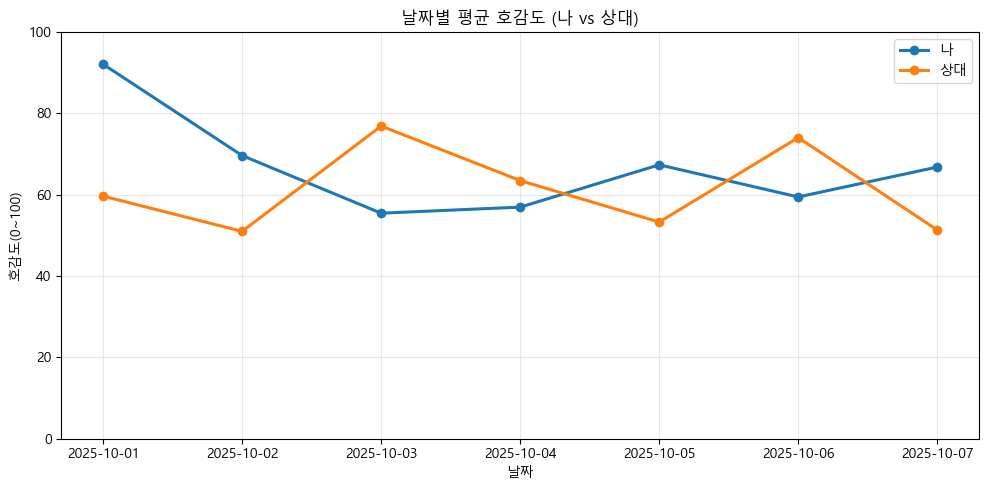


✨ 날짜별 최고 호감 순간 (상위 10개 미리보기)
      date  time speaker  affinity                             text
2025-10-01 10:00      상대     97.11      요즘 날씨가 좋아서 어딘가 가고 싶은 기분이에요.
2025-10-02 23:00       나     97.11      요즘 날씨가 좋아서 어딘가 가고 싶은 기분이에요.
2025-10-03 11:00      상대     97.11      요즘 날씨가 좋아서 어딘가 가고 싶은 기분이에요.
2025-10-04 00:00      상대     97.11      요즘 날씨가 좋아서 어딘가 가고 싶은 기분이에요.
2025-10-05 23:00      상대     82.37 사진으로 본 것보다 실제로 보면 훨씬 감동적일 것 같아요.
2025-10-06 23:00      상대     97.11      요즘 날씨가 좋아서 어딘가 가고 싶은 기분이에요.
2025-10-07 23:00      상대     83.87               시간 잘 맞으면 꼭 함께 가봐요!
[SAVE] best_moments.csv

📊 날짜별 평균 호감도 요약:
speaker        나    상대
date                  
2025-10-01  92.1  59.7
2025-10-02  69.6  51.0
2025-10-03  55.5  76.9
2025-10-04  57.0  63.5
2025-10-05  67.4  53.3
2025-10-06  59.5  74.1
2025-10-07  66.8  51.3


In [42]:
# -*- coding: utf-8 -*-
# =========================================================
# 대화파일 + 감성사전 기반 호감도 리포트 (time 컬럼 보장 수정본)
# - 입력: some.txt, SentiWord_Dict.txt
# - 출력: predictions.csv, daily_likeability.png, best_moments.csv
# =========================================================
import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------------------------
# 경로
# ---------------------------------------------------------
TXT_PATH = "./topic.txt"
LEX_PATH = "./SentiWord_Dict.txt"

assert os.path.exists(TXT_PATH), f"대화 파일 없음: {TXT_PATH}"
assert os.path.exists(LEX_PATH), f"사전 파일 없음: {LEX_PATH}"

# =========================================================
# 1) 대화 파서
#   예)
#     2025년 10월 01일
#     [오후 21:28:00] 상대: 네, 오늘은 그렇게 해요 ❤️
#     [점심 14:04:00] 나: 눈이 뻑뻑하죠? ...
# =========================================================
DATE_PAT = re.compile(r"^\s*(\d{4})년\s*(\d{2})월\s*(\d{2})일")
LINE_PAT = re.compile(r"(?:\[(.*?)\]\s*)?([^:：]+)\s*[:：]\s*(.*)")
# HH:MM 또는 HH:MM:SS 를 모두 허용
TIME_PAT = re.compile(r"(\d{1,2}):(\d{2})(?::\d{2})?")

def normalize_text(t:str)->str:
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def parse_hour(timestr:str)->int:
    if not timestr: return 0
    m = TIME_PAT.search(timestr)
    if not m: return 0
    hh = max(0, min(23, int(m.group(1))))
    return hh

def load_dialog(path=TXT_PATH)->pd.DataFrame:
    rows=[]; cur_date=None
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line=line.strip()
            if not line:
                continue
            dm = DATE_PAT.match(line)
            if dm:
                y,m,d = dm.groups()
                cur_date = f"{y}-{m}-{d}"
                # 날짜 헤더는 표/그래프에는 방해될 수 있어 ‘텍스트’로만 남기고 싶으면 주석처리 가능
                rows.append({
                    "turn": i, "date": cur_date, "hour": 0,
                    "timestamp": pd.to_datetime(f"{cur_date} 00:00:00"),
                    "time": "00:00",                     # ★ time 보장
                    "time_str": "",                      # 원문 시간(없음)
                    "speaker": "상대",                   # 임시
                    "text": normalize_text(line)
                })
                continue
            m = LINE_PAT.match(line)
            if not m or not cur_date:
                continue
            time_str = (m.group(1) or "").strip()  # ★ 원문 시간문구 저장(오전/오후/점심 14:04:00 등)
            speaker  = (m.group(2) or "").strip()
            text     = normalize_text((m.group(3) or ""))

            hour = parse_hour(time_str)
            ts = pd.to_datetime(f"{cur_date} {hour:02d}:00:00")
            time_fmt = pd.to_datetime(ts).strftime("%H:%M")

            rows.append({
                "turn": i,
                "date": cur_date,
                "hour": hour,
                "timestamp": ts,
                "time": time_fmt,         # ★ time 보장
                "time_str": time_str,     # 원문 시간 문자열
                "speaker": speaker,
                "text": text
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["timestamp","turn"]).reset_index(drop=True)
    print(f"[INFO] 대화 로드: {len(df):,}건")
    return df

# =========================================================
# 2) 감성사전 로딩 (term \t score[-2..2])
# =========================================================
def load_lexicon(path=LEX_PATH):
    lex = {}
    with open(path, encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln or ln.startswith("#"):
                continue
            parts = re.split(r"[\t,]", ln)
            if len(parts) < 2:
                continue
            term = parts[0].strip()
            try:
                score = float(parts[1])
            except:
                continue
            score = max(-2.0, min(2.0, score))
            if term:
                lex[term] = score
    print(f"[INFO] 사전 로드: {len(lex):,}개 용어")
    return lex

LEX = load_lexicon()

# =========================================================
# 3) 문장 점수→확률 + 호감도
# =========================================================
K_SIG = 0.9

HEART = r"[❤️💕💖💗💓💘🥰]"
LAUGH = r"(ㅎㅎ|ㅋㅋ|하하|헤헷|😄|😁|😊)"
INVIT = r"(같이|함께|보자|볼까|가자|갈까|통화|산책|커피|☕|약속|만나|잡자|잡을까)"
POSWD = r"(좋[아아요였네요니다]|힐링|괜찮|감사|고마워|설레|즐겁|행복|최고|대박|굿)"

_heart = re.compile(HEART)
_laugh = re.compile(LAUGH)
_invit = re.compile(INVIT)
_poswd = re.compile(POSWD)

def sentence_raw_score(text: str) -> float:
    s = 0.0
    for term, w in LEX.items():
        if term and term in text:
            s += w
    return s

def sigmoid(x: float) -> float:
    try:
        return 1.0 / (1.0 + math.exp(-x))
    except OverflowError:
        return 0.0 if x < 0 else 1.0

def probs_from_score(s: float, k: float = K_SIG):
    p = sigmoid(k * s)
    n = sigmoid(k * (-s))
    u = max(0.0, 1.0 - max(p, n))
    S = p + n + u
    return (p/S, u/S, n/S)

def affinity_from(text: str, pos: float, neg: float, emo_hint: str = "") -> float:
    base = 50.0 + 50.0*(pos - neg)
    t = text
    if _heart.search(t): base += 2.5
    if _laugh.search(t): base += 1.0
    if _invit.search(t): base += 1.5
    if "☕" in t or "커피" in t: base += 0.5
    if emo_hint == "긍정": base += 1.0
    elif emo_hint == "부정": base -= 1.0
    return float(np.clip(base, 0.0, 100.0))

def label_from_probs(pos, neu, neg):
    if pos >= max(neu, neg): return "긍정", pos
    if neg >= max(pos, neu): return "부정", neg
    return "중립", neu

# =========================================================
# 4) 예측 테이블
# =========================================================
def predict_table(df_in: pd.DataFrame, me="나", other="상대") -> pd.DataFrame:
    df = df_in.copy()
    df["text"] = df["text"].astype(str)

    # ★ time 컬럼 보장 (파서에 time이 없거나 NaT일 때 대비)
    if "time" not in df.columns:
        df["time"] = df["timestamp"].dt.strftime("%H:%M").fillna("")
    else:
        # 문자열/NaN 혼재 시 일괄 보정
        tmp_time = df["time"].astype(str)
        missing = tmp_time.eq("nan") | tmp_time.eq("") | tmp_time.eq("None")
        if missing.any():
            tmp_time.loc[missing] = df.loc[missing, "timestamp"].dt.strftime("%H:%M").fillna("")
        df["time"] = tmp_time

    # 문장별 점수→확률
    raw = df["text"].apply(sentence_raw_score)
    prob = raw.apply(lambda v: probs_from_score(v))
    df["pos_prob"] = prob.apply(lambda x: x[0])
    df["neu_prob"] = prob.apply(lambda x: x[1])
    df["neg_prob"] = prob.apply(lambda x: x[2])

    labs = [label_from_probs(p, u, n) for p, u, n in zip(df["pos_prob"], df["neu_prob"], df["neg_prob"])]
    df["valence_pred"] = [l for (l, _) in labs]
    df["valence_conf"] = [c for (_, c) in labs]

    df["affinity"] = [affinity_from(t, p, n, emo_hint=l)
                      for t, p, n, l in zip(df["text"], df["pos_prob"], df["neg_prob"], df["valence_pred"])]

    df["date"] = df["date"].astype(str)
    return df

# =========================================================
# 5) 시각화
# =========================================================
def plot_daily_likeability(df_pred: pd.DataFrame, me="나", other="상대",
                           save="daily_likeability.png"):
    g = (df_pred.groupby(["date","speaker"], as_index=False)["affinity"]
               .mean().rename(columns={"affinity":"aff_mean"}))
    plt.figure(figsize=(10,5))
    for who in [me, other]:
        sub = g[g["speaker"]==who].sort_values("date")
        if len(sub):
            plt.plot(pd.to_datetime(sub["date"]), sub["aff_mean"],
                     marker="o", linewidth=2.2, label=who)
    plt.ylim(0, 100)
    plt.title("날짜별 평균 호감도 (나 vs 상대)")
    plt.xlabel("날짜"); plt.ylabel("호감도(0~100)")
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[SAVE] {save}")
    plt.show()

# =========================================================
# 6) 날짜별 최고 호감 문장
# =========================================================
def extract_best_moments(df_pred: pd.DataFrame) -> pd.DataFrame:
    if df_pred.empty:
        return pd.DataFrame(columns=["date","time","speaker","affinity","text"])
    out = df_pred.copy()
    # ★ time이 확실히 존재하도록 보강
    if "time" not in out.columns:
        out["time"] = out["timestamp"].dt.strftime("%H:%M").fillna("")
    idx = out.groupby("date")["affinity"].idxmax()
    best = (out.loc[idx, ["date","time","speaker","affinity","text"]]
              .sort_values("date").reset_index(drop=True))
    best["affinity"] = best["affinity"].round(2)
    return best

# =========================================================
# 7) 실행
# =========================================================
def main():
    # 1) 대화 로드
    df = load_dialog(TXT_PATH)

    # 2) 예측/호감도
    df_pred = predict_table(df, me="나", other="상대")

    # 3) 저장 (time을 포함해 내보냄)
    cols = ["date","time","timestamp","speaker","text",
            "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf","affinity"]
    # 누락 방지용: 교집합만 선택
    cols = [c for c in cols if c in df_pred.columns]
    df_pred_out = df_pred[cols]
    df_pred_out.to_csv("predictions.csv", index=False, encoding="utf-8-sig")
    print("[SAVE] predictions.csv")

    # 4) 시각화 (나 vs 상대)
    plot_daily_likeability(df_pred, me="나", other="상대", save="daily_likeability.png")

    # 5) 날짜별 최고 호감 문장
    best = extract_best_moments(df_pred)
    best.to_csv("best_moments.csv", index=False, encoding="utf-8-sig")
    print("\n✨ 날짜별 최고 호감 순간 (상위 10개 미리보기)")
    print(best.head(10).to_string(index=False))
    print("[SAVE] best_moments.csv")

    # 요약 표
    daily = (df_pred.groupby(["date","speaker"], as_index=False)["affinity"].mean()
                      .rename(columns={"affinity":"aff_mean"}))
    print("\n📊 날짜별 평균 호감도 요약:")
    print(daily.pivot(index="date", columns="speaker", values="aff_mean").round(1).fillna("-"))

if __name__ == "__main__":
    main()


[INFO] 대화 로드: 42건
[INFO] 사전 로드: 14,851개


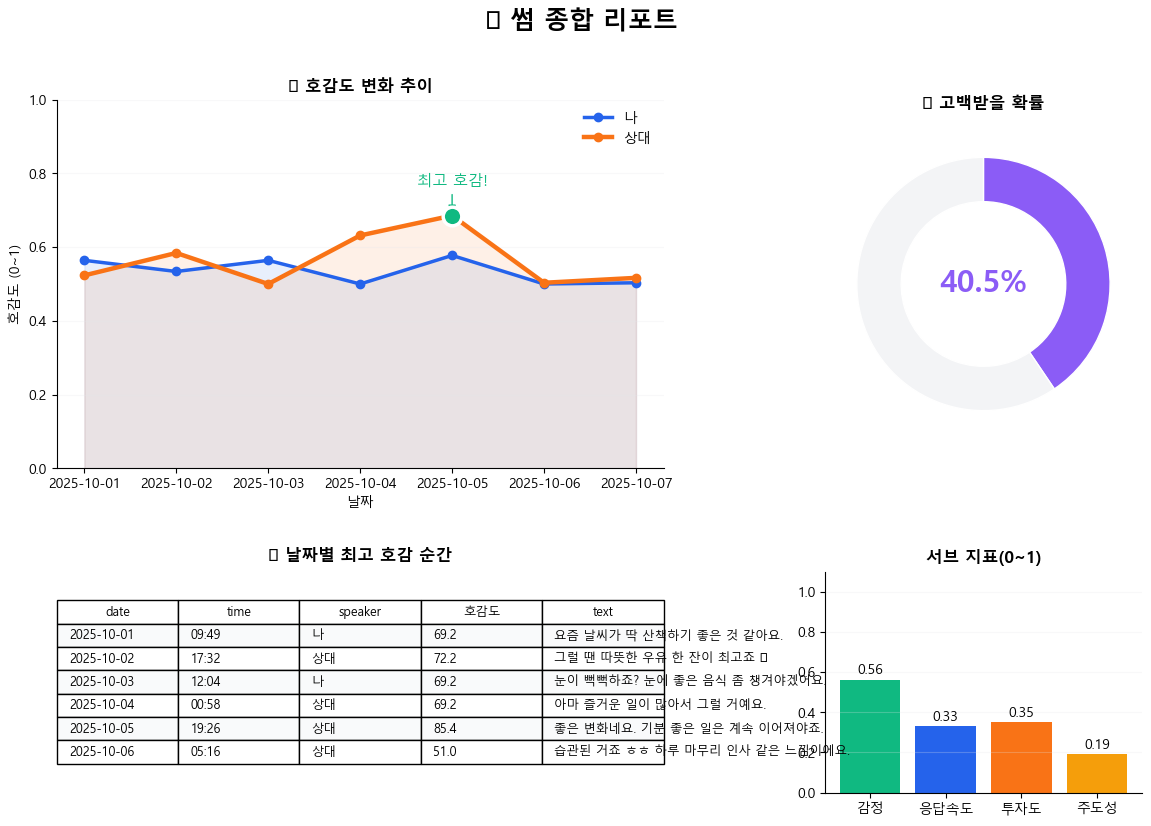

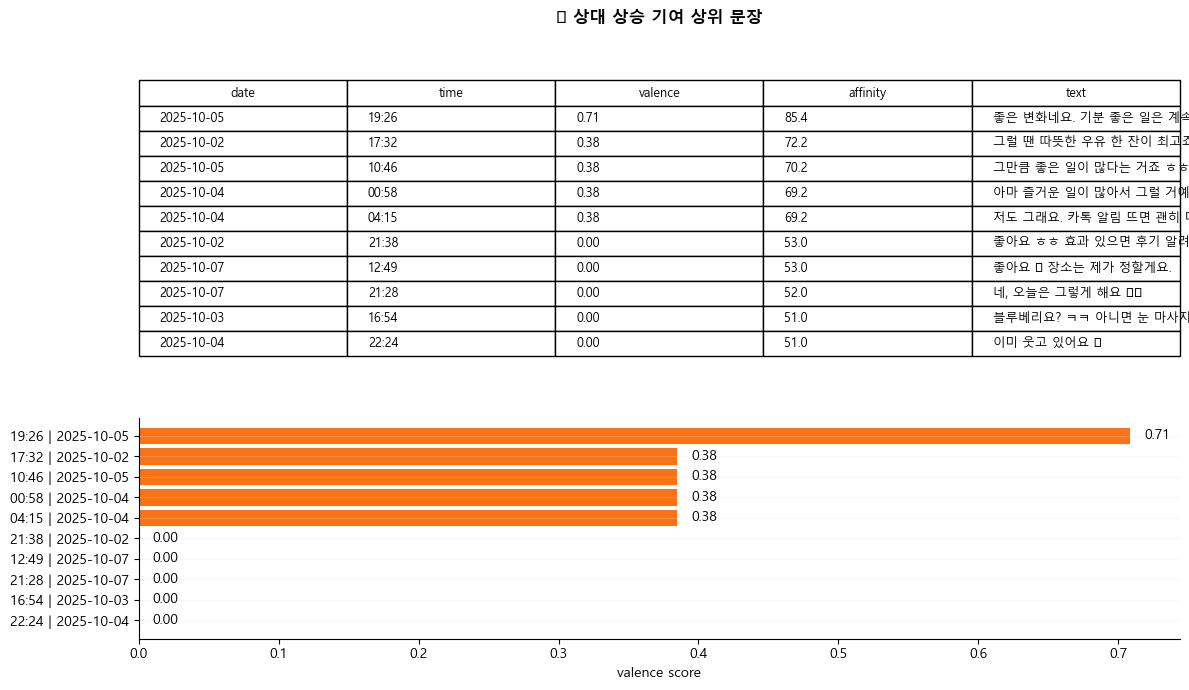

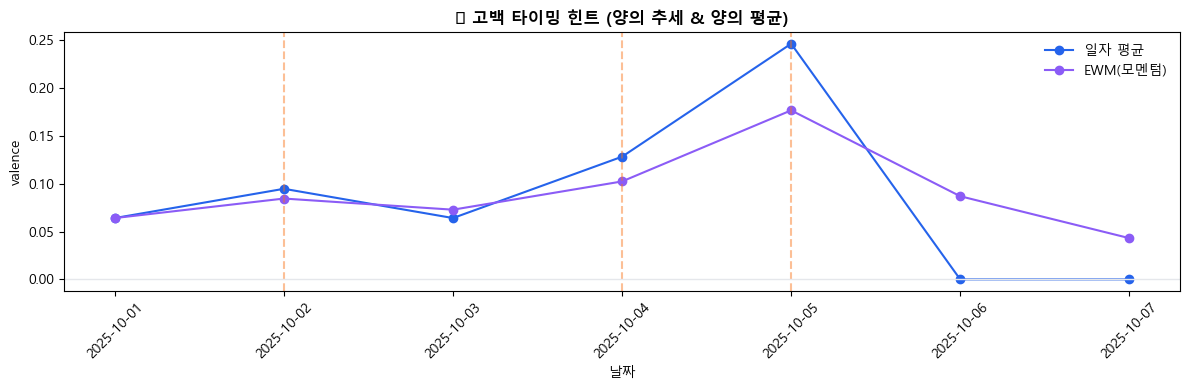

In [ ]:
# ============================
# 발표용 예쁜 시각화 3종
# ============================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 팔레트(리포트톤)
PALETTE = {
    "me":      "#2563eb",  # 파랑
    "other":   "#f97316",  # 오렌지
    "grid":    "#e5e7eb",
    "text":    "#111827",
    "accent":  "#10b981",  # 민트
    "accent2": "#8b5cf6",  # 보라
    "bad":     "#ef4444",  # 레드
}

def _fmt(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25, color=PALETTE["grid"])

def plot_dashboard_pretty(df_pred: pd.DataFrame, prob: float, details: dict,
                          me="나", other="상대", title="호감도 분석 리포트"):
    """
    예쁜 리포트 대시보드 (꺾은선+도넛게이지+서브지표+최고 호감 문장)
    - df_pred: predict_table 결과(affinity, date, time, speaker, text 포함)
    """
    # 1) 날짜별 평균 호감도(나/상대)
    daily = (df_pred.groupby(["date","speaker"])["affinity"]
             .mean().reset_index()
             .pivot(index="date", columns="speaker", values="affinity"))
    dates = daily.index.tolist()
    x = np.arange(len(dates))

    # 최고 호감일(상대 기준) 하이라이트
    best_other_idx = None
    if other in daily.columns and not daily[other].isna().all():
        best_other_idx = int(np.nanargmax(daily[other].values))

    fig = plt.figure(figsize=(14,9))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.3, 1.2], height_ratios=[2, 1.2],
                          hspace=0.35, wspace=0.35)

    # -------------------
    # (좌상) 꺾은선(나/상대)
    # -------------------
    ax1 = fig.add_subplot(gs[0,0])
    if me in daily.columns:
        y_me = (daily[me].values/100.0)
        ax1.plot(dates, y_me, marker="o", lw=2.5, color=PALETTE["me"], label=me)
        ax1.fill_between(dates, 0, y_me, color=PALETTE["me"], alpha=0.10)
    if other in daily.columns:
        y_ot = (daily[other].values/100.0)
        ax1.plot(dates, y_ot, marker="o", lw=3.2, color=PALETTE["other"], label=other, zorder=3)
        ax1.fill_between(dates, 0, y_ot, color=PALETTE["other"], alpha=0.10)
        # 최고 호감일 강조(점+라벨)
        if best_other_idx is not None and 0 <= best_other_idx < len(dates):
            ax1.scatter([dates[best_other_idx]], [y_ot[best_other_idx]],
                        s=180, edgecolor="white", linewidth=2.5,
                        color=PALETTE["accent"], zorder=5)
            ax1.annotate("최고 호감!",
                         (dates[best_other_idx], y_ot[best_other_idx]),
                         xytext=(0, 22), textcoords="offset points",
                         ha="center", color=PALETTE["accent"], fontsize=11,
                         arrowprops=dict(arrowstyle="-|>", color=PALETTE["accent"]))
    ax1.set_ylim(0, 1.0)
    ax1.set_title("📈 호감도 변화 추이", fontweight="bold")
    ax1.set_xlabel("날짜"); ax1.set_ylabel("호감도 (0~1)")
    _fmt(ax1); ax1.legend(frameon=False)

    # -------------------
    # (우상) 도넛 게이지 (고백확률)
    # -------------------
    ax2 = fig.add_subplot(gs[0,1])
    pct = max(0.0, min(1.0, float(prob)))
    vals = [pct, 1-pct]
    colors = [PALETTE["accent2"], "#F3F4F6"]
    wedges, _ = ax2.pie(vals, startangle=90, counterclock=False, colors=colors,
                        wedgeprops=dict(width=0.35, edgecolor="white"))
    ax2.text(0, 0, f"{pct*100:.1f}%", ha="center", va="center",
             fontsize=22, fontweight="bold", color=PALETTE["accent2"])
    ax2.set_title("💌 고백받을 확률", pad=12, fontweight="bold")

    # -------------------
    # (우하) 서브지표 바(감정/응답속도/투자도/주도성)
    # -------------------
    ax3 = fig.add_subplot(gs[1,1])
    labs = list(details.keys()); vals = list(details.values())
    bars = ax3.bar(labs, vals, color=[PALETTE["accent"], PALETTE["me"], PALETTE["other"], "#f59e0b"])
    for b,v in zip(bars, vals):
        ax3.text(b.get_x()+b.get_width()/2, v+0.03, f"{v:.2f}", ha="center", fontsize=10)
    ax3.set_ylim(0, 1.1)
    ax3.set_title("서브 지표(0~1)", fontweight="bold")
    _fmt(ax3)

    # -------------------
    # (좌하) 날짜별 최고 호감 문장 (표)
    # -------------------
    ax4 = fig.add_subplot(gs[1,0]); ax4.axis("off")
    best_tbl = (df_pred
                .loc[df_pred.groupby("date")["affinity"].idxmax(),
                     ["date","time","speaker","affinity","text"]]
                .sort_values("date").reset_index(drop=True))
    best_tbl["affinity"] = best_tbl["affinity"].round(1)
    # 상위 6행만 보이게(긴 표면 리포트 깨짐 방지)
    show = best_tbl.head(6)
    cell_text = [[r["date"], r["time"], r["speaker"], f'{r["affinity"]:.1f}', r["text"]] for _,r in show.iterrows()]
    col_labels = ["date","time","speaker","호감도","text"]
    table = ax4.table(cellText=cell_text, colLabels=col_labels, loc="center",
                      cellLoc="left", colLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(9)
    table.scale(1, 1.4)
    # zebra striping
    for i in range(1, len(cell_text)+1, 2):
        for j in range(len(col_labels)):
            table[(i, j)].set_facecolor("#f9fafb")
    ax4.set_title("✨ 날짜별 최고 호감 순간", pad=8, fontweight="bold")

    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.98)
    plt.show()


def most_impact_sentences_pretty(df_pred: pd.DataFrame, speaker="상대", topk=10):
    """
    '상승 기여 상위 문장' 예쁜 버전
    - 전일 대비 일자 평균 호감도 상승(delta) 상위 5일을 고르고
    - 그 날 해당 화자의 문장 중 (pos_prob - neg_prob) 또는 affinity 기준 상위 문장을 뽑아 표/막대 출력
    """
    use_val = (df_pred.get("pos_prob") is not None) and (df_pred.get("neg_prob") is not None)
    df = df_pred.copy()
    df["valence_score"] = (df["pos_prob"] - df["neg_prob"]) if use_val else (df["affinity"]/100.0)

    daily = (df.groupby(["date","speaker"])["affinity"]
             .mean().reset_index().rename(columns={"affinity":"aff"}))
    dsub = daily[daily["speaker"]==speaker].sort_values("date")
    if dsub.empty:
        print("[INFO] 해당 화자 데이터 없음"); return
    dsub["delta"] = dsub["aff"].diff()

    top_days = (dsub.dropna(subset=["delta"])
                    .sort_values("delta", ascending=False).head(5)["date"].tolist())
    cand = df[(df["speaker"]==speaker) & (df["date"].isin(top_days))]
    top_sent = cand.sort_values(["valence_score","affinity"], ascending=False).head(topk)

    # 표 + 막대
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), gridspec_kw={"height_ratios":[2,1.2]})
    ax1.axis("off")
    col_labels = ["date","time","valence","affinity","text"]
    cell_text = [[r["date"], r["time"], f'{r["valence_score"]:.2f}', f'{r["affinity"]:.1f}', r["text"]]
                 for _,r in top_sent.iterrows()]
    table = ax1.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="left", colLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.25)
    ax1.set_title(f"📈 {speaker} 상승 기여 상위 문장", fontweight="bold", pad=8)

    ax2.barh(top_sent["time"]+" | "+top_sent["date"], top_sent["valence_score"], color=PALETTE["other"])
    for i, v in enumerate(top_sent["valence_score"]):
        ax2.text(v+0.01, i, f"{v:.2f}", va="center")
    ax2.set_xlabel("valence score"); ax2.invert_yaxis(); _fmt(ax2)
    plt.tight_layout(); plt.show()


def plot_timing_hint(df_pred: pd.DataFrame, title="💘 고백 타이밍 힌트 (양의 추세 & 양의 평균)"):
    """
    일자 평균 valence_score 와 EWM(모멘텀) 그래프 + 후보일 표시
    """
    use_val = (df_pred.get("pos_prob") is not None) and (df_pred.get("neg_prob") is not None)
    df = df_pred.copy()
    df["valence_score"] = (df["pos_prob"] - df["neg_prob"]) if use_val else (df["affinity"]/100.0)

    daily = (df.groupby("date")["valence_score"]
             .mean().reset_index().sort_values("date"))
    daily["ewm"] = daily["valence_score"].ewm(alpha=0.5).mean()
    cands = daily[(daily["valence_score"]>0) & (daily["ewm"].diff()>0)]

    plt.figure(figsize=(12,4))
    plt.plot(daily["date"], daily["valence_score"], marker="o", color=PALETTE["me"], label="일자 평균")
    plt.plot(daily["date"], daily["ewm"], marker="o", color=PALETTE["accent2"], label="EWM(모멘텀)")
    for _, r in cands.iterrows():
        plt.axvline(r["date"], color=PALETTE["other"], ls="--", alpha=0.45)
    plt.axhline(0, color=PALETTE["grid"], lw=1)
    plt.title(title, fontweight="bold"); plt.xlabel("날짜"); plt.ylabel("valence")
    plt.xticks(rotation=45); plt.legend(frameon=False); plt.tight_layout(); plt.show()


df = load_dialog(TXT_PATH)
lex = load_lexicon(LEX_PATH)
df_pred = predict_table(df, lex, me="나", other="상대")

prob, details = confession_probability(df_pred, other="상대")

# 1) 예쁜 종합 리포트
plot_dashboard_pretty(df_pred, prob, details, me="나", other="상대")

# 2) 상승 기여 TOP 문장 시각화
most_impact_sentences_pretty(df_pred, speaker="상대", topk=10)

# 3) 고백 타이밍 힌트
plot_timing_hint(df_pred)
